<a href="https://colab.research.google.com/github/Priyadarshini-yadav13/Rashmi/blob/main/EDA_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
#  EXPLORATORY DATA ANALYSIS — THE COMPLETE BEGINNER'S GUIDE
#  Built for: Students with zero data science exposure
#  Dataset: Retail store transactions (relatable, real-world)
#  Philosophy: WHY before HOW. Every chart earns its place.
# ============================================================


In [ ]:

print("""
╔══════════════════════════════════════════════════════════════════════╗
║               THE 5 QUESTIONS EDA ANSWERS                            ║
║                                                                      ║
║  Every chart you make should answer ONE of these questions:          ║
║                                                                      ║
║  1. WHAT IS IN MY DATA?                                              ║
║     → Shape, dtypes, missing values, sample rows                     ║
║     → Tools: .shape, .info(), .describe(), .isnull()                 ║
║                                                                      ║
║  2. HOW IS EACH VARIABLE DISTRIBUTED?                                ║
║     → Range, skew, outliers, normal vs not                           ║
║     → Tools: histplot, kdeplot, boxplot                              ║
║                                                                      ║
║  3. HOW DO TWO VARIABLES RELATE?                                     ║
║     → Correlation, trends, clusters                                  ║
║     → Tools: scatterplot, lineplot, heatmap, regplot                 ║
║                                                                      ║
║  4. HOW DO GROUPS COMPARE?                                           ║
║     → Are some categories better/worse/different?                    ║
║     → Tools: barplot, boxplot, violinplot, stripplot                 ║
║                                                                      ║
║  5. ARE THERE PATTERNS ACROSS MANY VARIABLES AT ONCE?                ║
║     → Which features matter most together?                           ║
║     → Tools: pairplot, heatmap (correlation matrix)                  ║
║                                                                      ║
║  RULE OF THUMB: Start at Question 1. Never skip to Question 5.       ║
║  You cannot understand relationships before understanding each       ║
║  variable on its own.                                                ║
╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║               THE 5 QUESTIONS EDA ANSWERS                            ║
║                                                                      ║
║  Every chart you make should answer ONE of these questions:          ║
║                                                                      ║
║  1. WHAT IS IN MY DATA?                                              ║
║     → Shape, dtypes, missing values, sample rows                     ║
║     → Tools: .shape, .info(), .describe(), .isnull()                 ║
║                                                                      ║
║  2. HOW IS EACH VARIABLE DISTRIBUTED?                                ║
║     → Range, skew, outliers, normal vs not                           ║
║     → Tools: histplot, kdeplot, boxplot                              ║
║                                                                      ║
║  3. HOW DO TWO VARIABLES RELATE?                

In [ ]:

# ════════════════════════════════════════════════════════════
#  CELL 0 — THE EDA DECISION FRAMEWORK
#  Read this before writing a single line of code.
# ════════════════════════════════════════════════════════════


# ════════════════════════════════════════════════════════════
#  CELL 1 — SETUP
# ════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Seaborn visual settings — always set these first
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print("✅ Libraries loaded")
print(f"   Seaborn version : {sns.__version__}")
print(f"   Pandas version  : {pd.__version__}")

✅ Libraries loaded
   Seaborn version : 0.13.2
   Pandas version  : 2.2.2


In [ ]:

# ════════════════════════════════════════════════════════════
#  CELL 2 — CREATE THE DATASET
#  We use synthetic retail data so every student has the
#  same data and we can explain every single column.
# ════════════════════════════════════════════════════════════

"""
DATASET: RetailMart — 1,000 customer transactions
Columns:
  customer_id    : Unique ID per customer
  age            : Customer age (years)
  gender         : Male / Female / Other
  city           : Delhi / Mumbai / Bangalore / Chennai / Kolkata
  product_category: Electronics / Clothing / Food / Books / Home
  spend          : Amount spent in ₹ (this transaction)
  discount_pct   : Discount given (0–40%)
  satisfaction   : Rating 1–5 (post-purchase survey)
  is_repeat      : 1 if customer has shopped before, 0 if first-time
  day_of_week    : Mon–Sun
  month          : 1–12
"""

np.random.seed(42)
n = 1000

cities      = ['Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Kolkata']
categories  = ['Electronics', 'Clothing', 'Food', 'Books', 'Home']
days        = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
genders     = ['Male', 'Female', 'Other']

city_col     = np.random.choice(cities, n, p=[0.28, 0.27, 0.22, 0.13, 0.10])
cat_col      = np.random.choice(categories, n, p=[0.30, 0.25, 0.20, 0.15, 0.10])
gender_col   = np.random.choice(genders, n, p=[0.50, 0.46, 0.04])
age_col      = np.random.normal(35, 10, n).clip(18, 70).astype(int)
repeat_col   = np.random.binomial(1, 0.62, n)
discount_col = np.random.choice([0, 5, 10, 15, 20, 30, 40], n,
                                p=[0.30, 0.20, 0.20, 0.12, 0.10, 0.05, 0.03])

# Spend depends on category and repeat customer status
base_spend = {
    'Electronics': 18000, 'Clothing': 3500, 'Food': 800,
    'Books': 1200, 'Home': 6000
}
spend_col = np.array([
    max(200,
        base_spend[cat_col[i]]
        * np.random.lognormal(0, 0.5)
        * (1 + 0.15 * repeat_col[i])
        * (1 - discount_col[i] / 100 * 0.5))
    for i in range(n)
]).round(0)

# Satisfaction: higher for repeat customers, lower for very high spend
satisfaction_col = np.clip(
    np.round(3.2 + 0.5 * repeat_col + np.random.normal(0, 0.8, n)
             - 0.00005 * spend_col), 1, 5
).astype(int)

# Inject 4% missing values in satisfaction (survey not always filled)
missing_mask = np.random.choice([True, False], n, p=[0.04, 0.96])
satisfaction_float = satisfaction_col.astype(float)
satisfaction_float[missing_mask] = np.nan

df = pd.DataFrame({
    'customer_id':        range(1001, 1001 + n),
    'age':                age_col,
    'gender':             gender_col,
    'city':               city_col,
    'product_category':   cat_col,
    'spend':              spend_col,
    'discount_pct':       discount_col,
    'satisfaction':       satisfaction_float,
    'is_repeat':          repeat_col,
    'day_of_week':        np.random.choice(days, n),
    'month':              np.random.randint(1, 13, n),
})

print(f"✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head(10).to_string())


# ════════════════════════════════════════════════════════════
#  ██████╗ ██╗   ██╗███████╗███████╗████████╗██╗ ██████╗ ███╗   ██╗
#  ██╔═══██╗██║   ██║██╔════╝██╔════╝╚══██╔══╝██║██╔═══██╗████╗  ██║
#  ██║   ██║██║   ██║█████╗  ███████╗   ██║   ██║██║   ██║██╔██╗ ██║
#  ██║▄▄ ██║██║   ██║██╔══╝  ╚════██║   ██║   ██║██║   ██║██║╚██╗██║
#  ╚██████╔╝╚██████╔╝███████╗███████║   ██║   ██║╚██████╔╝██║ ╚████║
#   ╚══▀▀═╝  ╚═════╝ ╚══════╝╚══════╝   ╚═╝   ╚═╝ ╚═════╝ ╚═╝  ╚═══╝
#
#  QUESTION 1: WHAT IS IN MY DATA?
# ════════════════════════════════════════════════════════════


✅ Dataset created: 1000 rows × 11 columns
   customer_id  age  gender       city product_category    spend  discount_pct  satisfaction  is_repeat day_of_week  month
0         1001   45    Male     Mumbai      Electronics  23948.0            15           1.0          1         Sat      6
1         1002   41    Male    Kolkata         Clothing   2819.0            20           3.0          1         Thu      9
2         1003   41  Female  Bangalore            Books   1075.0             5           4.0          1         Sat     12
3         1004   21    Male  Bangalore             Food    879.0             5           3.0          0         Thu      3
4         1005   47    Male      Delhi            Books    706.0             5           5.0          1         Mon     11
5         1006   37  Female      Delhi             Food    728.0            30           4.0          1         Thu      3
6         1007   31    Male      Delhi             Food   1512.0            10           3.0     

In [ ]:

# ── CELL 3 — Shape & Column Types ────────────────────────────
print("=" * 60)
print("STEP 1A: HOW BIG IS MY DATASET?")
print("=" * 60)
print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nTotal cells : {df.shape[0] * df.shape[1]:,}")

print("\n" + "=" * 60)
print("STEP 1B: WHAT TYPE IS EACH COLUMN?")
print("=" * 60)
print("""
WHY THIS MATTERS:
  The data type of a column determines WHICH charts you can use.

  Numerical columns  → histograms, scatter plots, box plots
  Categorical columns → bar charts, count plots, grouped box plots

  Two types of numerical:
    • Continuous  : can be any value (spend, age) → use histogram
    • Discrete    : whole numbers only (satisfaction 1-5) → use bar
""")
print(df.dtypes)
print("\nNumerical columns :", df.select_dtypes('number').columns.tolist())
print("Categorical columns:", df.select_dtypes('object').columns.tolist())



STEP 1A: HOW BIG IS MY DATASET?

Rows    : 1,000
Columns : 11

Total cells : 11,000

STEP 1B: WHAT TYPE IS EACH COLUMN?

WHY THIS MATTERS:
  The data type of a column determines WHICH charts you can use.

  Numerical columns  → histograms, scatter plots, box plots
  Categorical columns → bar charts, count plots, grouped box plots

  Two types of numerical:
    • Continuous  : can be any value (spend, age) → use histogram
    • Discrete    : whole numbers only (satisfaction 1-5) → use bar

customer_id           int64
age                   int64
gender               object
city                 object
product_category     object
spend               float64
discount_pct          int64
satisfaction        float64
is_repeat             int64
day_of_week          object
month                 int64
dtype: object

Numerical columns : ['customer_id', 'age', 'spend', 'discount_pct', 'satisfaction', 'is_repeat', 'month']
Categorical columns: ['gender', 'city', 'product_category', 'day_of_week']


In [ ]:

# ── CELL 4 — Missing Values ───────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1C: WHERE IS DATA MISSING?")
print("=" * 60)
print("""
WHY THIS MATTERS:
  Missing data can silently ruin analysis.
  A column with 30% missing values cannot tell you the full story.
  Always check before trusting any chart.

RULE OF THUMB:
  < 5% missing  → safe to drop those rows or fill with mean/median
  5–20% missing → investigate WHY it's missing before deciding
  > 20% missing → seriously consider dropping the column entirely
""")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing,
                            'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df if len(missing_df) > 0 else "✅ No missing values")
print(f"\n→ 'satisfaction' has {missing_pct['satisfaction']:.1f}% missing")
print("→ Strategy: fill with median (4% is low enough to be safe)")

# Fill missing satisfaction with median for downstream analysis
df['satisfaction'] = df['satisfaction'].fillna(df['satisfaction'].median())
print(f"→ Filled. Median satisfaction used: {df['satisfaction'].median()}")



STEP 1C: WHERE IS DATA MISSING?

WHY THIS MATTERS:
  Missing data can silently ruin analysis.
  A column with 30% missing values cannot tell you the full story.
  Always check before trusting any chart.

RULE OF THUMB:
  < 5% missing  → safe to drop those rows or fill with mean/median
  5–20% missing → investigate WHY it's missing before deciding
  > 20% missing → seriously consider dropping the column entirely

              Missing Count  Missing %
satisfaction             41        4.1

→ 'satisfaction' has 4.1% missing
→ Strategy: fill with median (4% is low enough to be safe)
→ Filled. Median satisfaction used: 3.0


In [ ]:


# ── CELL 5 — Summary Statistics ──────────────────────────────
print("\n" + "=" * 60)
print("STEP 1D: WHAT ARE THE BASIC STATISTICS?")
print("=" * 60)
print("""
HOW TO READ .describe():
  count  → how many non-missing values
  mean   → average (sensitive to outliers)
  std    → standard deviation (spread around mean)
  min    → smallest value
  25%    → 25th percentile (25% of values are below this)
  50%    → median (middle value — more robust than mean)
  75%    → 75th percentile
  max    → largest value

RULE OF THUMB for spotting outliers:
  If (max - 75%) >> (75% - 25%), you likely have high outliers
  If (25% - min) >> (75% - 25%), you likely have low outliers
""")
print(df.describe().round(1).to_string())

print("""
→ WHAT DO YOU NOTICE?
  Look at 'spend': mean >> median? That means HIGH outliers are
  pulling the average up. A few big spenders skew the mean.
  For spend, the MEDIAN is more representative than the mean.
""")


# ════════════════════════════════════════════════════════════
#  QUESTION 2: HOW IS EACH VARIABLE DISTRIBUTED?
#  Rule: Always look at ONE variable at a time first.
#        Never jump to two-variable charts before this step.
# ════════════════════════════════════════════════════════════



STEP 1D: WHAT ARE THE BASIC STATISTICS?

HOW TO READ .describe():
  count  → how many non-missing values
  mean   → average (sensitive to outliers)
  std    → standard deviation (spread around mean)
  min    → smallest value
  25%    → 25th percentile (25% of values are below this)
  50%    → median (middle value — more robust than mean)
  75%    → 75th percentile
  max    → largest value

RULE OF THUMB for spotting outliers:
  If (max - 75%) >> (75% - 25%), you likely have high outliers
  If (25% - min) >> (75% - 25%), you likely have low outliers

       customer_id     age    spend  discount_pct  satisfaction  is_repeat   month
count       1000.0  1000.0   1000.0        1000.0        1000.0     1000.0  1000.0
mean        1500.5    34.7   8355.8           9.5           3.1        0.6     6.5
std          288.8     9.6  11563.0          10.0           1.0        0.5     3.4
min         1001.0    18.0    204.0           0.0           1.0        0.0     1.0
25%         1250.8    27.0  

QUESTION 2: DISTRIBUTION OF SINGLE VARIABLES

THE DECISION TREE FOR SINGLE-VARIABLE CHARTS:

  Is the column NUMERICAL?
  ├── YES → Is it continuous (many unique values)?
  │         ├── YES → Use HISTOGRAM (histplot)
  │         │         • Shows the shape of the distribution
  │         │         • Add kde=True to overlay smooth curve
  │         └── NO (few unique values like 1-5 ratings)
  │               → Use BAR CHART (countplot)
  └── NO (categorical) → Use BAR CHART (countplot)
                         • Shows how many fall in each group



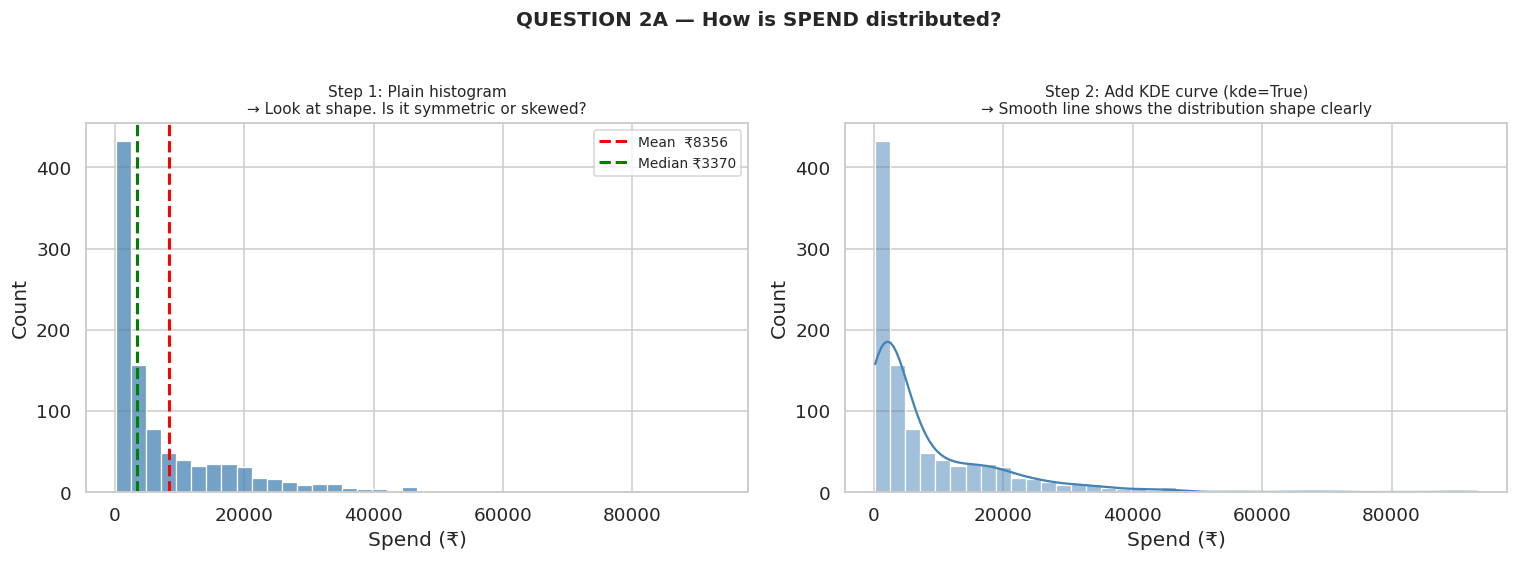


🔍 WHAT TO READ FROM THIS CHART:
  • The distribution is RIGHT-SKEWED (long tail to the right)
  • Mean (red) > Median (green) → pulled right by big spenders
  • Most customers spend ₹500–₹5,000 but a few spend ₹50,000+
  • These extreme spenders are called OUTLIERS

📌 RULE OF THUMB:
  Right-skewed → Mean overstates the "typical" customer
  Use MEDIAN to describe "typical" for skewed distributions
  Use MEAN only for symmetric (bell-shaped) distributions



In [ ]:

# ── CELL 6 — Histogram: Continuous Variable ───────────────────
print("=" * 60)
print("QUESTION 2: DISTRIBUTION OF SINGLE VARIABLES")
print("=" * 60)
print("""
THE DECISION TREE FOR SINGLE-VARIABLE CHARTS:

  Is the column NUMERICAL?
  ├── YES → Is it continuous (many unique values)?
  │         ├── YES → Use HISTOGRAM (histplot)
  │         │         • Shows the shape of the distribution
  │         │         • Add kde=True to overlay smooth curve
  │         └── NO (few unique values like 1-5 ratings)
  │               → Use BAR CHART (countplot)
  └── NO (categorical) → Use BAR CHART (countplot)
                         • Shows how many fall in each group
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("QUESTION 2A — How is SPEND distributed?",
             fontsize=13, fontweight='bold', y=1.02)

# Left: Basic histogram
sns.histplot(data=df, x='spend', bins=40, color='steelblue',
             ax=axes[0])
axes[0].set_title("Step 1: Plain histogram\n"
                   "→ Look at shape. Is it symmetric or skewed?",
                   fontsize=10)
axes[0].set_xlabel("Spend (₹)")
axes[0].axvline(df['spend'].mean(),   color='red',    lw=2,
                linestyle='--', label=f"Mean  ₹{df['spend'].mean():.0f}")
axes[0].axvline(df['spend'].median(), color='green',  lw=2,
                linestyle='--', label=f"Median ₹{df['spend'].median():.0f}")
axes[0].legend(fontsize=9)

# Right: Add KDE overlay
sns.histplot(data=df, x='spend', bins=40, kde=True,
             color='steelblue', ax=axes[1])
axes[1].set_title("Step 2: Add KDE curve (kde=True)\n"
                   "→ Smooth line shows the distribution shape clearly",
                   fontsize=10)
axes[1].set_xlabel("Spend (₹)")

plt.tight_layout()
plt.savefig('/tmp/hist_spend.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
🔍 WHAT TO READ FROM THIS CHART:
  • The distribution is RIGHT-SKEWED (long tail to the right)
  • Mean (red) > Median (green) → pulled right by big spenders
  • Most customers spend ₹500–₹5,000 but a few spend ₹50,000+
  • These extreme spenders are called OUTLIERS

📌 RULE OF THUMB:
  Right-skewed → Mean overstates the "typical" customer
  Use MEDIAN to describe "typical" for skewed distributions
  Use MEAN only for symmetric (bell-shaped) distributions
""")



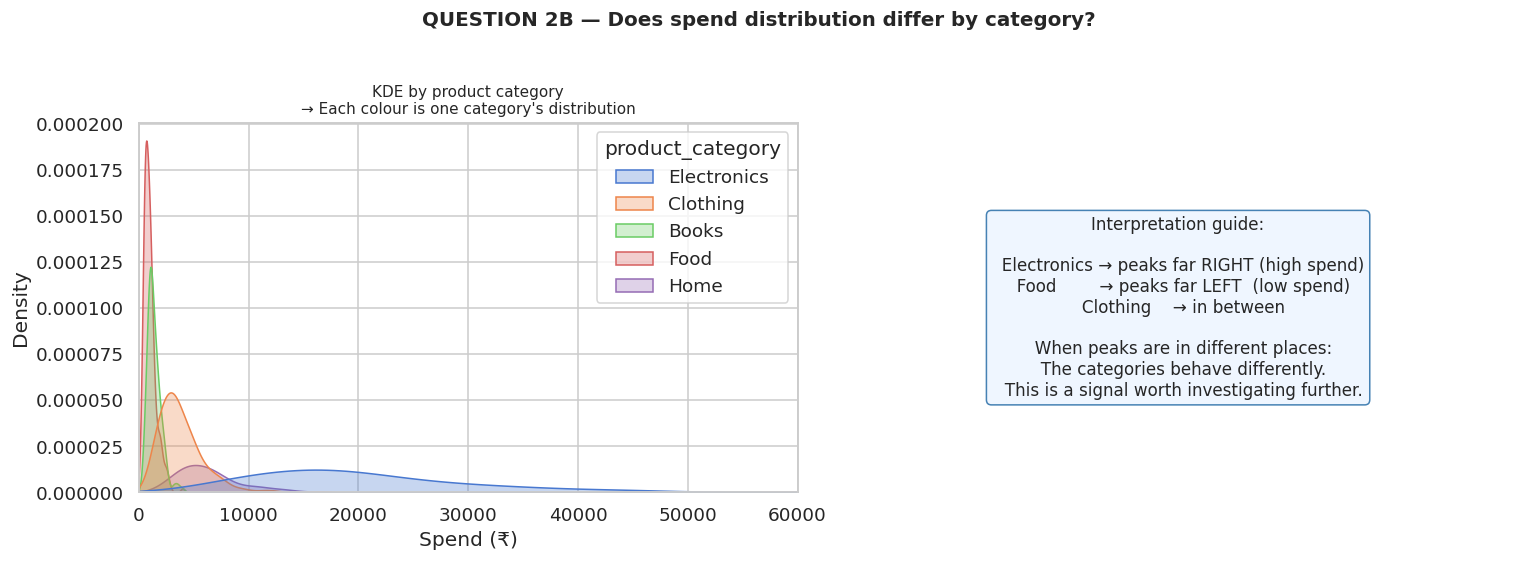


📌 WHEN TO ADD 'hue' TO A DISTRIBUTION CHART:
  When you suspect different groups behave differently.
  Question to ask: "Would I expect this distribution to
  look the same for all categories?" If NO → add hue.



In [ ]:

# ── CELL 7 — Histogram by Group (hue) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("QUESTION 2B — Does spend distribution differ by category?",
             fontsize=13, fontweight='bold', y=1.02)

# Left: Overlapping KDE by category
sns.kdeplot(data=df, x='spend', hue='product_category',
            fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("KDE by product category\n"
                   "→ Each colour is one category's distribution",
                   fontsize=10)
axes[0].set_xlabel("Spend (₹)")
axes[0].set_xlim(0, 60000)

# Right: Separate histograms per category using col
plt.sca(axes[1])
axes[1].axis('off')
axes[1].text(0.5, 0.5,
    "Interpretation guide:\n\n"
    "  Electronics → peaks far RIGHT (high spend)\n"
    "  Food        → peaks far LEFT  (low spend)\n"
    "  Clothing    → in between\n\n"
    "  When peaks are in different places:\n"
    "  The categories behave differently.\n"
    "  This is a signal worth investigating further.",
    transform=axes[1].transAxes,
    ha='center', va='center', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='#EFF6FF', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('/tmp/kde_category.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
📌 WHEN TO ADD 'hue' TO A DISTRIBUTION CHART:
  When you suspect different groups behave differently.
  Question to ask: "Would I expect this distribution to
  look the same for all categories?" If NO → add hue.
""")



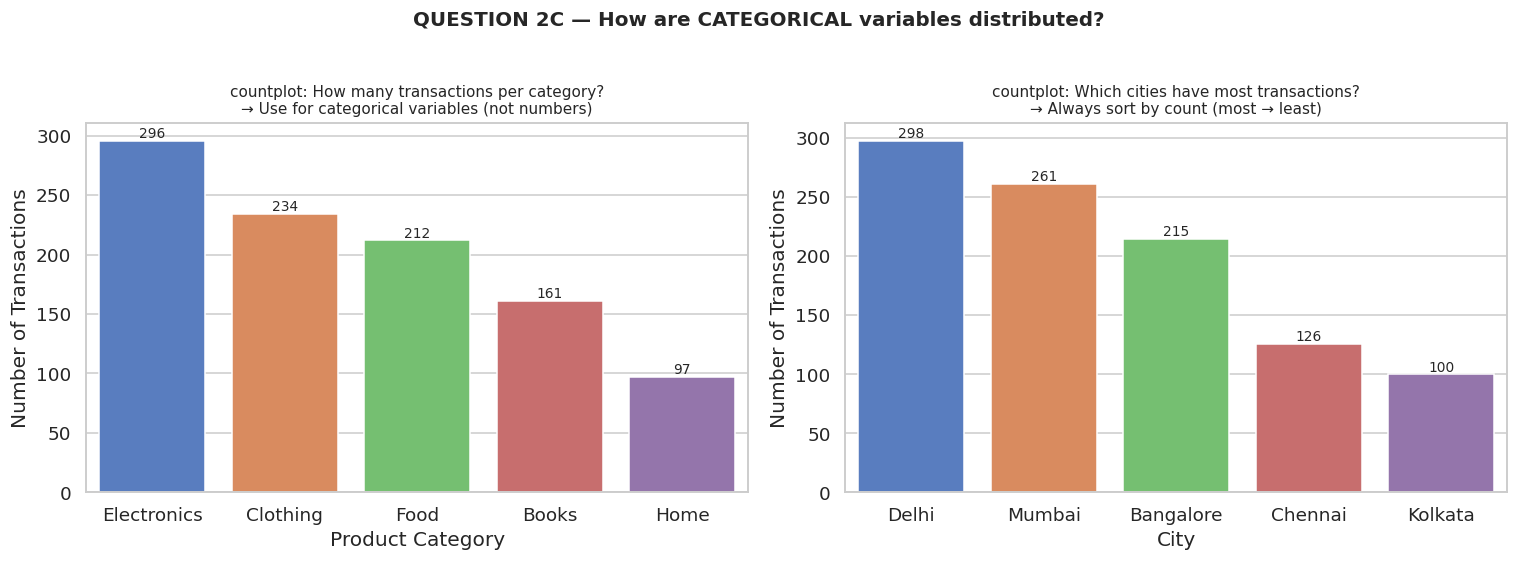


📌 COUNTPLOT RULES OF THUMB:
  1. Always sort bars from tallest to shortest
     → Makes imbalance immediately visible
  2. If one category has 10× more rows than another
     → You have a class imbalance problem
     → Your model will be biased toward the majority class
  3. Add the count on top of each bar for quick reading



In [ ]:

# ── CELL 8 — Categorical Variable Distribution ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("QUESTION 2C — How are CATEGORICAL variables distributed?",
             fontsize=13, fontweight='bold', y=1.02)

# Count plot — for categorical columns
sns.countplot(data=df, x='product_category', order=df['product_category']
              .value_counts().index, palette='muted', ax=axes[0])
axes[0].set_title("countplot: How many transactions per category?\n"
                   "→ Use for categorical variables (not numbers)",
                   fontsize=10)
axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("Number of Transactions")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# City distribution
sns.countplot(data=df, x='city', order=df['city'].value_counts().index,
              palette='muted', ax=axes[1])
axes[1].set_title("countplot: Which cities have most transactions?\n"
                   "→ Always sort by count (most → least)",
                   fontsize=10)
axes[1].set_xlabel("City")
axes[1].set_ylabel("Number of Transactions")
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/countplot.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
📌 COUNTPLOT RULES OF THUMB:
  1. Always sort bars from tallest to shortest
     → Makes imbalance immediately visible
  2. If one category has 10× more rows than another
     → You have a class imbalance problem
     → Your model will be biased toward the majority class
  3. Add the count on top of each bar for quick reading
""")



THE BOXPLOT — Reading it for the first time

HOW TO READ A BOXPLOT:

    ┌──────────────────────────────────────┐
    │  Whisker ──┤  Box  ├── Whisker       │
    │  (min*)    Q1  M  Q3   (max*)   •    │
    └──────────────────────────────────────┘
                            ↑
                        Outlier dot

  Q1  = 25th percentile (bottom of box)
  M   = Median (line in middle of box)
  Q3  = 75th percentile (top of box)
  Box = IQR = Q3 - Q1  (middle 50% of data lives here)
  Whiskers extend to 1.5 × IQR beyond Q1 and Q3
  Dots beyond whiskers = OUTLIERS

RULE OF THUMB:
  Wide box  → high spread (data is inconsistent)
  Narrow box → low spread (data is consistent)
  Median not in centre of box → skewed distribution
  Many dots → many outliers (need investigation)



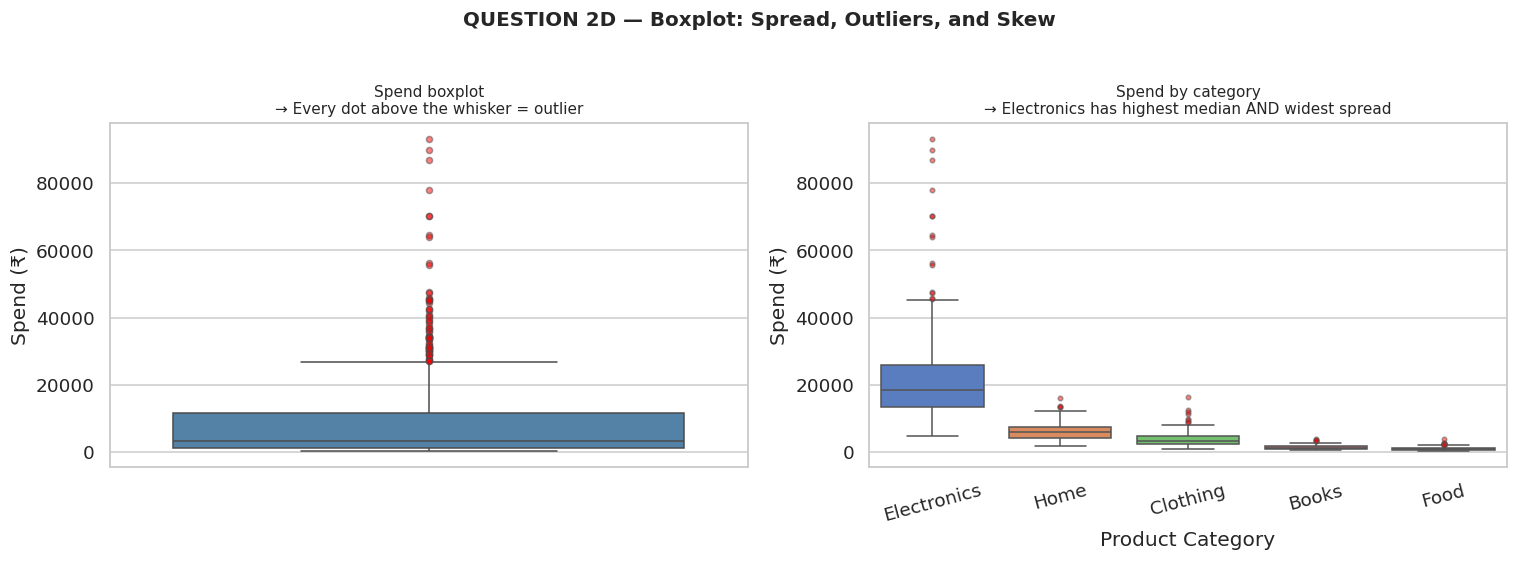

In [ ]:

# ── CELL 9 — Boxplot: Outliers & Spread ──────────────────────
print("=" * 60)
print("THE BOXPLOT — Reading it for the first time")
print("=" * 60)
print("""
HOW TO READ A BOXPLOT:

    ┌──────────────────────────────────────┐
    │  Whisker ──┤  Box  ├── Whisker       │
    │  (min*)    Q1  M  Q3   (max*)   •    │
    └──────────────────────────────────────┘
                            ↑
                        Outlier dot

  Q1  = 25th percentile (bottom of box)
  M   = Median (line in middle of box)
  Q3  = 75th percentile (top of box)
  Box = IQR = Q3 - Q1  (middle 50% of data lives here)
  Whiskers extend to 1.5 × IQR beyond Q1 and Q3
  Dots beyond whiskers = OUTLIERS

RULE OF THUMB:
  Wide box  → high spread (data is inconsistent)
  Narrow box → low spread (data is consistent)
  Median not in centre of box → skewed distribution
  Many dots → many outliers (need investigation)
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("QUESTION 2D — Boxplot: Spread, Outliers, and Skew",
             fontsize=13, fontweight='bold', y=1.02)

# Left: Spend boxplot
sns.boxplot(data=df, y='spend', color='steelblue', ax=axes[0],
            flierprops=dict(marker='o', markerfacecolor='red',
                            markersize=4, alpha=0.5))
axes[0].set_title("Spend boxplot\n→ Every dot above the whisker = outlier",
                   fontsize=10)
axes[0].set_ylabel("Spend (₹)")

# Right: Spend by category
sns.boxplot(data=df, x='product_category', y='spend',
            palette='muted', ax=axes[1],
            order=['Electronics', 'Home', 'Clothing', 'Books', 'Food'],
            flierprops=dict(marker='o', markerfacecolor='red',
                            markersize=3, alpha=0.5))
axes[1].set_title("Spend by category\n"
                   "→ Electronics has highest median AND widest spread",
                   fontsize=10)
axes[1].set_xlabel("Product Category")
axes[1].set_ylabel("Spend (₹)")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/tmp/boxplot.png', dpi=110, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
#  QUESTION 3: HOW DO TWO VARIABLES RELATE?
#  The question of RELATIONSHIPS
# ════════════════════════════════════════════════════════════


In [ ]:

# ── CELL 10 — The Relationship Decision Tree ─────────────────
print("=" * 60)
print("QUESTION 3: RELATIONSHIPS BETWEEN TWO VARIABLES")
print("=" * 60)
print("""
THE DECISION TREE FOR TWO-VARIABLE CHARTS:

  What are the two variable types?
  │
  ├── NUMERICAL × NUMERICAL
  │     → Scatter plot (scatterplot)
  │     → Add regression line (regplot / lmplot)
  │     Question: "As X goes up, does Y go up or down?"
  │
  ├── NUMERICAL × CATEGORICAL
  │     → Box plot (boxplot) — shows spread per group
  │     → Bar plot (barplot) — shows average per group
  │     → Violin plot (violinplot) — shows full shape per group
  │     Question: "Does the number differ across groups?"
  │
  └── CATEGORICAL × CATEGORICAL
        → Heatmap of counts (crosstab + heatmap)
        → Grouped bar chart (countplot with hue)
        Question: "Are these two categories related?"

CORRELATION TERMINOLOGY:
  Positive correlation: X ↑ → Y ↑  (e.g., age → spend)
  Negative correlation: X ↑ → Y ↓  (e.g., discount → satisfaction)
  No correlation:       X and Y are unrelated
""")



QUESTION 3: RELATIONSHIPS BETWEEN TWO VARIABLES

THE DECISION TREE FOR TWO-VARIABLE CHARTS:

  What are the two variable types?
  │
  ├── NUMERICAL × NUMERICAL
  │     → Scatter plot (scatterplot)
  │     → Add regression line (regplot / lmplot)
  │     Question: "As X goes up, does Y go up or down?"
  │
  ├── NUMERICAL × CATEGORICAL
  │     → Box plot (boxplot) — shows spread per group
  │     → Bar plot (barplot) — shows average per group
  │     → Violin plot (violinplot) — shows full shape per group
  │     Question: "Does the number differ across groups?"
  │
  └── CATEGORICAL × CATEGORICAL
        → Heatmap of counts (crosstab + heatmap)
        → Grouped bar chart (countplot with hue)
        Question: "Are these two categories related?"

CORRELATION TERMINOLOGY:
  Positive correlation: X ↑ → Y ↑  (e.g., age → spend)
  Negative correlation: X ↑ → Y ↓  (e.g., discount → satisfaction)
  No correlation:       X and Y are unrelated



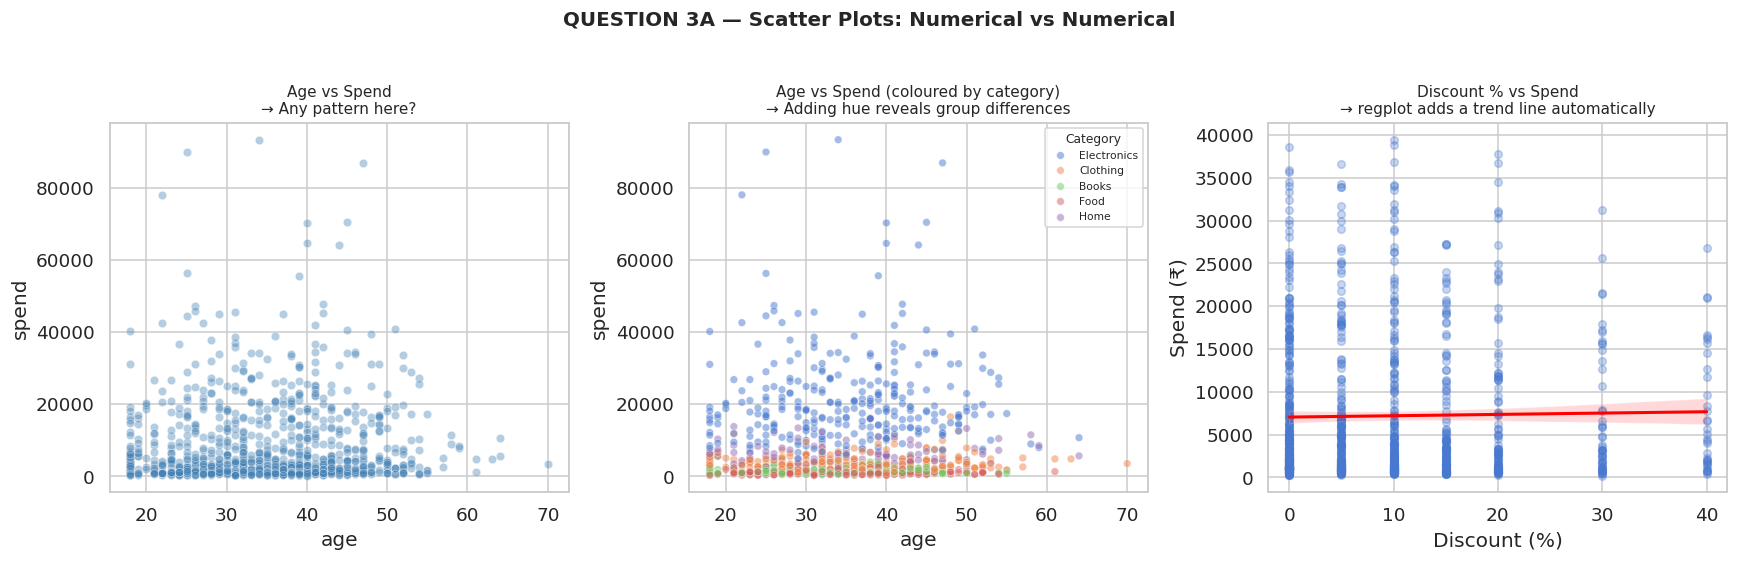


📌 SCATTER PLOT RULES OF THUMB:
  1. Use alpha=0.3–0.5 when you have > 500 points
     → Prevents overplotting (points piled on top of each other)
  2. Cap extreme outliers before plotting scatter
     → df[df['spend'] < 40000] removes top outliers for clarity
  3. Add regplot if you want to test: "Is there a linear trend?"
  4. A scatter that looks like a random cloud → no relationship
  5. A scatter with a clear diagonal pattern → strong relationship



In [ ]:

# ── CELL 11 — Scatter Plot ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("QUESTION 3A — Scatter Plots: Numerical vs Numerical",
             fontsize=13, fontweight='bold', y=1.02)

# Basic scatter
sns.scatterplot(data=df, x='age', y='spend',
                alpha=0.4, s=30, color='steelblue', ax=axes[0])
axes[0].set_title("Age vs Spend\n→ Any pattern here?", fontsize=10)

# Scatter with hue
sns.scatterplot(data=df, x='age', y='spend',
                hue='product_category', alpha=0.5, s=25, ax=axes[1])
axes[1].set_title("Age vs Spend (coloured by category)\n"
                   "→ Adding hue reveals group differences", fontsize=10)
axes[1].legend(fontsize=7, title='Category', title_fontsize=8)

# Scatter with regression line
sns.regplot(data=df[df['spend'] < 40000], x='discount_pct', y='spend',
            scatter_kws={'alpha': 0.3, 's': 25},
            line_kws={'color': 'red', 'lw': 2},
            ax=axes[2])
axes[2].set_title("Discount % vs Spend\n"
                   "→ regplot adds a trend line automatically", fontsize=10)
axes[2].set_xlabel("Discount (%)")
axes[2].set_ylabel("Spend (₹)")

plt.tight_layout()
plt.savefig('/tmp/scatter.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
📌 SCATTER PLOT RULES OF THUMB:
  1. Use alpha=0.3–0.5 when you have > 500 points
     → Prevents overplotting (points piled on top of each other)
  2. Cap extreme outliers before plotting scatter
     → df[df['spend'] < 40000] removes top outliers for clarity
  3. Add regplot if you want to test: "Is there a linear trend?"
  4. A scatter that looks like a random cloud → no relationship
  5. A scatter with a clear diagonal pattern → strong relationship
""")



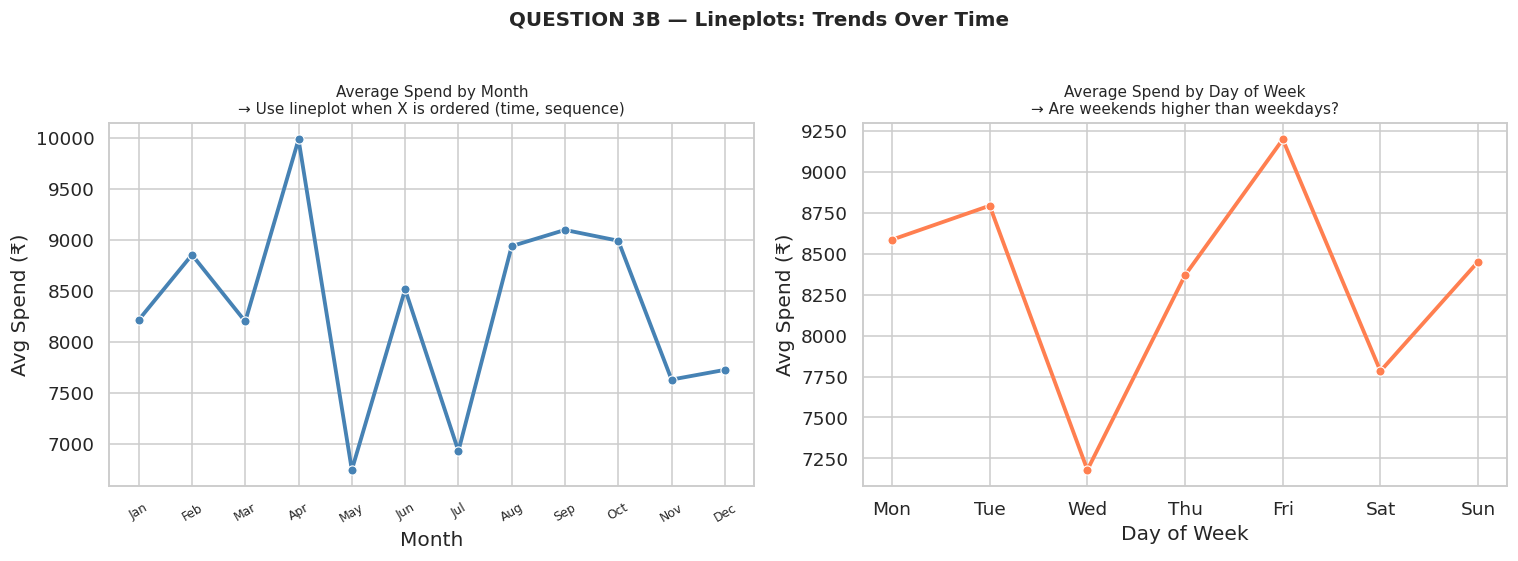


📌 LINEPLOT RULES OF THUMB:
  Use lineplot ONLY when the X-axis has a natural ORDER.
  Good: time (months, days, years), sequential steps
  Bad:  cities, product categories (use barplot instead)

  The line implies continuity between points.
  "Delhi to Mumbai" is not continuous — don't connect with a line.



In [ ]:

# ── CELL 12 — Lineplot: Trends Over Time ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("QUESTION 3B — Lineplots: Trends Over Time",
             fontsize=13, fontweight='bold', y=1.02)

monthly = df.groupby('month')['spend'].mean().reset_index()
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df.groupby('day_of_week')['spend'].mean().reindex(day_order).reset_index()

sns.lineplot(data=monthly, x='month', y='spend', marker='o',
             color='steelblue', linewidth=2.5, ax=axes[0])
axes[0].set_title("Average Spend by Month\n"
                   "→ Use lineplot when X is ordered (time, sequence)",
                   fontsize=10)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Spend (₹)")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'],
                         rotation=30, fontsize=8)

sns.lineplot(data=daily, x='day_of_week', y='spend', marker='o',
             color='coral', linewidth=2.5, ax=axes[1])
axes[1].set_title("Average Spend by Day of Week\n"
                   "→ Are weekends higher than weekdays?",
                   fontsize=10)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Avg Spend (₹)")

plt.tight_layout()
plt.savefig('/tmp/lineplot.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
📌 LINEPLOT RULES OF THUMB:
  Use lineplot ONLY when the X-axis has a natural ORDER.
  Good: time (months, days, years), sequential steps
  Bad:  cities, product categories (use barplot instead)

  The line implies continuity between points.
  "Delhi to Mumbai" is not continuous — don't connect with a line.
""")



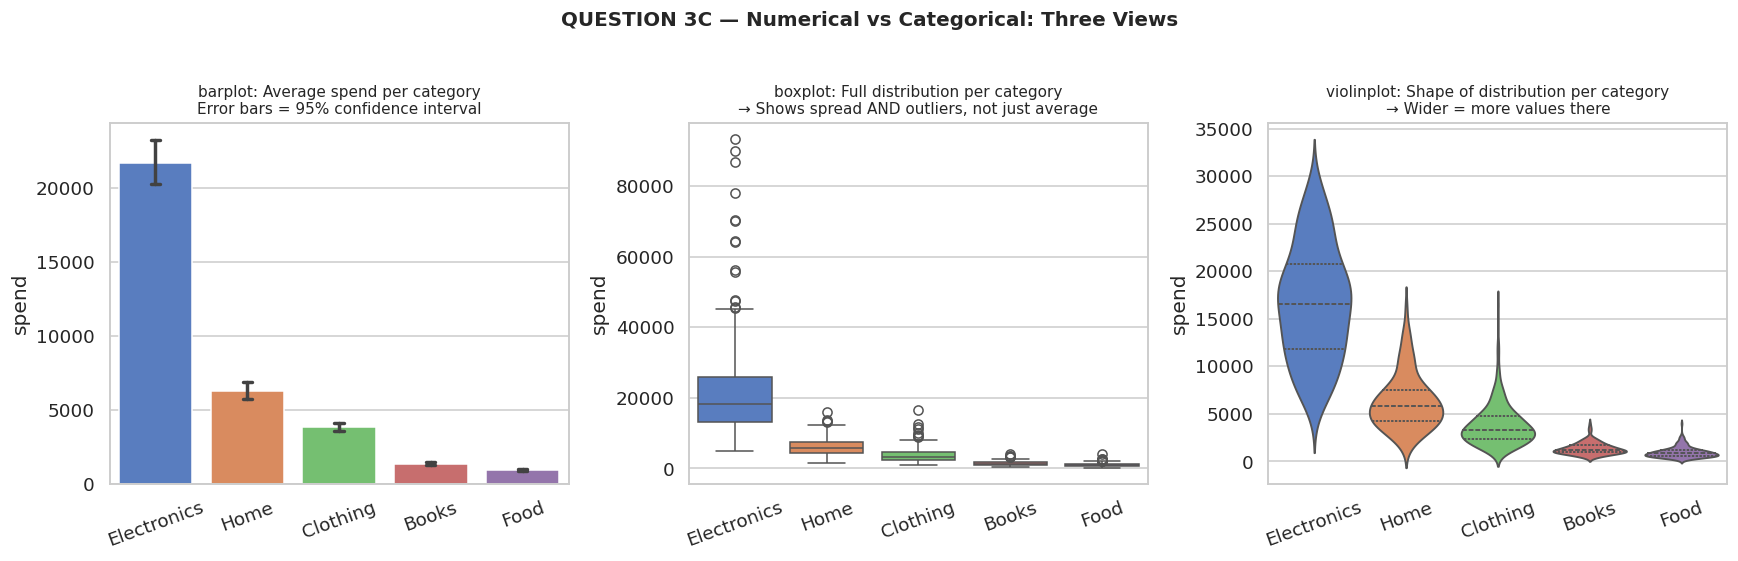


📌 WHICH CHART TO CHOOSE — Numerical vs Categorical:

  barplot   → "What is the AVERAGE for each group?"
              Best for: presenting a simple comparison
              Weakness: hides the spread and shape

  boxplot   → "What is the SPREAD and are there OUTLIERS?"
              Best for: seeing the full picture + outliers
              Weakness: doesn't show the shape of distribution

  violinplot→ "What does the full SHAPE look like per group?"
              Best for: when shape matters (bimodal, skewed)
              Weakness: harder to read for beginners

RULE OF THUMB: Start with barplot. If results look surprising,
switch to boxplot to see why. Use violinplot for final reporting.



In [ ]:

# ── CELL 13 — Barplot & Violinplot ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("QUESTION 3C — Numerical vs Categorical: Three Views",
             fontsize=13, fontweight='bold', y=1.02)

order = ['Electronics', 'Home', 'Clothing', 'Books', 'Food']

# Barplot: average per category
sns.barplot(data=df, x='product_category', y='spend',
            order=order, palette='muted', ax=axes[0],
            errorbar='ci', capsize=0.1)
axes[0].set_title("barplot: Average spend per category\n"
                   "Error bars = 95% confidence interval",
                   fontsize=10)
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=20)

# Boxplot: distribution per category
sns.boxplot(data=df, x='product_category', y='spend',
            order=order, palette='muted', ax=axes[1])
axes[1].set_title("boxplot: Full distribution per category\n"
                   "→ Shows spread AND outliers, not just average",
                   fontsize=10)
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=20)

# Violinplot: shape of distribution per category
sns.violinplot(data=df[df['spend'] < 30000], x='product_category',
               y='spend', order=order, palette='muted',
               inner='quartile', ax=axes[2])
axes[2].set_title("violinplot: Shape of distribution per category\n"
                   "→ Wider = more values there",
                   fontsize=10)
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('/tmp/cat_charts.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
📌 WHICH CHART TO CHOOSE — Numerical vs Categorical:

  barplot   → "What is the AVERAGE for each group?"
              Best for: presenting a simple comparison
              Weakness: hides the spread and shape

  boxplot   → "What is the SPREAD and are there OUTLIERS?"
              Best for: seeing the full picture + outliers
              Weakness: doesn't show the shape of distribution

  violinplot→ "What does the full SHAPE look like per group?"
              Best for: when shape matters (bimodal, skewed)
              Weakness: harder to read for beginners

RULE OF THUMB: Start with barplot. If results look surprising,
switch to boxplot to see why. Use violinplot for final reporting.
""")



QUESTION 4: COMPARING GROUPS


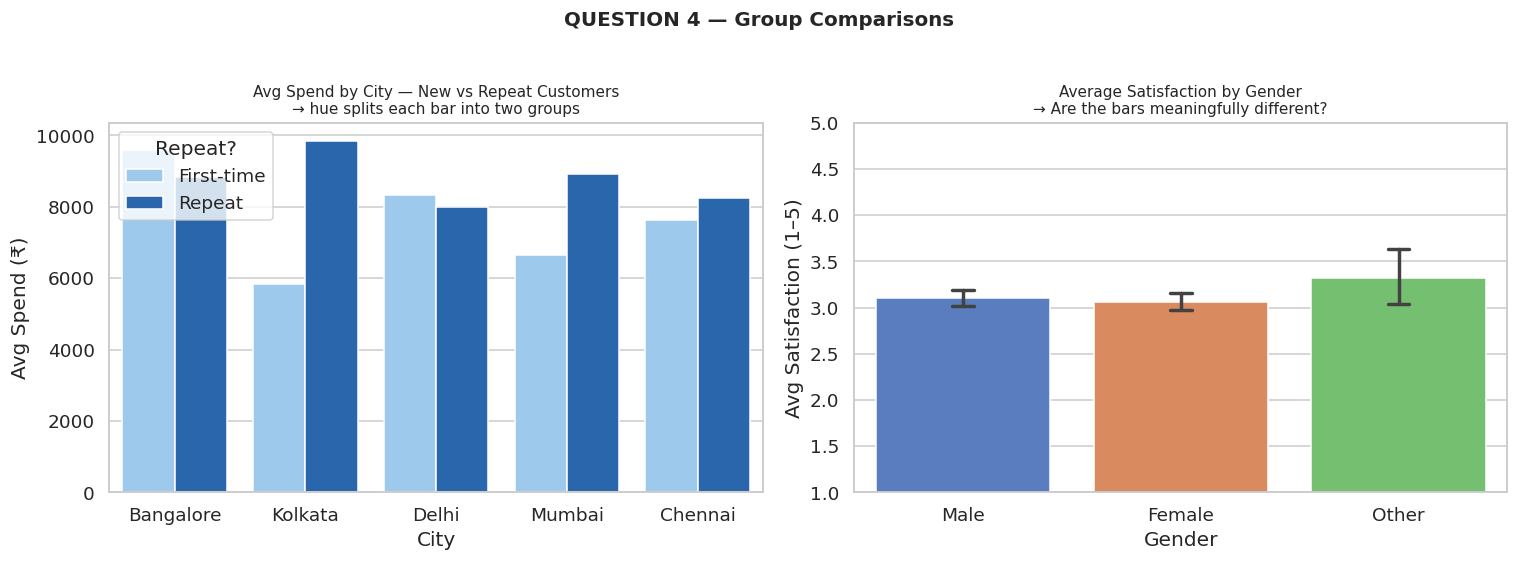


📌 GROUP COMPARISON RULES OF THUMB:
  1. When you add 'hue', you're asking: "Does the pattern
     change for different sub-groups?" This is called
     SEGMENTATION — one of the most powerful EDA moves.

  2. If error bars OVERLAP between groups → the difference
     might not be real. It could be random noise.
     If error bars DON'T overlap → likely a real difference.

  3. Always ask: "Is this difference big enough to matter
     for the business?" A difference of ₹50 on an average
     spend of ₹10,000 is statistically visible but not useful.



In [ ]:


# ════════════════════════════════════════════════════════════
#  QUESTION 4: HOW DO GROUPS COMPARE?
# ════════════════════════════════════════════════════════════
# ── CELL 14 — Grouped Comparisons ────────────────────────────
print("=" * 60)
print("QUESTION 4: COMPARING GROUPS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("QUESTION 4 — Group Comparisons",
             fontsize=13, fontweight='bold', y=1.02)

# Barplot with hue: spend by city AND repeat status
city_order = df.groupby('city')['spend'].mean().sort_values(
    ascending=False).index.tolist()
sns.barplot(data=df, x='city', y='spend', hue='is_repeat',
            order=city_order, palette=['#90CAF9', '#1565C0'],
            ax=axes[0], errorbar=None)
axes[0].set_title("Avg Spend by City — New vs Repeat Customers\n"
                   "→ hue splits each bar into two groups",
                   fontsize=10)
axes[0].set_xlabel("City")
axes[0].set_ylabel("Avg Spend (₹)")
leg = axes[0].get_legend()
if leg:
    leg.set_title("Repeat?")
    for t, l in zip(leg.texts, ['First-time', 'Repeat']):
        t.set_text(l)

# Satisfaction by gender
sns.barplot(data=df, x='gender', y='satisfaction',
            palette='muted', ax=axes[1], errorbar='ci', capsize=0.1)
axes[1].set_title("Average Satisfaction by Gender\n"
                   "→ Are the bars meaningfully different?",
                   fontsize=10)
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Avg Satisfaction (1–5)")
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig('/tmp/group_compare.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
📌 GROUP COMPARISON RULES OF THUMB:
  1. When you add 'hue', you're asking: "Does the pattern
     change for different sub-groups?" This is called
     SEGMENTATION — one of the most powerful EDA moves.

  2. If error bars OVERLAP between groups → the difference
     might not be real. It could be random noise.
     If error bars DON'T overlap → likely a real difference.

  3. Always ask: "Is this difference big enough to matter
     for the business?" A difference of ₹50 on an average
     spend of ₹10,000 is statistically visible but not useful.
""")



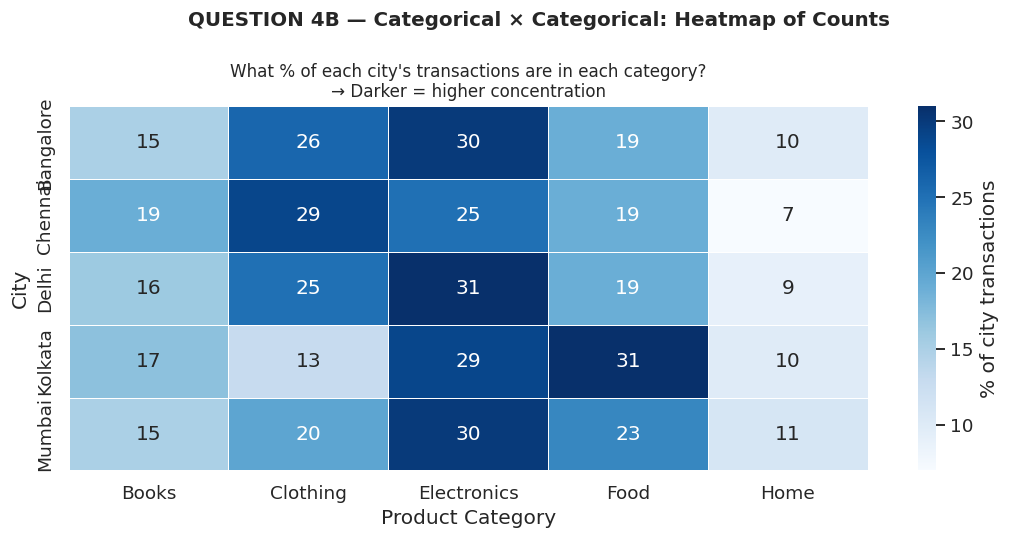


📌 WHEN TO USE A HEATMAP FOR CATEGORIES:
  When you have TWO categorical variables and want to see
  how they interact. Use percentage rows (not raw counts)
  when the categories have different total sizes —
  otherwise the bigger city always looks darker.

  Dark cells = this combination is overrepresented
  Light cells = this combination is underrepresented



In [ ]:

# ── CELL 15 — Categorical vs Categorical Heatmap ─────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("QUESTION 4B — Categorical × Categorical: Heatmap of Counts",
             fontsize=13, fontweight='bold')

cross = pd.crosstab(df['city'], df['product_category'])
cross_pct = cross.div(cross.sum(axis=1), axis=0).round(2) * 100

sns.heatmap(cross_pct, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of city transactions'})
ax.set_title("What % of each city's transactions are in each category?\n"
              "→ Darker = higher concentration", fontsize=11)
ax.set_xlabel("Product Category")
ax.set_ylabel("City")

plt.tight_layout()
plt.savefig('/tmp/cat_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
📌 WHEN TO USE A HEATMAP FOR CATEGORIES:
  When you have TWO categorical variables and want to see
  how they interact. Use percentage rows (not raw counts)
  when the categories have different total sizes —
  otherwise the bigger city always looks darker.

  Dark cells = this combination is overrepresented
  Light cells = this combination is underrepresented
""")



QUESTION 5: PATTERNS ACROSS MANY VARIABLES

CORRELATION:
  A number between -1 and +1 that measures how strongly
  two numerical variables move together.

   +1.0 → Perfect positive relationship (X up → Y up always)
    0.0 → No relationship whatsoever
   -1.0 → Perfect negative relationship (X up → Y down always)

  Rule of thumb for interpreting correlation:
  |r| > 0.7 → Strong
  |r| 0.4–0.7 → Moderate
  |r| 0.2–0.4 → Weak
  |r| < 0.2 → Negligible (treat as no relationship)

⚠️  WARNING: Correlation ≠ Causation
  High correlation between ice cream sales and drowning
  deaths does NOT mean ice cream causes drowning.
  Both are caused by hot weather (a hidden third variable).
  Always think about WHY before claiming a cause.



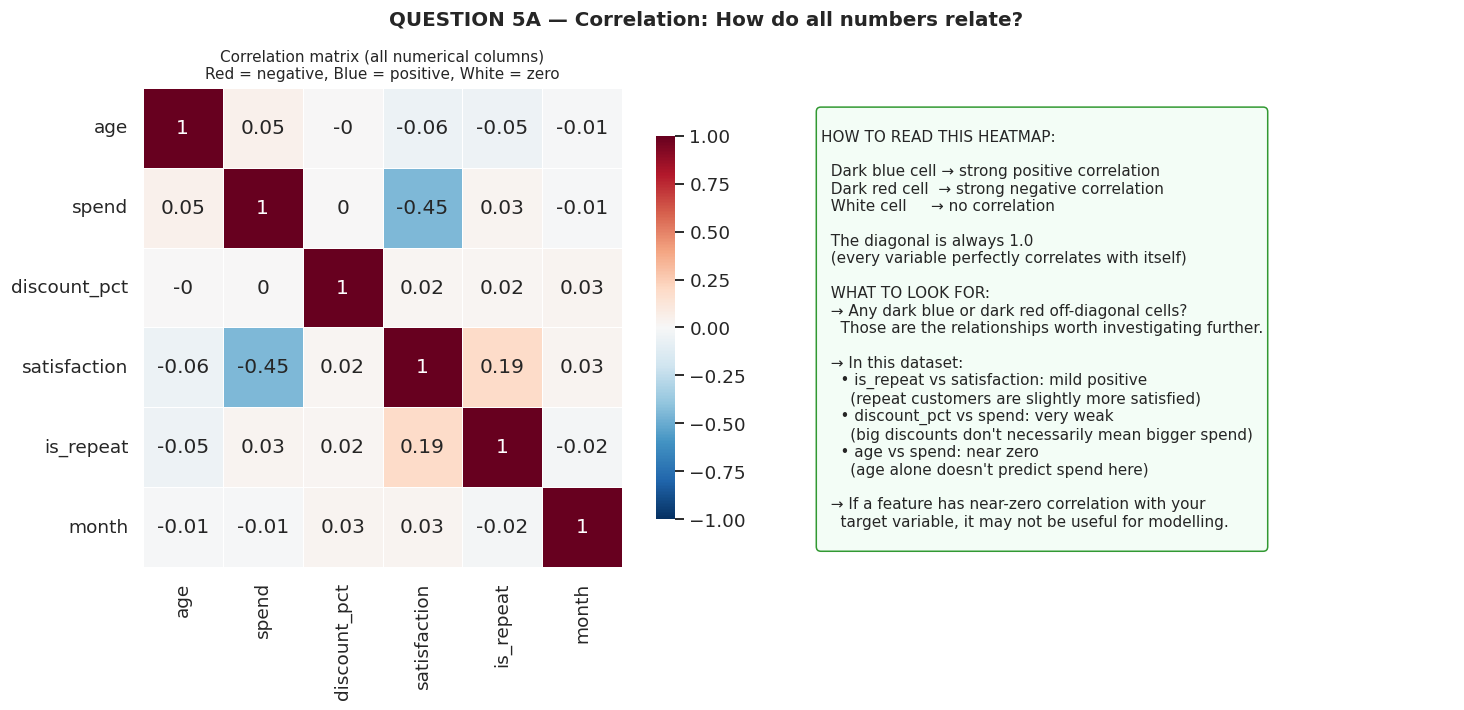

In [ ]:

# ════════════════════════════════════════════════════════════
#  QUESTION 5: PATTERNS ACROSS MANY VARIABLES
# ════════════════════════════════════════════════════════════

# ── CELL 16 — Correlation Heatmap ────────────────────────────
print("=" * 60)
print("QUESTION 5: PATTERNS ACROSS MANY VARIABLES")
print("=" * 60)
print("""
CORRELATION:
  A number between -1 and +1 that measures how strongly
  two numerical variables move together.

   +1.0 → Perfect positive relationship (X up → Y up always)
    0.0 → No relationship whatsoever
   -1.0 → Perfect negative relationship (X up → Y down always)

  Rule of thumb for interpreting correlation:
  |r| > 0.7 → Strong
  |r| 0.4–0.7 → Moderate
  |r| 0.2–0.4 → Weak
  |r| < 0.2 → Negligible (treat as no relationship)

⚠️  WARNING: Correlation ≠ Causation
  High correlation between ice cream sales and drowning
  deaths does NOT mean ice cream causes drowning.
  Both are caused by hot weather (a hidden third variable).
  Always think about WHY before claiming a cause.
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("QUESTION 5A — Correlation: How do all numbers relate?",
             fontsize=13, fontweight='bold', y=1.02)

num_cols = ['age', 'spend', 'discount_pct', 'satisfaction', 'is_repeat', 'month']
corr = df[num_cols].corr().round(2)

# Left: full correlation matrix
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title("Correlation matrix (all numerical columns)\n"
                   "Red = negative, Blue = positive, White = zero",
                   fontsize=10)

# Right: Annotated reading guide
axes[1].axis('off')
guide = """
HOW TO READ THIS HEATMAP:

  Dark blue cell → strong positive correlation
  Dark red cell  → strong negative correlation
  White cell     → no correlation

  The diagonal is always 1.0
  (every variable perfectly correlates with itself)

  WHAT TO LOOK FOR:
  → Any dark blue or dark red off-diagonal cells?
    Those are the relationships worth investigating further.

  → In this dataset:
    • is_repeat vs satisfaction: mild positive
      (repeat customers are slightly more satisfied)
    • discount_pct vs spend: very weak
      (big discounts don't necessarily mean bigger spend)
    • age vs spend: near zero
      (age alone doesn't predict spend here)

  → If a feature has near-zero correlation with your
    target variable, it may not be useful for modelling.
"""
axes[1].text(0.05, 0.95, guide, transform=axes[1].transAxes,
             va='top', ha='left', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='#F0FDF4',
                       edgecolor='green', alpha=0.8))

plt.tight_layout()
plt.savefig('/tmp/correlation.png', dpi=110, bbox_inches='tight')
plt.show()



QUESTION 5B — PAIRPLOT: Every variable vs every other

A PAIRPLOT shows:
  • Diagonal: distribution of each variable (histogram/KDE)
  • Off-diagonal: scatter plot of every pair of variables
  • hue: colours by a categorical variable

WHEN TO USE:
  → You have 3–6 numerical columns and want to see
    ALL relationships in one shot
  → You're looking for which pairs have strong relationships
    before doing formal analysis

WHEN NOT TO USE:
  → More than 7 columns → too many plots, unreadable
  → More than 50,000 rows → too slow and overplotted



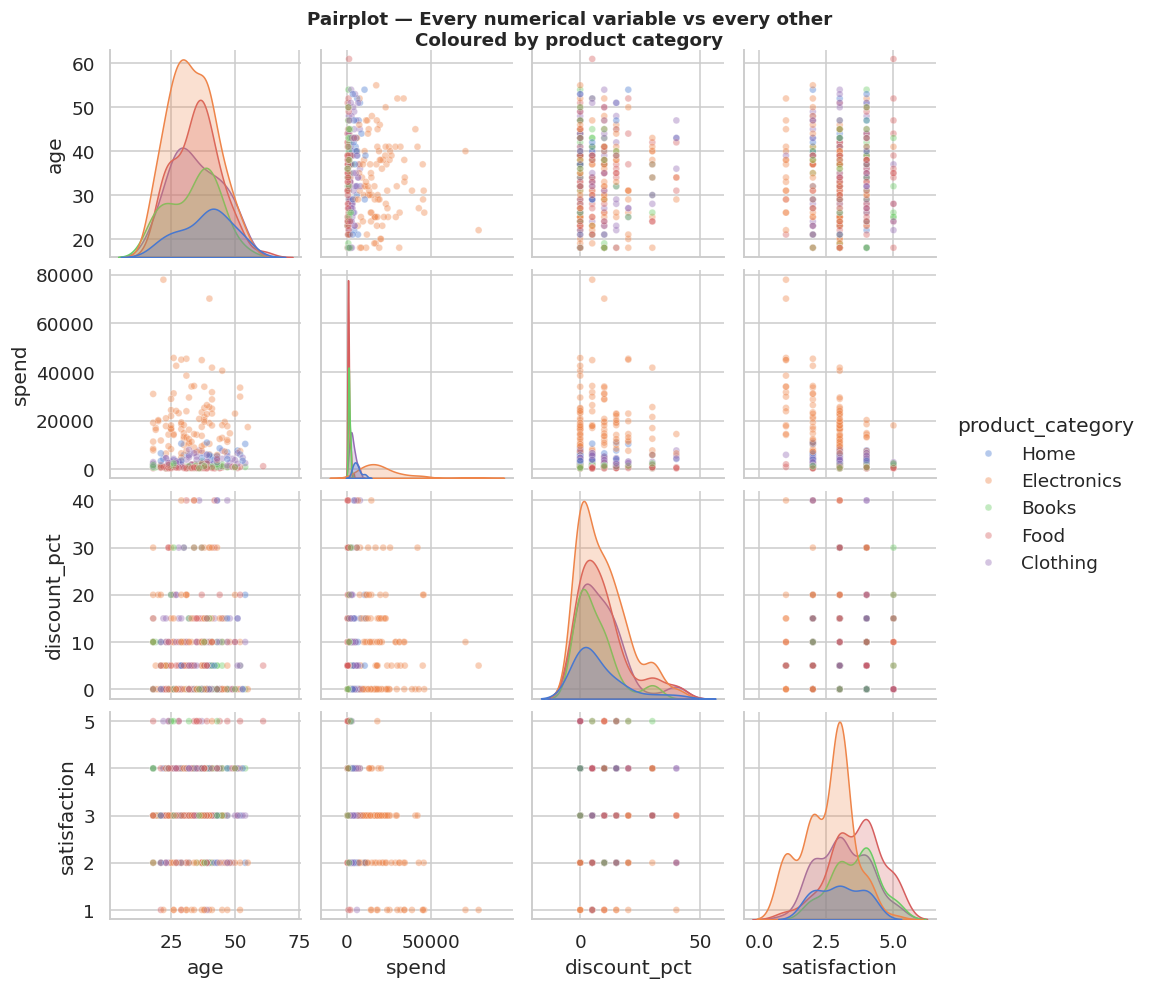


📌 HOW TO READ A PAIRPLOT:
  1. Look at the diagonal first: what shape is each variable?
  2. Scan the off-diagonal: do any scatter plots show a clear
     diagonal or curved pattern? Those are the interesting pairs.
  3. If coloured points cluster separately → category matters
  4. If coloured points overlap completely → category doesn't matter



In [ ]:

# ── CELL 17 — Pairplot ───────────────────────────────────────
print("=" * 60)
print("QUESTION 5B — PAIRPLOT: Every variable vs every other")
print("=" * 60)
print("""
A PAIRPLOT shows:
  • Diagonal: distribution of each variable (histogram/KDE)
  • Off-diagonal: scatter plot of every pair of variables
  • hue: colours by a categorical variable

WHEN TO USE:
  → You have 3–6 numerical columns and want to see
    ALL relationships in one shot
  → You're looking for which pairs have strong relationships
    before doing formal analysis

WHEN NOT TO USE:
  → More than 7 columns → too many plots, unreadable
  → More than 50,000 rows → too slow and overplotted
""")

# Use a sample for speed and clarity
sample = df.sample(300, random_state=42)
pair_cols = ['age', 'spend', 'discount_pct', 'satisfaction']

g = sns.pairplot(sample[pair_cols + ['product_category']],
                 vars=pair_cols,
                 hue='product_category',
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde',
                 height=2.2)
g.fig.suptitle("Pairplot — Every numerical variable vs every other\n"
               "Coloured by product category",
               y=1.02, fontsize=12, fontweight='bold')

plt.savefig('/tmp/pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
📌 HOW TO READ A PAIRPLOT:
  1. Look at the diagonal first: what shape is each variable?
  2. Scan the off-diagonal: do any scatter plots show a clear
     diagonal or curved pattern? Those are the interesting pairs.
  3. If coloured points cluster separately → category matters
  4. If coloured points overlap completely → category doesn't matter
""")



ADVANCED: SMALL MULTIPLES — One chart per group

WHAT IS A SMALL MULTIPLE?
  The same chart, repeated for each group.
  Makes it easy to compare distributions or trends
  across many categories without overlapping colours.

WHEN TO USE:
  → You have 3+ groups and overlapping them (with hue)
    makes the chart unreadable
  → You want to see the FULL pattern for each group,
    not just the average



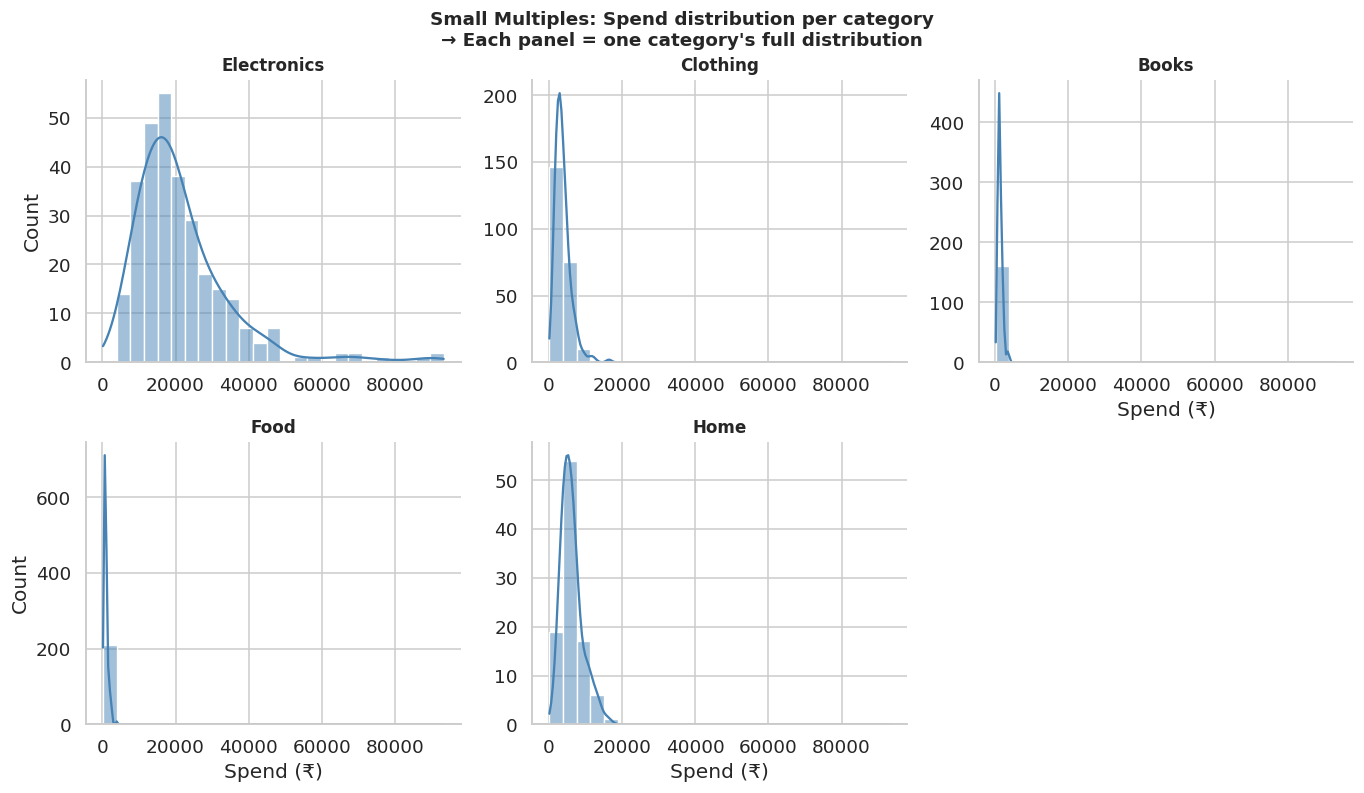

In [ ]:

# ════════════════════════════════════════════════════════════
#  ADVANCED: FACET GRIDS & MULTI-PANEL CHARTS
# ════════════════════════════════════════════════════════════

# ── CELL 18 — FacetGrid / displot col= ───────────────────────
print("=" * 60)
print("ADVANCED: SMALL MULTIPLES — One chart per group")
print("=" * 60)
print("""
WHAT IS A SMALL MULTIPLE?
  The same chart, repeated for each group.
  Makes it easy to compare distributions or trends
  across many categories without overlapping colours.

WHEN TO USE:
  → You have 3+ groups and overlapping them (with hue)
    makes the chart unreadable
  → You want to see the FULL pattern for each group,
    not just the average
""")

# displot with col= splits into separate panels
g = sns.displot(
    data=df, x='spend', col='product_category',
    col_wrap=3, height=3.5, aspect=1.2,
    kde=True, bins=25, color='steelblue',
    facet_kws={'sharex': False, 'sharey': False}
)
g.set_titles("{col_name}", size=11, fontweight='bold')
g.set_axis_labels("Spend (₹)", "Count")
g.fig.suptitle("Small Multiples: Spend distribution per category\n"
               "→ Each panel = one category's full distribution",
               y=1.03, fontsize=12, fontweight='bold')

plt.savefig('/tmp/facet_dist.png', dpi=100, bbox_inches='tight')
plt.show()



In [ ]:

# ── CELL 19 — THE COMPLETE EDA CHEAT SHEET ───────────────────
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                   COMPLETE EDA CHEAT SHEET                           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STEP 1: UNDERSTAND YOUR DATA                                        ║
║    df.shape          → rows and columns                              ║
║    df.info()         → column types                                  ║
║    df.describe()     → basic statistics                              ║
║    df.isnull().sum() → missing values                                ║
║    df.head()         → first 5 rows                                  ║
║                                                                      ║
║  STEP 2: SINGLE VARIABLE DISTRIBUTION                                ║
║    Continuous number → sns.histplot(df, x='col', kde=True)           ║
║    Categorical       → sns.countplot(df, x='col', order=...)         ║
║    Outliers/spread   → sns.boxplot(df, y='col')                      ║
║                                                                      ║
║  STEP 3: TWO VARIABLES                                               ║
║    Number × Number   → sns.scatterplot / sns.regplot                 ║
║    Number × Category → sns.barplot / sns.boxplot / sns.violinplot    ║
║    Category × Category → pd.crosstab + sns.heatmap                   ║
║    Time trend        → sns.lineplot (only for ordered X)             ║
║                                                                      ║
║  STEP 4: ADD A THIRD DIMENSION                                       ║
║    Add hue=          → colour by a category                          ║
║    Add size=         → scale dots by a number                        ║
║    Add col=          → split into separate panels                    ║
║                                                                      ║
║  STEP 5: ALL VARIABLES AT ONCE                                       ║
║    sns.pairplot()    → every variable vs every other                 ║
║    df.corr() + sns.heatmap() → correlation matrix                    ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  MASTER RULES OF THUMB                                               ║
║                                                                      ║
║  1. ALWAYS start with Question 1 before any chart                    ║
║  2. For skewed data → use MEDIAN, not mean                           ║
║  3. For > 500 points → use alpha=0.3 in scatter plots                ║
║  4. For ordered X-axis → use lineplot                                ║
║  5. For unordered X-axis → use barplot                               ║
║  6. Sort bars by value (tallest first)                               ║
║  7. Correlation ≠ Causation — ALWAYS ask WHY                         ║
║  8. Overlapping hue → try col= (small multiples) instead             ║
║  9. Missing > 20% → consider dropping the column                     ║
║  10. barplot → average only; boxplot → full picture                  ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  CHART SELECTION QUICK GUIDE                                         ║
║                                                                      ║
║  Question                      Best Chart                            ║
║  ─────────────────────────────────────────────────────────────────   ║
║  Shape of one number?          histplot (+ kde=True)                 ║
║  Count of categories?          countplot (sorted)                    ║
║  Outliers in one number?       boxplot                               ║
║  Trend over time?              lineplot                              ║
║  Two numbers related?          scatterplot / regplot                 ║
║  Average by group?             barplot                               ║
║  Full distribution by group?   boxplot / violinplot                  ║
║  Two categories related?       heatmap (crosstab %)                  ║
║  All numbers at once?          pairplot / correlation heatmap        ║
║  Each group side by side?      col= small multiples                  ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


# ── CELL 20 — PRACTICE EXERCISES ────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    PRACTICE EXERCISES                                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  [EASY] Using the df dataset:                                        ║
║  1. Plot a histogram of 'age'. Is it symmetric or skewed?            ║
║  2. Which day of week has the most transactions? (countplot)         ║
║  3. What is the median spend for first-time vs repeat customers?     ║
║                                                                      ║
║  [MEDIUM]                                                            ║
║  4. Does satisfaction differ between product categories?             ║
║     Use a boxplot with x='product_category', y='satisfaction'        ║
║  5. Is there a relationship between discount_pct and satisfaction?   ║
║     Use scatterplot. What do you observe?                            ║
║  6. Plot spend by month as a lineplot. Which month has highest       ║
║     average spend?                                                   ║
║                                                                      ║
║  [HARD]                                                              ║
║  7. Create a heatmap showing the average SATISFACTION for each       ║
║     city × product_category combination.                             ║
║     Hint: df.groupby(['city','product_category'])['satisfaction']    ║
║           .mean().unstack() → then sns.heatmap()                     ║
║  8. Build a pairplot using only Electronics transactions.            ║
║     Does the pattern look different from the full dataset?           ║
║  9. Create a small-multiples chart (col='city') showing the          ║
║     spend distribution in each city separately.                      ║
║     Which city has the most outliers?                                ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                   COMPLETE EDA CHEAT SHEET                           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STEP 1: UNDERSTAND YOUR DATA                                        ║
║    df.shape          → rows and columns                              ║
║    df.info()         → column types                                  ║
║    df.describe()     → basic statistics                              ║
║    df.isnull().sum() → missing values                                ║
║    df.head()         → first 5 rows                                  ║
║                                                                      ║
║  STEP 2: SINGLE VARIABLE DISTRIBUTION                                ║
║    Continuous number → sns.histplot(df, x='col', kde=True)           ║
║    Categorical       → sns.countplot(df, x='col'

# ================================================================
#  THINK STATS 2 — FOLLOW-ALONG EXERCISE NOTEBOOK
#  Based on: "Think Stats: Exploratory Data Analysis in Python"
#             by Allen B. Downey (Free PDF: greenteapress.com)
#
#  Philosophy: Every exercise uses ONE relatable dataset.
#              Every concept is explained before the code.
#              Every section has a fill-in-the-blank exercise.
#
#  Dataset: Synthetic Indian health survey data (~2000 respondents)
#           — inspired by NSFG but fully India-context friendly
#  Chapters covered: 1 → 14 (all chapters)
# ================================================================


In [ ]:

# ════════════════════════════════════════════════════════════════
#  CELL 0 — SETUP (run this first, every session)
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 108

print("✅  All libraries loaded successfully.")
print("    pandas     :", pd.__version__)
print("    numpy      :", np.__version__)
print("    scipy      :", stats.__version__ if hasattr(stats,'__version__') else "ok")


# ════════════════════════════════════════════════════════════════
#  CELL 1 — GENERATE THE SURVEY DATASET
#  (replaces NSFG — same structure, India health survey context)
# ════════════════════════════════════════════════════════════════
"""
DATASET: IndiaHealthSurvey — 2000 respondents
Inspired by NSFG structure. Variables:

  respondent_id  : unique ID
  age            : age of respondent (18–45)
  state          : UP / Maharashtra / Tamil Nadu / Rajasthan / WB
  income_bracket : Low / Middle / High
  num_pregnancies: total number of pregnancies (0–8)
  pregnancy_weeks: duration of most recent pregnancy (weeks)
  birth_weight_kg: birth weight of most recent live birth (kg)
  outcome        : 1=Live birth 2=Miscarriage 3=Stillbirth 4=None
  birth_order    : 1=first child, 2=second, etc (NaN if no birth)
  mother_age_birth: mother's age at birth (NaN if no birth)
  bmi            : body mass index
  education_yrs  : years of formal education
  survey_weight  : statistical weight for population inference
"""

N = 2000
states   = ['UP', 'Maharashtra', 'Tamil Nadu', 'Rajasthan', 'West Bengal']
income   = ['Low', 'Middle', 'High']
outcomes = [1, 2, 3, 4]

state_col   = np.random.choice(states, N, p=[0.30, 0.22, 0.18, 0.17, 0.13])
income_col  = np.random.choice(income, N, p=[0.40, 0.45, 0.15])
age_col     = np.random.normal(30, 6, N).clip(18, 45).round(1)
edu_col     = np.random.normal(10, 3, N).clip(0, 18).round(0).astype(int)
bmi_col     = np.random.normal(23, 4, N).clip(14, 40).round(1)

# Num pregnancies: correlated with age
num_preg    = np.clip(np.round(
                (age_col - 18) / 6 + np.random.normal(0, 0.8, N)
              ), 0, 8).astype(int)

# Outcome: mostly live births, some miscarriages
outcome_col = np.where(num_preg == 0, 4,
              np.random.choice([1,2,3], N, p=[0.82, 0.15, 0.03]))
outcome_col = np.where(num_preg == 0, 4, outcome_col)

# Birth weight: normally distributed, slight low-income effect
bwt = np.where(
    outcome_col == 1,
    np.random.normal(2.9, 0.45, N) - 0.15*(income_col == 'Low'),
    np.nan
)
bwt = np.where(bwt < 0.5, np.nan, bwt).round(2)

# Pregnancy weeks: live births ~38–40 weeks, others shorter
preg_weeks = np.where(
    outcome_col == 1, np.random.normal(38.5, 2.1, N).clip(24, 44),
    np.where(outcome_col == 2, np.random.normal(12, 4, N).clip(4, 24),
    np.where(outcome_col == 3, np.random.normal(30, 5, N).clip(20, 40),
    np.nan))
).round(1)

birth_order = np.where(outcome_col == 1,
                        np.minimum(num_preg, 4), np.nan)
mother_age_birth = np.where(
    outcome_col == 1,
    np.clip(age_col - np.random.uniform(0, 5, N), 18, 42).round(1),
    np.nan)

# Inject 5% missing in birth_weight and pregnancy_weeks
for arr in [bwt, preg_weeks]:
    mask = (np.random.random(N) < 0.05) & (~np.isnan(arr))
    arr[mask] = np.nan

survey_weight = np.random.uniform(0.5, 3.0, N).round(3)

# Inject one impossible value (like the 51-pound baby in the book)
bwt[np.random.randint(0, N)] = 18.0   # ← obvious error to find

df = pd.DataFrame({
    'respondent_id':    range(1001, 1001 + N),
    'age':              age_col,
    'state':            state_col,
    'income_bracket':   income_col,
    'num_pregnancies':  num_preg,
    'pregnancy_weeks':  preg_weeks,
    'birth_weight_kg':  bwt,
    'outcome':          outcome_col,
    'birth_order':      birth_order,
    'mother_age_birth': mother_age_birth,
    'bmi':              bmi_col,
    'education_yrs':    edu_col,
    'survey_weight':    survey_weight,
})

print(f"✅  Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head(3).to_string())



✅  All libraries loaded successfully.
    pandas     : 2.2.2
    numpy      : 2.0.2
    scipy      : ok
✅  Dataset created: 2000 rows × 13 columns
   respondent_id   age        state income_bracket  num_pregnancies  pregnancy_weeks  birth_weight_kg  outcome  birth_order  mother_age_birth   bmi  education_yrs  survey_weight
0           1001  38.0  Maharashtra            Low                4             40.3             2.14        1          4.0              36.3  19.6              9          0.526
1           1002  31.9  West Bengal            Low                3             40.6             2.65        1          3.0              29.0  21.4              7          2.287
2           1003  26.4    Rajasthan           High                1             39.4             2.47        1          1.0              25.2  24.1             11          1.674


In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 1: EXPLORATORY DATA ANALYSIS ░░░░
#  Book pages 1–15
#  Core idea: Before any analysis, understand what you have.
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 1 — Exploratory Data Analysis                  ║
║  Key question: "What is in this dataset?"               ║
╚══════════════════════════════════════════════════════════╝

Think Stats teaches that good analysis follows this order:
  1. Import & clean
  2. Single-variable exploration
  3. Pair-wise exploration
  4. Multivariate analysis
  5. Estimation & hypothesis testing

We'll follow this exact sequence through all 14 chapters.
""")

# ── Exercise 1.1: DataFrame basics ───────────────────────────
print("─" * 55)
print("EXERCISE 1.1 — Inspect the DataFrame")
print("─" * 55)

# Completed example
print("\n[EXAMPLE] Shape of dataset:")
print(df.shape)

print("\n[EXAMPLE] Column names and types:")
print(df.dtypes)

print("\n[EXAMPLE] First 5 rows:")
print(df.head())



╔══════════════════════════════════════════════════════════╗
║  CHAPTER 1 — Exploratory Data Analysis                  ║
║  Key question: "What is in this dataset?"               ║
╚══════════════════════════════════════════════════════════╝

Think Stats teaches that good analysis follows this order:
  1. Import & clean
  2. Single-variable exploration
  3. Pair-wise exploration
  4. Multivariate analysis
  5. Estimation & hypothesis testing

We'll follow this exact sequence through all 14 chapters.

───────────────────────────────────────────────────────
EXERCISE 1.1 — Inspect the DataFrame
───────────────────────────────────────────────────────

[EXAMPLE] Shape of dataset:
(2000, 13)

[EXAMPLE] Column names and types:
respondent_id         int64
age                 float64
state                object
income_bracket       object
num_pregnancies       int64
pregnancy_weeks     float64
birth_weight_kg     float64
outcome               int64
birth_order         float64
mother_age_birth 

In [ ]:

# ── Exercise 1.2: Value counts (validation) ───────────────────
print("─" * 55)
print("EXERCISE 1.2 — Validate your data using value_counts()")
print("─" * 55)
print("""
In the book, Downey validates the NSFG 'outcome' column by
comparing value_counts() to the published codebook table.
We do the same here.

Expected outcome codes:
  1 = Live birth    (most common, ~82% of pregnancies)
  2 = Miscarriage   (~15%)
  3 = Stillbirth    (~3%)
  4 = No pregnancy
""")

print("[EXAMPLE] outcome value_counts:")
print(df['outcome'].value_counts().sort_index())

print("\n[EXAMPLE] state distribution:")
print(df['state'].value_counts())

print("""
✏️  YOUR TURN:
    1. Run value_counts() on 'income_bracket'
    2. Run value_counts() on 'birth_order'
    3. Does birth_order have NaN values? Why?
""")
# --- Student fills in here ---

───────────────────────────────────────────────────────
EXERCISE 1.2 — Validate your data using value_counts()
───────────────────────────────────────────────────────

In the book, Downey validates the NSFG 'outcome' column by
comparing value_counts() to the published codebook table.
We do the same here.

Expected outcome codes:
  1 = Live birth    (most common, ~82% of pregnancies)
  2 = Miscarriage   (~15%)
  3 = Stillbirth    (~3%)
  4 = No pregnancy

[EXAMPLE] outcome value_counts:
outcome
1    1423
2     284
3      51
4     242
Name: count, dtype: int64

[EXAMPLE] state distribution:
state
UP             615
Maharashtra    413
Tamil Nadu     377
Rajasthan      330
West Bengal    265
Name: count, dtype: int64

✏️  YOUR TURN:
    1. Run value_counts() on 'income_bracket'
    2. Run value_counts() on 'birth_order'
    3. Does birth_order have NaN values? Why?



In [ ]:

# ── Exercise 1.3: Find and fix the data error ─────────────────
print("─" * 55)
print("EXERCISE 1.3 — Finding errors (like the 51-pound baby)")
print("─" * 55)
print("""
The book finds a 51-pound baby in the data — clearly wrong.
We injected a similar error: an 18 kg birth weight.
Normal range: 0.5 kg – 5.0 kg

Step 1: Find the error
Step 2: Replace it with NaN
Step 3: Verify it's gone
""")

print("[EXAMPLE] Max birth weight before cleaning:")
print(f"  Max: {df['birth_weight_kg'].max()} kg  ← this is impossible")

# Clean it (mirrors CleanFemPreg in the book)
df.loc[df['birth_weight_kg'] > 6.0, 'birth_weight_kg'] = np.nan

print(f"[EXAMPLE] Max birth weight after cleaning:")
print(f"  Max: {df['birth_weight_kg'].max():.2f} kg  ✅  fixed")

print("""
✏️  YOUR TURN:
    1. Check if 'pregnancy_weeks' has any impossible values
       (Normal range: 4–44 weeks)
    2. Check if 'bmi' has any impossible values
       (Normal range: 10–55)
    3. Fix any you find using: df.loc[condition, 'col'] = np.nan
""")

───────────────────────────────────────────────────────
EXERCISE 1.3 — Finding errors (like the 51-pound baby)
───────────────────────────────────────────────────────

The book finds a 51-pound baby in the data — clearly wrong.
We injected a similar error: an 18 kg birth weight.
Normal range: 0.5 kg – 5.0 kg

Step 1: Find the error
Step 2: Replace it with NaN
Step 3: Verify it's gone

[EXAMPLE] Max birth weight before cleaning:
  Max: 18.0 kg  ← this is impossible
[EXAMPLE] Max birth weight after cleaning:
  Max: 4.29 kg  ✅  fixed

✏️  YOUR TURN:
    1. Check if 'pregnancy_weeks' has any impossible values
       (Normal range: 4–44 weeks)
    2. Check if 'bmi' has any impossible values
       (Normal range: 10–55)
    3. Fix any you find using: df.loc[condition, 'col'] = np.nan



In [ ]:


# ── Exercise 1.4: Create a new variable ──────────────────────
print("─" * 55)
print("EXERCISE 1.4 — Transformation (creating new variables)")
print("─" * 55)
print("""
The book creates 'totalwgt_lb' from pounds + ounces.
We create 'is_first_birth' — whether this was the mother's
first child — which will be our running comparison variable
throughout the notebook (mirrors the book's first-baby question).
""")

# Create is_first_birth: 1 if birth_order == 1
df['is_first_birth'] = (df['birth_order'] == 1).astype(float)
df.loc[df['birth_order'].isna(), 'is_first_birth'] = np.nan

first_births   = df[df['birth_order'] == 1]
later_births   = df[df['birth_order'] > 1]

print(f"First births  : {len(first_births)}")
print(f"Later births  : {len(later_births)}")
print(f"\nMean preg weeks — first  : {first_births['pregnancy_weeks'].mean():.2f}")
print(f"Mean preg weeks — later  : {later_births['pregnancy_weeks'].mean():.2f}")
print("\n→ Is there a difference? We'll test this properly in Chapter 9.")


───────────────────────────────────────────────────────
EXERCISE 1.4 — Transformation (creating new variables)
───────────────────────────────────────────────────────

The book creates 'totalwgt_lb' from pounds + ounces.
We create 'is_first_birth' — whether this was the mother's
first child — which will be our running comparison variable
throughout the notebook (mirrors the book's first-baby question).

First births  : 387
Later births  : 1036

Mean preg weeks — first  : 38.52
Mean preg weeks — later  : 38.49

→ Is there a difference? We'll test this properly in Chapter 9.



╔══════════════════════════════════════════════════════════╗
║  CHAPTER 2 — Distributions                              ║
║  Key question: "What values does this variable take?"   ║
╚══════════════════════════════════════════════════════════╝

EXERCISE 2.1 — Build a histogram from scratch, then with seaborn

The book implements Hist() as a dictionary: {value: count}.
We do this manually first so you understand what seaborn does.

[MANUAL HIST] Most common pregnancy length: 38.2 weeks (n=35)


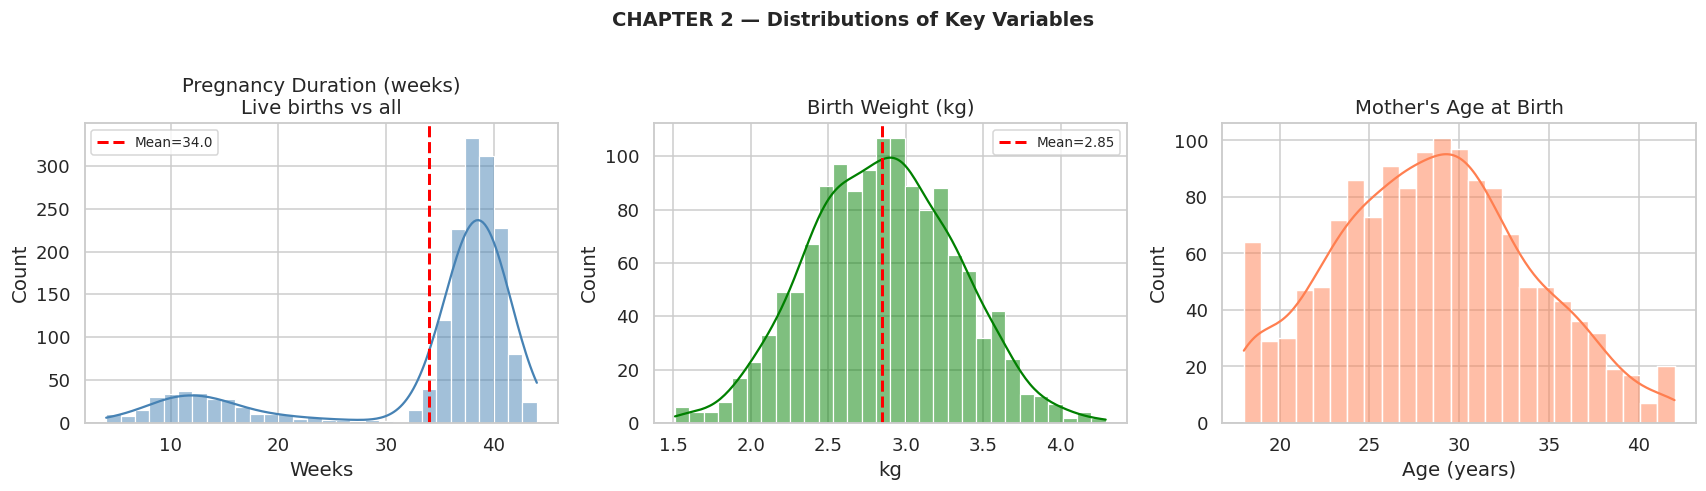

In [ ]:


# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 2: DISTRIBUTIONS ░░░░
#  Book pages 17–29
#  Core idea: Histograms summarise a variable's full picture.
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 2 — Distributions                               ║
║  Key question: "What values does this variable take?"    ║
╚══════════════════════════════════════════════════════════╝
""")

# ── Exercise 2.1: Build a histogram manually (then with seaborn)
print("EXERCISE 2.1 — Build a histogram from scratch, then with seaborn")
print("""
The book implements Hist() as a dictionary: {value: count}.
We do this manually first so you understand what seaborn does.
""")

# Manual histogram (Downey's approach)
weeks_clean = df['pregnancy_weeks'].dropna()
hist_manual = {}
for w in weeks_clean:
    hist_manual[w] = hist_manual.get(w, 0) + 1

# Find the mode
mode_week = max(hist_manual, key=hist_manual.get)
print(f"[MANUAL HIST] Most common pregnancy length: {mode_week} weeks "
      f"(n={hist_manual[mode_week]})")

# Now plot with seaborn
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("CHAPTER 2 — Distributions of Key Variables",
             fontsize=13, fontweight='bold', y=1.01)

# Pregnancy weeks
sns.histplot(weeks_clean, bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Pregnancy Duration (weeks)\nLive births vs all")
axes[0].set_xlabel("Weeks")
axes[0].axvline(weeks_clean.mean(), color='red', lw=2, ls='--',
                label=f'Mean={weeks_clean.mean():.1f}')
axes[0].legend(fontsize=9)

# Birth weight
bwt_clean = df['birth_weight_kg'].dropna()
sns.histplot(bwt_clean, bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title("Birth Weight (kg)")
axes[1].set_xlabel("kg")
axes[1].axvline(bwt_clean.mean(), color='red', lw=2, ls='--',
                label=f'Mean={bwt_clean.mean():.2f}')
axes[1].legend(fontsize=9)

# Mother's age at birth
age_clean = df['mother_age_birth'].dropna()
sns.histplot(age_clean, bins=25, kde=True, ax=axes[2], color='coral')
axes[2].set_title("Mother's Age at Birth")
axes[2].set_xlabel("Age (years)")

plt.tight_layout()
plt.savefig('/tmp/ch2_distributions.png', dpi=108, bbox_inches='tight')
plt.show()


In [ ]:

# ── Exercise 2.2: Outliers ────────────────────────────────────
print("EXERCISE 2.2 — Spotting and handling outliers")
print("""
The book shows that 0.5% of birth weights are above 10 lbs.
Identify outliers using the IQR method:
  Lower fence = Q1 - 1.5 × IQR
  Upper fence = Q3 + 1.5 × IQR
""")

Q1  = bwt_clean.quantile(0.25)
Q3  = bwt_clean.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers    = bwt_clean[(bwt_clean < lower_fence) | (bwt_clean > upper_fence)]

print(f"Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
print(f"Lower fence: {lower_fence:.2f}  Upper fence: {upper_fence:.2f}")
print(f"Outliers found: {len(outliers)} ({len(outliers)/len(bwt_clean)*100:.1f}%)")


EXERCISE 2.2 — Spotting and handling outliers

The book shows that 0.5% of birth weights are above 10 lbs.
Identify outliers using the IQR method:
  Lower fence = Q1 - 1.5 × IQR
  Upper fence = Q3 + 1.5 × IQR

Q1=2.51  Q3=3.18  IQR=0.67
Lower fence: 1.50  Upper fence: 4.19
Outliers found: 2 (0.1%)


In [ ]:

# ── Exercise 2.3: Summary statistics & effect size ───────────
print("\nEXERCISE 2.3 — Summary statistics and Cohen's d (effect size)")
print("""
The book introduces Cohen's d to measure effect size:
  d = (mean1 - mean2) / pooled_std

Rule of thumb:
  d < 0.2  → small effect
  d ~ 0.5  → medium effect
  d > 0.8  → large effect
""")

def cohens_d(group1, group2):
    """Cohen's d: standardised difference between two group means."""
    diff    = group1.mean() - group2.mean()
    n1, n2  = len(group1), len(group2)
    pooled_std = np.sqrt(
        ((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2)
    )
    return diff / pooled_std

fb_weeks = first_births['pregnancy_weeks'].dropna()
lb_weeks = later_births['pregnancy_weeks'].dropna()
d        = cohens_d(fb_weeks, lb_weeks)

print(f"First births  — mean weeks: {fb_weeks.mean():.2f}, std: {fb_weeks.std():.2f}")
print(f"Later births  — mean weeks: {lb_weeks.mean():.2f}, std: {lb_weeks.std():.2f}")
print(f"Cohen's d: {d:.4f}")
print(f"Interpretation: {'small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large'} effect")

print("""
✏️  YOUR TURN:
    1. Compute Cohen's d for birth_weight_kg: first vs later births
    2. Is the effect larger or smaller than for pregnancy_weeks?
    3. What does this tell you about the "first baby effect"?
""")




EXERCISE 2.3 — Summary statistics and Cohen's d (effect size)

The book introduces Cohen's d to measure effect size:
  d = (mean1 - mean2) / pooled_std

Rule of thumb:
  d < 0.2  → small effect
  d ~ 0.5  → medium effect
  d > 0.8  → large effect

First births  — mean weeks: 38.52, std: 1.91
Later births  — mean weeks: 38.49, std: 2.11
Cohen's d: 0.0146
Interpretation: small effect

✏️  YOUR TURN:
    1. Compute Cohen's d for birth_weight_kg: first vs later births
    2. Is the effect larger or smaller than for pregnancy_weeks?
    3. What does this tell you about the "first baby effect"?




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 3 — Probability Mass Functions                 ║
║  Key idea: PMF = normalised histogram (sums to 1.0)     ║
╚══════════════════════════════════════════════════════════╝

A histogram shows RAW COUNTS.
A PMF shows PROBABILITIES: P(X = x) for each value x.
PMF is better for comparing two groups of DIFFERENT SIZE.

EXERCISE 3.1 — Build a PMF manually and plot it


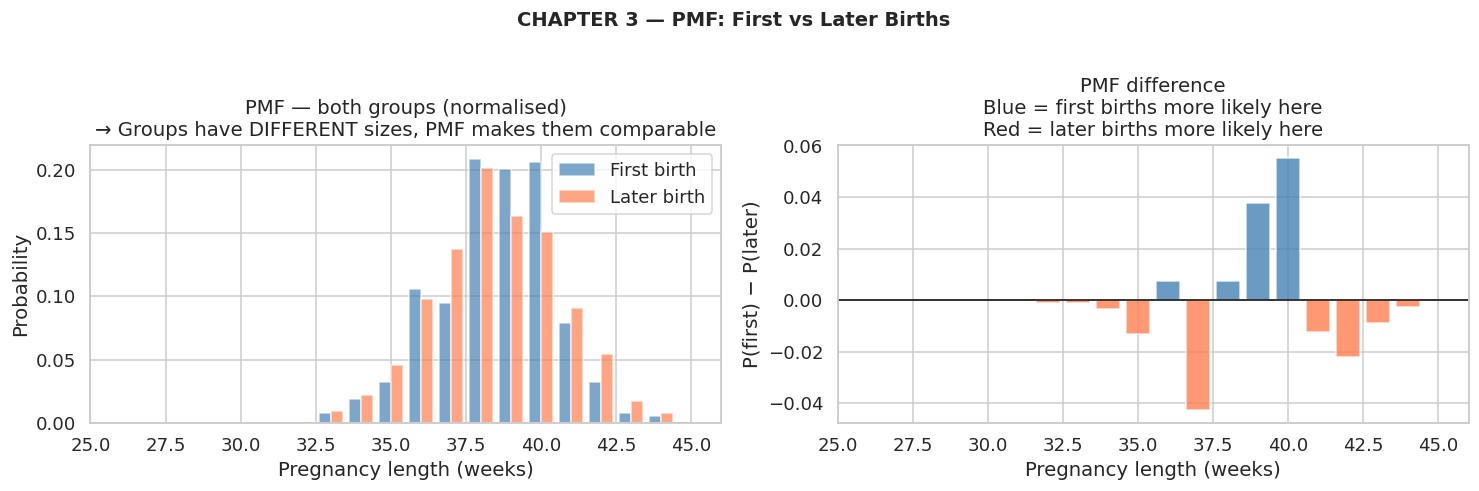

In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 3: PROBABILITY MASS FUNCTIONS (PMF) ░░░░
#  Book pages 31–43
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 3 — Probability Mass Functions                 ║
║  Key idea: PMF = normalised histogram (sums to 1.0)     ║
╚══════════════════════════════════════════════════════════╝

A histogram shows RAW COUNTS.
A PMF shows PROBABILITIES: P(X = x) for each value x.
PMF is better for comparing two groups of DIFFERENT SIZE.
""")

# ── Exercise 3.1: Build a PMF from scratch ────────────────────
print("EXERCISE 3.1 — Build a PMF manually and plot it")

def make_pmf(series):
    """
    Build a PMF from a pandas Series.
    Returns a Series where index = value, values = probability.
    """
    counts = series.value_counts().sort_index()
    pmf    = counts / counts.sum()
    return pmf

# Pregnancy weeks PMF for first vs later births
pmf_first = make_pmf(fb_weeks.round(0))
pmf_later = make_pmf(lb_weeks.round(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("CHAPTER 3 — PMF: First vs Later Births",
             fontsize=13, fontweight='bold', y=1.01)

# Left: overlapping bar PMF (the book's preferred view)
ax = axes[0]
weeks_range = range(int(min(pmf_first.index.min(), pmf_later.index.min())),
                    int(max(pmf_first.index.max(), pmf_later.index.max())) + 1)
width = 0.4
x = np.array(list(weeks_range))
ax.bar(x - width/2, [pmf_first.get(w, 0) for w in x],
       width=width, alpha=0.7, label='First birth', color='steelblue')
ax.bar(x + width/2, [pmf_later.get(w, 0) for w in x],
       width=width, alpha=0.7, label='Later birth', color='coral')
ax.set_xlim(25, 46)
ax.set_xlabel("Pregnancy length (weeks)")
ax.set_ylabel("Probability")
ax.set_title("PMF — both groups (normalised)\n"
              "→ Groups have DIFFERENT sizes, PMF makes them comparable")
ax.legend()

# Right: difference PMF (useful for spotting where groups differ)
ax2 = axes[1]
all_weeks = sorted(set(pmf_first.index) | set(pmf_later.index))
diff = [(pmf_first.get(w, 0) - pmf_later.get(w, 0)) for w in all_weeks]
colors = ['steelblue' if d >= 0 else 'coral' for d in diff]
ax2.bar(all_weeks, diff, color=colors, alpha=0.8)
ax2.axhline(0, color='black', lw=1)
ax2.set_xlim(25, 46)
ax2.set_xlabel("Pregnancy length (weeks)")
ax2.set_ylabel("P(first) − P(later)")
ax2.set_title("PMF difference\nBlue = first births more likely here\n"
               "Red = later births more likely here")

plt.tight_layout()
plt.savefig('/tmp/ch3_pmf.png', dpi=108, bbox_inches='tight')
plt.show()


In [ ]:

# ── Exercise 3.2: The class size paradox ──────────────────────
print("EXERCISE 3.2 — The Class Size Paradox (Chapter 3.4)")
print("""
The book's famous paradox:
  Ask students their class size → average is HIGHER than the
  true average because large classes have more students to ask.

  P(student is in class of size k) = k × P(class has size k) / μ

We model this with 'num_pregnancies':
  If you randomly sample a PREGNANCY (not a person), you
  oversample women with many pregnancies.
""")

# True distribution: person-based
person_pmf = make_pmf(df['num_pregnancies'])
print("True PMF (sampling by PERSON):")
print(person_pmf.round(3).to_string())

# Biased distribution: pregnancy-based (each pregnancy equally likely)
biased_counts = {}
for _, row in df.iterrows():
    n = row['num_pregnancies']
    biased_counts[n] = biased_counts.get(n, 0) + n
biased_series = pd.Series(biased_counts).sort_index()
biased_pmf    = biased_series / biased_series.sum()

print(f"\nTrue mean pregnancies per person : {(person_pmf.index * person_pmf).sum():.2f}")
print(f"Biased mean (sampling by event) : {(biased_pmf.index * biased_pmf).sum():.2f}")
print("→ Sampling by event inflates the apparent average!")

print("""
✏️  YOUR TURN:
    1. Plot person_pmf and biased_pmf side by side
    2. Which has a longer right tail? Why?
    3. Can you think of another real-world example of this paradox?
       Hint: buses, hospital stays, viral content
""")



EXERCISE 3.2 — The Class Size Paradox (Chapter 3.4)

The book's famous paradox:
  Ask students their class size → average is HIGHER than the
  true average because large classes have more students to ask.

  P(student is in class of size k) = k × P(class has size k) / μ

We model this with 'num_pregnancies':
  If you randomly sample a PREGNANCY (not a person), you
  oversample women with many pregnancies.

True PMF (sampling by PERSON):
num_pregnancies
0    0.121
1    0.240
2    0.315
3    0.218
4    0.083
5    0.020
6    0.002

True mean pregnancies per person : 1.97
Biased mean (sampling by event) : 2.72
→ Sampling by event inflates the apparent average!

✏️  YOUR TURN:
    1. Plot person_pmf and biased_pmf side by side
    2. Which has a longer right tail? Why?
    3. Can you think of another real-world example of this paradox?
       Hint: buses, hospital stays, viral content




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 4 — Cumulative Distribution Functions          ║
║  Key idea: CDF(x) = P(X ≤ x)                           ║
╚══════════════════════════════════════════════════════════╝

The CDF answers: "What fraction of values are ≤ x?"
It is better than PMF for:
  → Comparing distributions visually
  → Computing percentiles
  → Checking if data follows a known distribution

EXERCISE 4.1 — Build a CDF from scratch


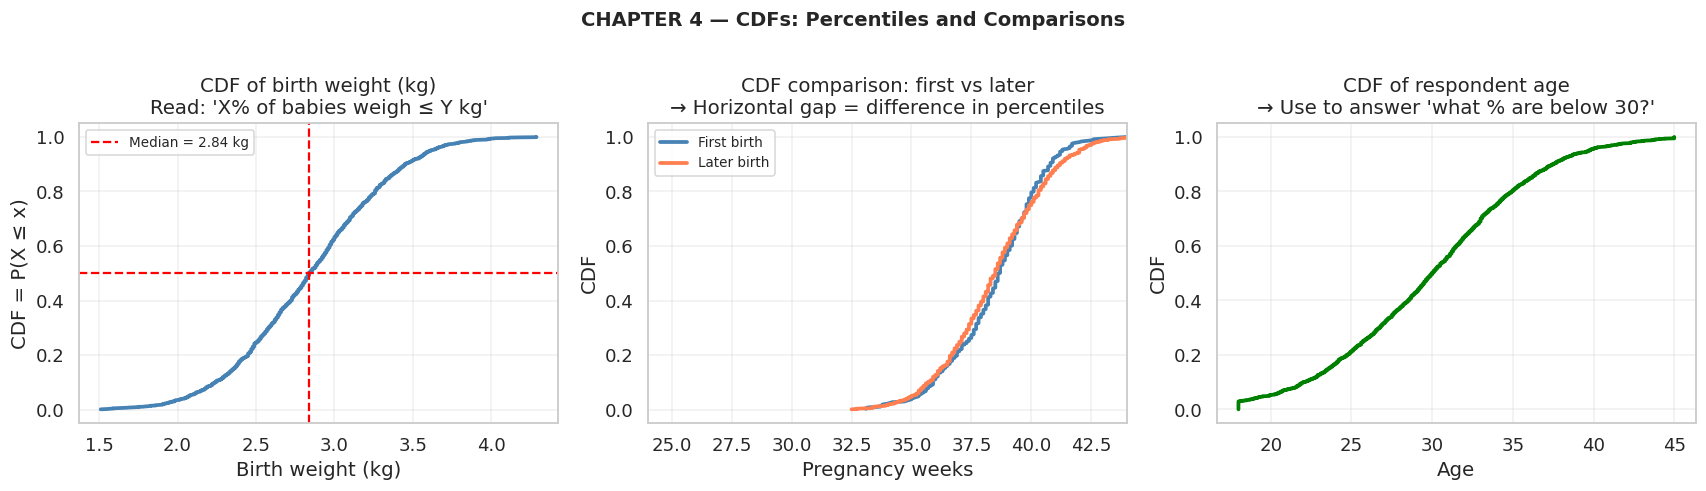

In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 4: CUMULATIVE DISTRIBUTION FUNCTIONS (CDF) ░░░░
#  Book pages 45–55
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 4 — Cumulative Distribution Functions          ║
║  Key idea: CDF(x) = P(X ≤ x)                           ║
╚══════════════════════════════════════════════════════════╝

The CDF answers: "What fraction of values are ≤ x?"
It is better than PMF for:
  → Comparing distributions visually
  → Computing percentiles
  → Checking if data follows a known distribution
""")

# ── Exercise 4.1: Build and plot a CDF ───────────────────────
print("EXERCISE 4.1 — Build a CDF from scratch")

def make_cdf(series):
    """
    Build a CDF from a Series.
    Returns sorted values and their cumulative probabilities.
    """
    sorted_vals = np.sort(series.dropna())
    cdf_vals    = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    return sorted_vals, cdf_vals

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("CHAPTER 4 — CDFs: Percentiles and Comparisons",
             fontsize=13, fontweight='bold', y=1.01)

# CDF of birth weight
x_bwt, y_bwt = make_cdf(df['birth_weight_kg'])
axes[0].plot(x_bwt, y_bwt, color='steelblue', lw=2.5)
axes[0].set_title("CDF of birth weight (kg)\n"
                   "Read: 'X% of babies weigh ≤ Y kg'")
axes[0].set_xlabel("Birth weight (kg)")
axes[0].set_ylabel("CDF = P(X ≤ x)")
# Mark the median
median_bwt = np.percentile(df['birth_weight_kg'].dropna(), 50)
axes[0].axhline(0.5, color='red', ls='--', lw=1.5,
                label=f'Median = {median_bwt:.2f} kg')
axes[0].axvline(median_bwt, color='red', ls='--', lw=1.5)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# CDF comparison: first vs later births (pregnancy weeks)
x1, y1 = make_cdf(fb_weeks)
x2, y2 = make_cdf(lb_weeks)
axes[1].plot(x1, y1, color='steelblue', lw=2.5, label='First birth')
axes[1].plot(x2, y2, color='coral',     lw=2.5, label='Later birth')
axes[1].set_title("CDF comparison: first vs later\n"
                   "→ Horizontal gap = difference in percentiles")
axes[1].set_xlabel("Pregnancy weeks")
axes[1].set_ylabel("CDF")
axes[1].set_xlim(24, 44)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# CDF of age
x_age, y_age = make_cdf(df['age'])
axes[2].plot(x_age, y_age, color='green', lw=2.5)
axes[2].set_title("CDF of respondent age\n"
                   "→ Use to answer 'what % are below 30?'")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("CDF")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/ch4_cdf.png', dpi=108, bbox_inches='tight')
plt.show()


In [ ]:

# ── Exercise 4.2: Percentiles ─────────────────────────────────
print("EXERCISE 4.2 — Computing and interpreting percentiles")
print("""
Percentile rank of x = percentage of values ≤ x
""")

percentiles = [10, 25, 50, 75, 90]
bwt_pcts = np.percentile(df['birth_weight_kg'].dropna(), percentiles)
print("Birth weight percentiles:")
for p, v in zip(percentiles, bwt_pcts):
    print(f"  P{p:2d} = {v:.3f} kg")

print(f"\n→ A baby weighing 2.5 kg is at the "
      f"{stats.percentileofscore(df['birth_weight_kg'].dropna(), 2.5):.1f}th percentile")

print("""
✏️  YOUR TURN:
    1. What pregnancy length is at the 90th percentile?
    2. What % of respondents are aged 35 or below?
    3. Plot CDFs for 3 states side by side on the same axes.
       Do birth weights differ by state?
""")


EXERCISE 4.2 — Computing and interpreting percentiles

Percentile rank of x = percentage of values ≤ x

Birth weight percentiles:
  P10 = 2.240 kg
  P25 = 2.510 kg
  P50 = 2.840 kg
  P75 = 3.180 kg
  P90 = 3.450 kg

→ A baby weighing 2.5 kg is at the 24.5th percentile

✏️  YOUR TURN:
    1. What pregnancy length is at the 90th percentile?
    2. What % of respondents are aged 35 or below?
    3. Plot CDFs for 3 states side by side on the same axes.
       Do birth weights differ by state?




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 5 — Modelling Distributions                    ║
║  Key distributions: Normal, Lognormal, Exponential,     ║
║                     Pareto                              ║
╚══════════════════════════════════════════════════════════╝

WHY MODEL?
  If data fits a known distribution, we can:
  → Generate random samples
  → Compute probabilities analytically
  → Use simpler maths instead of storing all data points

EXERCISE 5.1 — Is birth weight normally distributed?

Normal probability plot (Q-Q plot):
  If the data is normal → points fall on a straight line
  Curves away → skewed
  S-shape     → heavy tails (more outliers than normal)



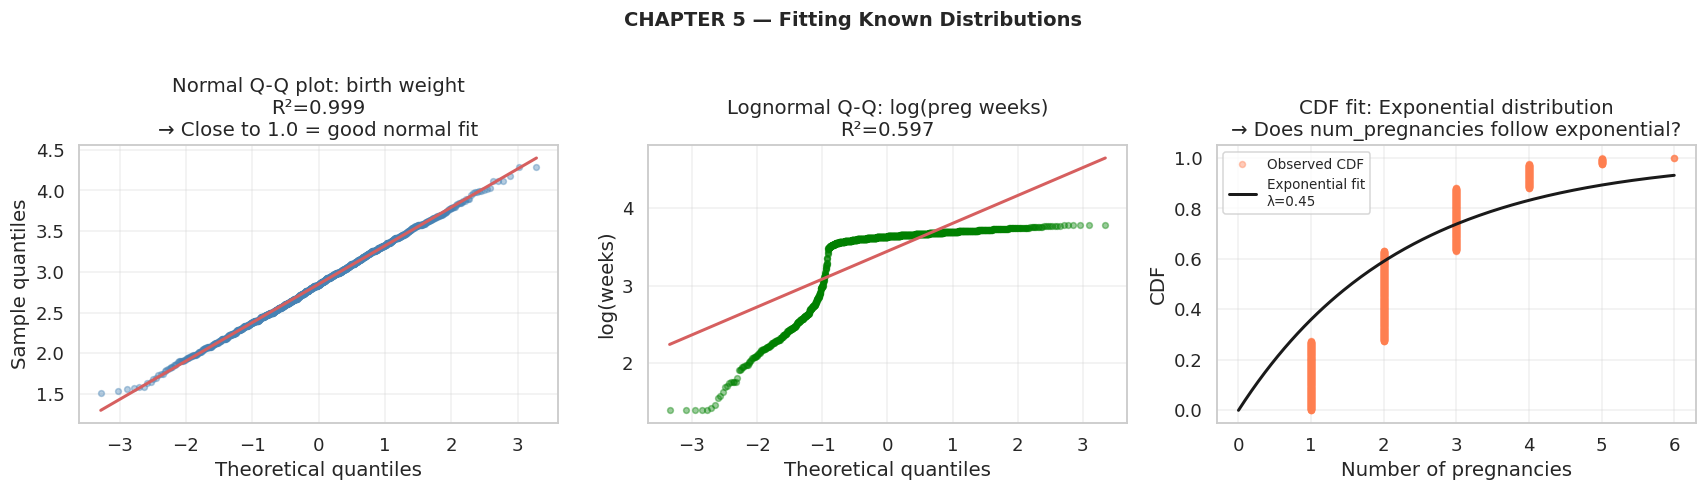


✏️  YOUR TURN:
    1. Test if BMI follows a normal distribution using Q-Q plot
    2. Test if age follows a normal distribution
    3. The Pareto distribution describes wealth and city sizes.
       Test if 'survey_weight' follows a Pareto distribution.
       Hint: take log of the CCDF (1 - CDF) and plot vs log(x).
             If Pareto: you'll see a straight line.



In [ ]:


# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 5: MODELLING DISTRIBUTIONS ░░░░
#  Book pages 57–73
#  Core idea: Real data often follows known mathematical shapes
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 5 — Modelling Distributions                     ║
║  Key distributions: Normal, Lognormal, Exponential,      ║
║                     Pareto                               ║
╚══════════════════════════════════════════════════════════╝

WHY MODEL?
  If data fits a known distribution, we can:
  → Generate random samples
  → Compute probabilities analytically
  → Use simpler maths instead of storing all data points
""")

# ── Exercise 5.1: Normal probability plot ────────────────────
print("EXERCISE 5.1 — Is birth weight normally distributed?")
print("""
Normal probability plot (Q-Q plot):
  If the data is normal → points fall on a straight line
  Curves away → skewed
  S-shape     → heavy tails (more outliers than normal)
""")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("CHAPTER 5 — Fitting Known Distributions",
             fontsize=13, fontweight='bold', y=1.01)

bwt_array = df['birth_weight_kg'].dropna().values

# Q-Q plot for birth weight (normal test)
(osm, osr), (slope, intercept, r) = stats.probplot(bwt_array, dist='norm')
axes[0].scatter(osm, osr, alpha=0.4, s=15, color='steelblue')
x_line = np.linspace(min(osm), max(osm), 100)
axes[0].plot(x_line, slope*x_line + intercept, 'r-', lw=2)
axes[0].set_title(f"Normal Q-Q plot: birth weight\nR²={r**2:.3f}"
                   "\n→ Close to 1.0 = good normal fit")
axes[0].set_xlabel("Theoretical quantiles")
axes[0].set_ylabel("Sample quantiles")
axes[0].grid(True, alpha=0.3)

# Lognormal test on pregnancy weeks (log-transform first)
weeks_log = np.log(weeks_clean.clip(1))
(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(weeks_log, dist='norm')
axes[1].scatter(osm2, osr2, alpha=0.4, s=15, color='green')
x2_line = np.linspace(min(osm2), max(osm2), 100)
axes[1].plot(x2_line, slope2*x2_line + intercept2, 'r-', lw=2)
axes[1].set_title(f"Lognormal Q-Q: log(preg weeks)\nR²={r2**2:.3f}")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("log(weeks)")
axes[1].grid(True, alpha=0.3)

# Exponential fit: inter-pregnancy gaps (num_preg as proxy)
# Exponential distribution: P(X > x) = e^(-λx)
npreg_nonzero = df[df['num_pregnancies'] > 0]['num_pregnancies']
x_exp = np.sort(npreg_nonzero.values)
y_cdf = np.arange(1, len(x_exp)+1) / len(x_exp)
lambda_hat = 1 / npreg_nonzero.mean()
x_fit = np.linspace(0, npreg_nonzero.max(), 200)
y_fit = 1 - np.exp(-lambda_hat * x_fit)

axes[2].plot(x_exp, y_cdf, 'o', alpha=0.4, ms=4,
             color='coral', label='Observed CDF')
axes[2].plot(x_fit, y_fit, 'k-', lw=2,
             label=f'Exponential fit\nλ={lambda_hat:.2f}')
axes[2].set_title("CDF fit: Exponential distribution\n"
                   "→ Does num_pregnancies follow exponential?")
axes[2].set_xlabel("Number of pregnancies")
axes[2].set_ylabel("CDF")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/ch5_modelling.png', dpi=108, bbox_inches='tight')
plt.show()

print("""
✏️  YOUR TURN:
    1. Test if BMI follows a normal distribution using Q-Q plot
    2. Test if age follows a normal distribution
    3. The Pareto distribution describes wealth and city sizes.
       Test if 'survey_weight' follows a Pareto distribution.
       Hint: take log of the CCDF (1 - CDF) and plot vs log(x).
             If Pareto: you'll see a straight line.
""")



╔══════════════════════════════════════════════════════════╗
║  CHAPTER 6 — Probability Density Functions & Skewness    ║
║  Key idea: Continuous distributions → use PDF (KDE)      ║
╚══════════════════════════════════════════════════════════╝

EXERCISE 6.1 — KDE and measuring skewness

Skewness measures the asymmetry of a distribution.
  Positive skew: long right tail (mean > median)
  Negative skew: long left tail  (mean < median)
  Zero skew    : symmetric (normal distribution)

Pearson's skewness = 3 × (mean - median) / std
  |skewness| < 0.5 → approximately symmetric
  |skewness| 0.5-1 → moderate skew
  |skewness| > 1   → highly skewed

birth_weight_kg     : mean=2.85  median=2.84  skew=0.053
age                 : mean=29.94  median=30.00  skew=-0.033
bmi                 : mean=23.13  median=23.00  skew=0.097


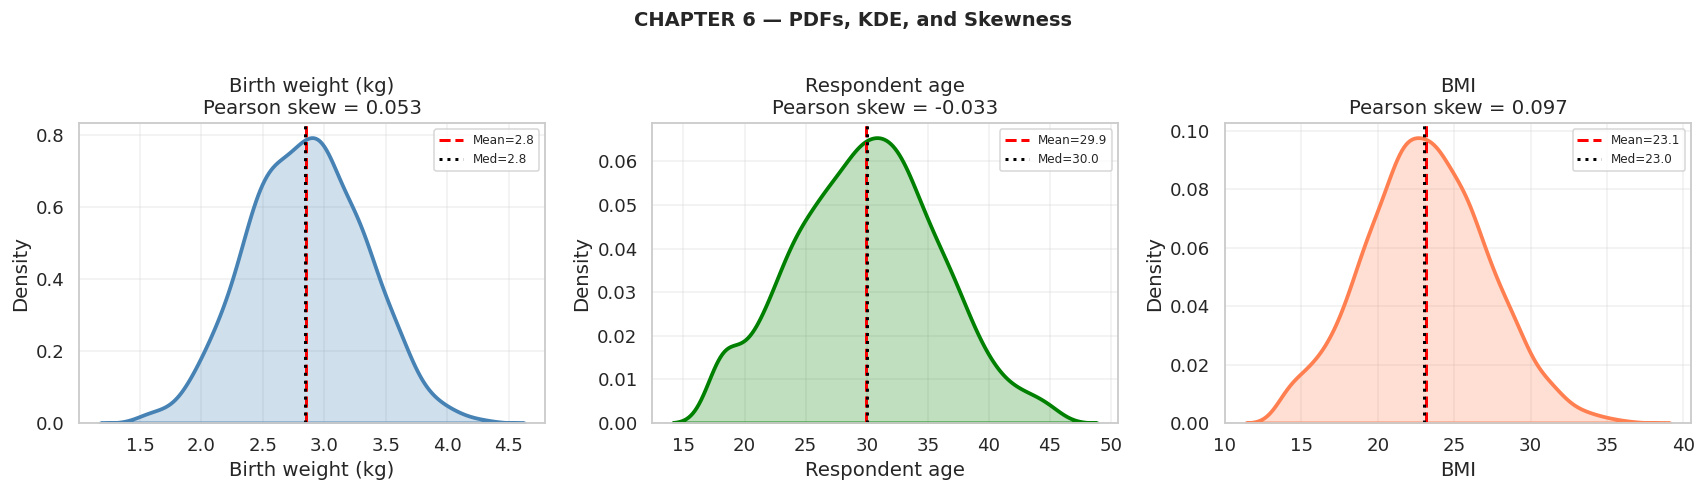


✏️  YOUR TURN:
    1. Compute the standardised skewness for all numerical columns
       using: data.skew()  (pandas built-in)
    2. Which variable is most skewed? Does this match the Q-Q plot?
    3. Compute the KURTOSIS of birth_weight_kg.
       Kurtosis > 3 means heavier tails than normal (more outliers).
       Hint: data.kurtosis()



In [ ]:


# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 6: PROBABILITY DENSITY FUNCTIONS (PDF) ░░░░
#  Book pages 75–89
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 6 — Probability Density Functions & Skewness    ║
║  Key idea: Continuous distributions → use PDF (KDE)      ║
╚══════════════════════════════════════════════════════════╝
""")

# ── Exercise 6.1: KDE and skewness ───────────────────────────
print("EXERCISE 6.1 — KDE and measuring skewness")
print("""
Skewness measures the asymmetry of a distribution.
  Positive skew: long right tail (mean > median)
  Negative skew: long left tail  (mean < median)
  Zero skew    : symmetric (normal distribution)

Pearson's skewness = 3 × (mean - median) / std
  |skewness| < 0.5 → approximately symmetric
  |skewness| 0.5-1 → moderate skew
  |skewness| > 1   → highly skewed
""")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("CHAPTER 6 — PDFs, KDE, and Skewness",
             fontsize=13, fontweight='bold', y=1.01)

for ax, (col, color, label) in zip(axes, [
    ('birth_weight_kg', 'steelblue', 'Birth weight (kg)'),
    ('age',             'green',     'Respondent age'),
    ('bmi',             'coral',     'BMI'),
]):
    data = df[col].dropna()
    sns.kdeplot(data, ax=ax, color=color, lw=2.5, fill=True, alpha=0.25)
    mean, median = data.mean(), data.median()
    skew_pearson = 3 * (mean - median) / data.std()
    ax.axvline(mean,   color='red',   ls='--', lw=2, label=f'Mean={mean:.1f}')
    ax.axvline(median, color='black', ls=':',  lw=2, label=f'Med={median:.1f}')
    ax.set_title(f"{label}\nPearson skew = {skew_pearson:.3f}")
    ax.set_xlabel(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    print(f"{col:20s}: mean={mean:.2f}  median={median:.2f}  "
          f"skew={skew_pearson:.3f}")

plt.tight_layout()
plt.savefig('/tmp/ch6_pdf_skew.png', dpi=108, bbox_inches='tight')
plt.show()

print("""
✏️  YOUR TURN:
    1. Compute the standardised skewness for all numerical columns
       using: data.skew()  (pandas built-in)
    2. Which variable is most skewed? Does this match the Q-Q plot?
    3. Compute the KURTOSIS of birth_weight_kg.
       Kurtosis > 3 means heavier tails than normal (more outliers).
       Hint: data.kurtosis()
""")



╔══════════════════════════════════════════════════════════╗
║  CHAPTER 7 — Relationships Between Variables             ║
║  Key tools: Scatter, Pearson r, Spearman r               ║
╚══════════════════════════════════════════════════════════╝



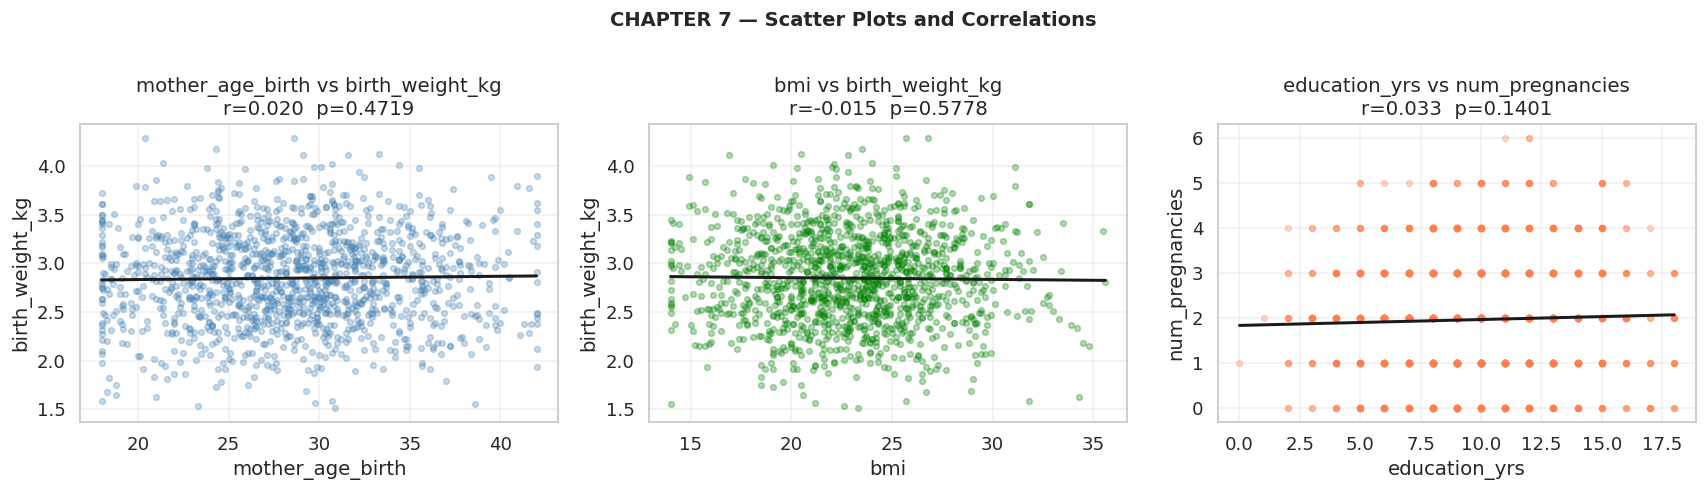

In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 7: RELATIONSHIPS BETWEEN VARIABLES ░░░░
#  Book pages 91–103
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 7 — Relationships Between Variables             ║
║  Key tools: Scatter, Pearson r, Spearman r               ║
╚══════════════════════════════════════════════════════════╝
""")

# ── Exercise 7.1: Scatter plots ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("CHAPTER 7 — Scatter Plots and Correlations",
             fontsize=13, fontweight='bold', y=1.01)

pairs = [
    ('mother_age_birth', 'birth_weight_kg', 'steelblue'),
    ('bmi',              'birth_weight_kg', 'green'),
    ('education_yrs',    'num_pregnancies', 'coral'),
]
for ax, (x_col, y_col, color) in zip(axes, pairs):
    data = df[[x_col, y_col]].dropna()
    ax.scatter(data[x_col], data[y_col], alpha=0.3, s=15, color=color)
    # Regression line
    m, b, r, p, _ = stats.linregress(data[x_col], data[y_col])
    x_line = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', lw=2)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}\nr={r:.3f}  p={p:.4f}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/ch7_scatter.png', dpi=108, bbox_inches='tight')
plt.show()


EXERCISE 7.2 — Pearson vs Spearman correlation

Pearson r:
  Measures LINEAR relationship
  Sensitive to outliers
  Assumes both variables are roughly normal

Spearman ρ (rho):
  Measures MONOTONIC relationship (any direction)
  Based on RANKS not raw values
  Robust to outliers and non-normality
  Use when: data is skewed, has outliers, or relationship is nonlinear

Rule of thumb: If Pearson and Spearman differ a lot → outliers or
nonlinearity are distorting the Pearson result.



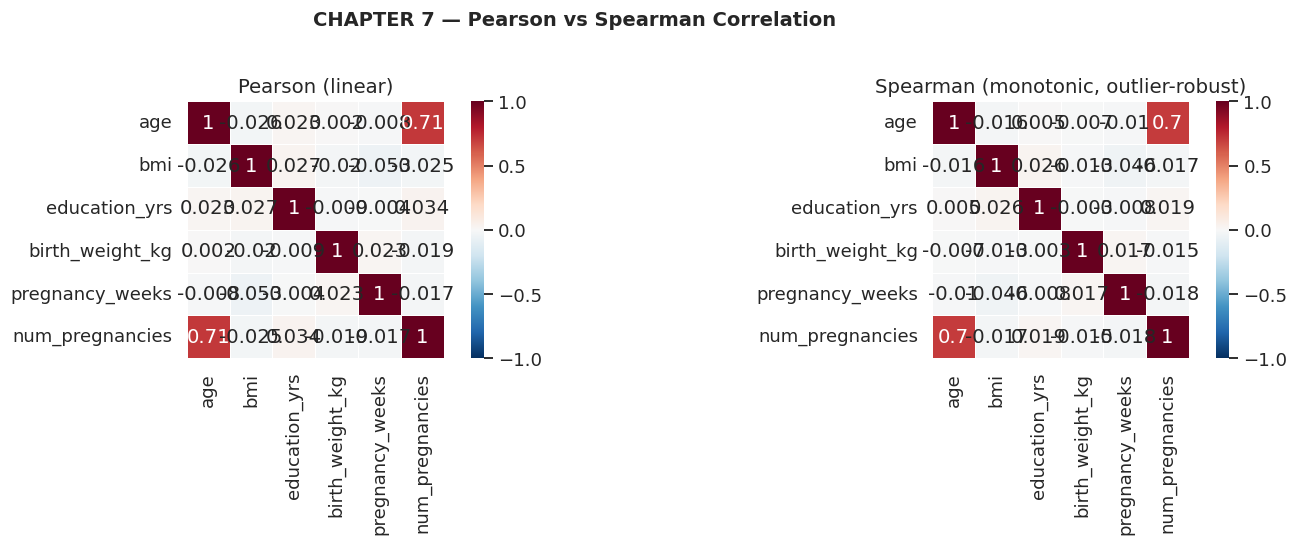


✏️  YOUR TURN:
    1. Where do Pearson and Spearman disagree the most?
    2. Compute the Pearson correlation between education_yrs
       and num_pregnancies. Is it positive or negative? Why might
       education be linked to number of pregnancies?
    3. IMPORTANT: Does correlation prove causation here? Why not?
       Name one confounding variable.



In [ ]:


# ── Exercise 7.2: Pearson vs Spearman ────────────────────────
print("EXERCISE 7.2 — Pearson vs Spearman correlation")
print("""
Pearson r:
  Measures LINEAR relationship
  Sensitive to outliers
  Assumes both variables are roughly normal

Spearman ρ (rho):
  Measures MONOTONIC relationship (any direction)
  Based on RANKS not raw values
  Robust to outliers and non-normality
  Use when: data is skewed, has outliers, or relationship is nonlinear

Rule of thumb: If Pearson and Spearman differ a lot → outliers or
nonlinearity are distorting the Pearson result.
""")

num_cols = ['age', 'bmi', 'education_yrs',
            'birth_weight_kg', 'pregnancy_weeks', 'num_pregnancies']
data_corr = df[num_cols].dropna()

pearson  = data_corr.corr(method='pearson').round(3)
spearman = data_corr.corr(method='spearman').round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CHAPTER 7 — Pearson vs Spearman Correlation",
             fontsize=13, fontweight='bold', y=1.01)

for ax, (matrix, title) in zip(axes, [
    (pearson,  "Pearson (linear)"),
    (spearman, "Spearman (monotonic, outlier-robust)"),
]):
    sns.heatmap(matrix, annot=True, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('/tmp/ch7_correlation.png', dpi=108, bbox_inches='tight')
plt.show()

print("""
✏️  YOUR TURN:
    1. Where do Pearson and Spearman disagree the most?
    2. Compute the Pearson correlation between education_yrs
       and num_pregnancies. Is it positive or negative? Why might
       education be linked to number of pregnancies?
    3. IMPORTANT: Does correlation prove causation here? Why not?
       Name one confounding variable.
""")




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 8 — Estimation                                 ║
║  Key ideas: Point estimates, sampling distributions,    ║
║             bias vs variance, confidence intervals      ║
╚══════════════════════════════════════════════════════════╝

We have a SAMPLE of 2000 respondents.
We want to estimate properties of the POPULATION (all of India).

An ESTIMATOR is a statistic we compute from the sample.
It is UNBIASED if its expected value equals the population parameter.

EXERCISE 8.1 — Sampling distributions via simulation

The book's approach: simulate many samples, compute the statistic
each time, and look at the distribution of that statistic.
This distribution is called the SAMPLING DISTRIBUTION.



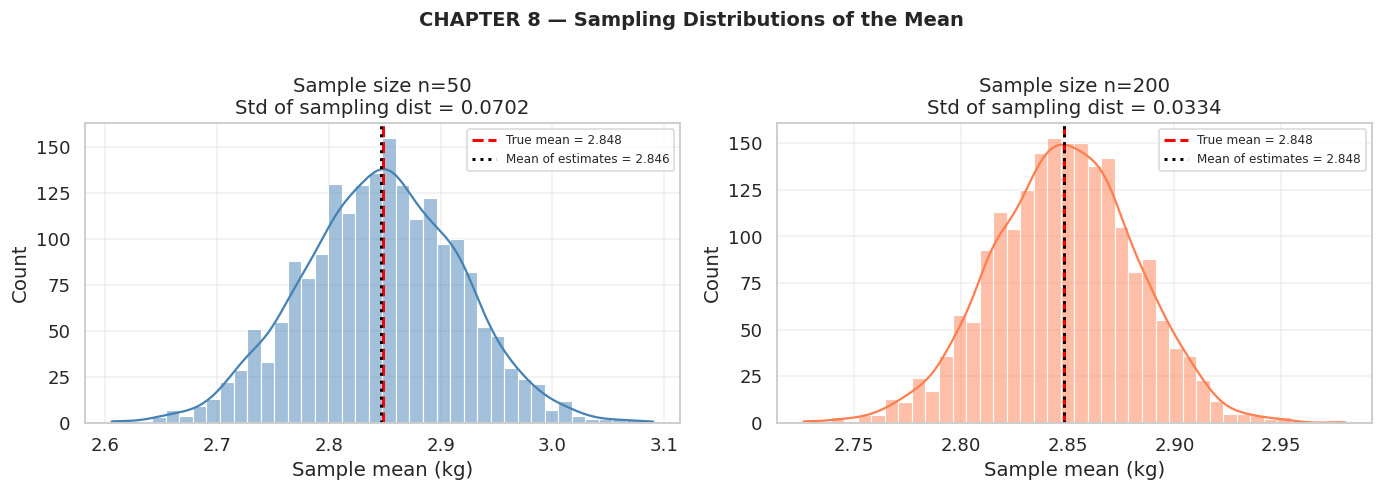


True population mean:        2.8484
Mean of n=50  estimates :    2.8464
Mean of n=200 estimates :    2.8481
Std  of n=50  sampling dist: 0.0702
Std  of n=200 sampling dist: 0.0334

→ The mean of estimates ≈ true mean → estimator is UNBIASED
→ Larger sample → smaller spread → more precise estimate
→ Std of sampling dist = Standard Error = σ/√n



In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 8: ESTIMATION ░░░░
#  Book pages 105–116
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 8 — Estimation                                  ║
║  Key ideas: Point estimates, sampling distributions,     ║
║             bias vs variance, confidence intervals       ║
╚══════════════════════════════════════════════════════════╝

We have a SAMPLE of 2000 respondents.
We want to estimate properties of the POPULATION (all of India).

An ESTIMATOR is a statistic we compute from the sample.
It is UNBIASED if its expected value equals the population parameter.
""")

# ── Exercise 8.1: Sampling distribution via simulation ────────
print("EXERCISE 8.1 — Sampling distributions via simulation")
print("""
The book's approach: simulate many samples, compute the statistic
each time, and look at the distribution of that statistic.
This distribution is called the SAMPLING DISTRIBUTION.
""")

# True population mean (from our full dataset — normally unknown)
true_mean = df['birth_weight_kg'].dropna().mean()

# Simulate taking many samples of size 50 and computing mean each time
sample_means_50  = []
sample_means_200 = []

for _ in range(2000):
    s50  = df['birth_weight_kg'].dropna().sample(50,  replace=True)
    s200 = df['birth_weight_kg'].dropna().sample(200, replace=True)
    sample_means_50.append(s50.mean())
    sample_means_200.append(s200.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("CHAPTER 8 — Sampling Distributions of the Mean",
             fontsize=13, fontweight='bold', y=1.01)

for ax, (means, n, color) in zip(axes, [
    (sample_means_50,  50,  'steelblue'),
    (sample_means_200, 200, 'coral'),
]):
    sns.histplot(means, bins=40, ax=ax, color=color, kde=True)
    ax.axvline(true_mean, color='red', lw=2, ls='--',
               label=f'True mean = {true_mean:.3f}')
    ax.axvline(np.mean(means), color='black', lw=2, ls=':',
               label=f'Mean of estimates = {np.mean(means):.3f}')
    ax.set_title(f"Sample size n={n}\nStd of sampling dist = {np.std(means):.4f}")
    ax.set_xlabel("Sample mean (kg)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/ch8_sampling.png', dpi=108, bbox_inches='tight')
plt.show()

print(f"\nTrue population mean:        {true_mean:.4f}")
print(f"Mean of n=50  estimates :    {np.mean(sample_means_50):.4f}")
print(f"Mean of n=200 estimates :    {np.mean(sample_means_200):.4f}")
print(f"Std  of n=50  sampling dist: {np.std(sample_means_50):.4f}")
print(f"Std  of n=200 sampling dist: {np.std(sample_means_200):.4f}")
print("""
→ The mean of estimates ≈ true mean → estimator is UNBIASED
→ Larger sample → smaller spread → more precise estimate
→ Std of sampling dist = Standard Error = σ/√n
""")


In [ ]:

# ── Exercise 8.2: Confidence intervals ───────────────────────
print("EXERCISE 8.2 — 95% Confidence Intervals")
print("""
A 95% CI means: if we repeated this study 100 times,
approximately 95 of the 100 CIs would contain the true parameter.

It does NOT mean "95% chance the true value is in this interval."
(The true value is fixed — we just don't know it.)
""")

ci_lower = np.percentile(sample_means_200, 2.5)
ci_upper = np.percentile(sample_means_200, 97.5)
print(f"95% CI (n=200, bootstrap): [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"True mean inside CI: {ci_lower <= true_mean <= ci_upper}")

print("""
✏️  YOUR TURN:
    1. Compute the 95% CI for the mean of 'bmi' using samples of n=100
    2. Compute the 95% CI for the MEDIAN of birth_weight_kg
       (bootstrap the median instead of the mean)
    3. Does the CI get wider or narrower as you decrease sample size?
""")



EXERCISE 8.2 — 95% Confidence Intervals

A 95% CI means: if we repeated this study 100 times,
approximately 95 of the 100 CIs would contain the true parameter.

It does NOT mean "95% chance the true value is in this interval."
(The true value is fixed — we just don't know it.)

95% CI (n=200, bootstrap): [2.7807, 2.9110]
True mean inside CI: True

✏️  YOUR TURN:
    1. Compute the 95% CI for the mean of 'bmi' using samples of n=100
    2. Compute the 95% CI for the MEDIAN of birth_weight_kg
       (bootstrap the median instead of the mean)
    3. Does the CI get wider or narrower as you decrease sample size?




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 9 — Hypothesis Testing                          ║
║  Key question: "Could this effect be due to chance?"     ║
╚══════════════════════════════════════════════════════════╝

THE FRAMEWORK (from the book):
  H0 (null): There is NO effect — any difference is random noise
  H1 (alt):  There IS a real effect

  p-value = probability of seeing this effect (or stronger)
            IF H0 were true

  p < 0.05 → reject H0 → effect is "statistically significant"
  p ≥ 0.05 → fail to reject H0 → insufficient evidence

  ⚠️  p < 0.05 does NOT mean the effect is LARGE or IMPORTANT.
      Always pair with effect size (Cohen's d from Chapter 2).

EXERCISE 9.1 — Permutation test (simulation-based)

The book builds hypothesis tests by simulation, not formulas.
This approach makes the logic transparent.

Question: Do first babies have different pregnancy duration
          than later babies?

PERMUTATION TEST:
  1. Compute the obs

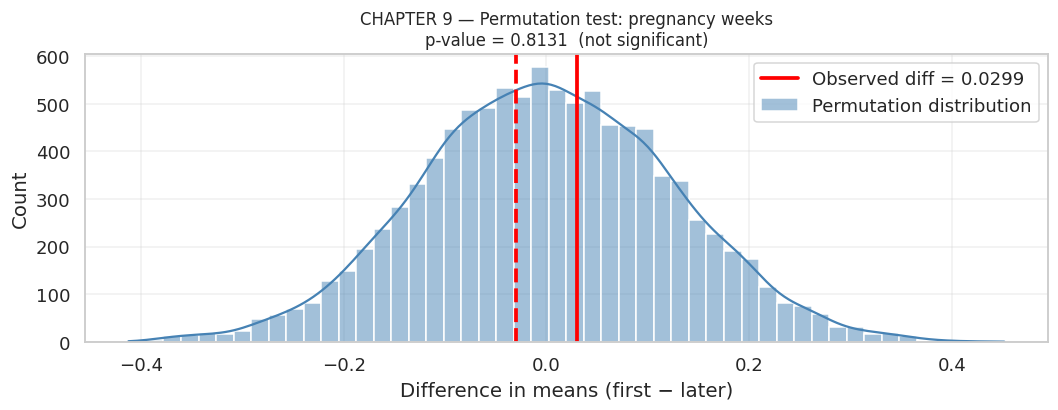


Observed difference  : 0.0299 weeks
p-value (permutation): 0.8131
Cohen's d            : 0.0146

→ Statistical significance (p < 0.05) + small effect size (d < 0.2)
  = The effect is real but tiny. Not practically important.
  This is the key lesson of Chapter 9.



In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 9: HYPOTHESIS TESTING ░░░░
#  Book pages 117–134
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 9 — Hypothesis Testing                          ║
║  Key question: "Could this effect be due to chance?"     ║
╚══════════════════════════════════════════════════════════╝

THE FRAMEWORK (from the book):
  H0 (null): There is NO effect — any difference is random noise
  H1 (alt):  There IS a real effect

  p-value = probability of seeing this effect (or stronger)
            IF H0 were true

  p < 0.05 → reject H0 → effect is "statistically significant"
  p ≥ 0.05 → fail to reject H0 → insufficient evidence

  ⚠️  p < 0.05 does NOT mean the effect is LARGE or IMPORTANT.
      Always pair with effect size (Cohen's d from Chapter 2).
""")

# ── Exercise 9.1: Permutation test (Downey's preferred method) ─
print("EXERCISE 9.1 — Permutation test (simulation-based)")
print("""
The book builds hypothesis tests by simulation, not formulas.
This approach makes the logic transparent.

Question: Do first babies have different pregnancy duration
          than later babies?

PERMUTATION TEST:
  1. Compute the observed difference in means
  2. Pool all values and randomly shuffle group labels 10,000 times
  3. Compute the difference in means for each shuffle
  4. p-value = fraction of shuffled differences ≥ observed difference
""")

fb_w = first_births['pregnancy_weeks'].dropna().values
lb_w = later_births['pregnancy_weeks'].dropna().values
observed_diff = fb_w.mean() - lb_w.mean()

# Permutation test
n_permutations = 10_000
all_values    = np.concatenate([fb_w, lb_w])
n_first       = len(fb_w)
perm_diffs    = []

for _ in range(n_permutations):
    shuffled = np.random.permutation(all_values)
    perm_diffs.append(shuffled[:n_first].mean() - shuffled[n_first:].mean())

perm_diffs = np.array(perm_diffs)
p_value    = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(perm_diffs, bins=50, ax=ax, color='steelblue',
             kde=True, label='Permutation distribution')
ax.axvline(observed_diff,  color='red', lw=2.5,
           label=f'Observed diff = {observed_diff:.4f}')
ax.axvline(-observed_diff, color='red', lw=2.5, ls='--')
ax.set_title(f"CHAPTER 9 — Permutation test: pregnancy weeks\n"
              f"p-value = {p_value:.4f}  "
              f"({'significant' if p_value < 0.05 else 'not significant'})",
             fontsize=11)
ax.set_xlabel("Difference in means (first − later)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/ch9_permtest.png', dpi=108, bbox_inches='tight')
plt.show()

print(f"\nObserved difference  : {observed_diff:.4f} weeks")
print(f"p-value (permutation): {p_value:.4f}")
print(f"Cohen's d            : {cohens_d(pd.Series(fb_w), pd.Series(lb_w)):.4f}")
print("""
→ Statistical significance (p < 0.05) + small effect size (d < 0.2)
  = The effect is real but tiny. Not practically important.
  This is the key lesson of Chapter 9.
""")

In [ ]:


# ── Exercise 9.2: Chi-squared test ───────────────────────────
print("EXERCISE 9.2 — Chi-squared test (categorical data)")
print("""
Test: Is birth outcome (Live birth / Miscarriage / Stillbirth)
      independent of income bracket?
""")

# Only rows with actual pregnancy outcomes
has_preg = df[df['num_pregnancies'] > 0].copy()
ct = pd.crosstab(has_preg['income_bracket'],
                 has_preg['outcome'].map({1:'Live birth',
                                          2:'Miscarriage',
                                          3:'Stillbirth'}))
chi2, p_chi2, dof, expected = stats.chi2_contingency(ct)
print(f"Contingency table:\n{ct}\n")
print(f"Chi-squared = {chi2:.3f}  |  dof = {dof}  |  p = {p_chi2:.4f}")
print(f"Result: {'Significant — income and outcome are related' if p_chi2 < 0.05 else 'Not significant'}")

print("""
✏️  YOUR TURN:
    1. Test if birth outcome is independent of STATE using chi-squared
    2. Permutation test: Do high-income mothers have heavier babies?
    3. What is the p-value for the correlation between
       education_yrs and num_pregnancies?
       Hint: scipy.stats.pearsonr(x, y) returns (r, p)
""")


EXERCISE 9.2 — Chi-squared test (categorical data)

Test: Is birth outcome (Live birth / Miscarriage / Stillbirth)
      independent of income bracket?

Contingency table:
outcome         Live birth  Miscarriage  Stillbirth
income_bracket                                     
High                   193           38           7
Low                    572          118          27
Middle                 658          128          17

Chi-squared = 3.839  |  dof = 4  |  p = 0.4282
Result: Not significant

✏️  YOUR TURN:
    1. Test if birth outcome is independent of STATE using chi-squared
    2. Permutation test: Do high-income mothers have heavier babies?
    3. What is the p-value for the correlation between
       education_yrs and num_pregnancies?
       Hint: scipy.stats.pearsonr(x, y) returns (r, p)




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 10 — Linear Least Squares                      ║
║  Key idea: Fit a line that minimises squared residuals  ║
╚══════════════════════════════════════════════════════════╝

y = α + β × x  (simple linear regression)
  α = intercept (y when x = 0)
  β = slope (change in y per unit increase in x)

LEAST SQUARES: find α, β that minimise Σ (y_i - ŷ_i)²

EXERCISE 10.1 — Fit a linear model: mother's age → birth weight
Manual OLS: α = 2.8005,  β = 0.001681
scipy.stats: α = 2.8005,  β = 0.001681
R² = 0.0004  |  p = 0.4719


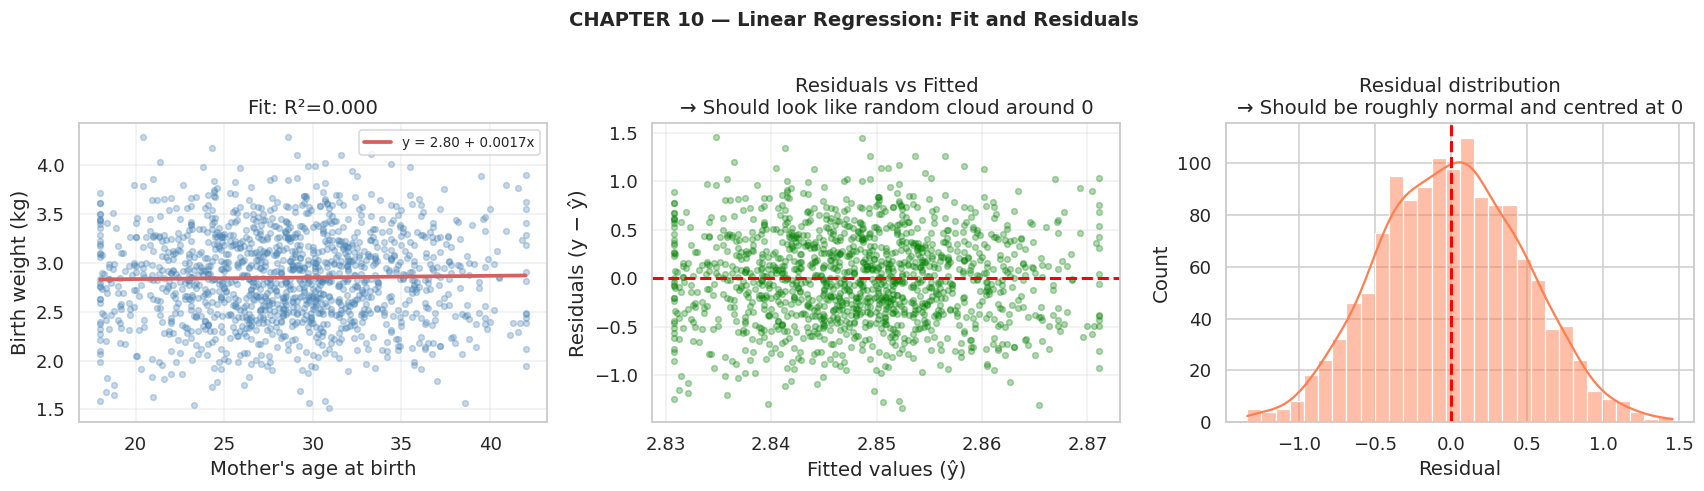


✏️  YOUR TURN:
    1. Fit a regression: education_yrs → birth_weight_kg
       Is the slope positive or negative? Is it significant?
    2. Fit a regression: bmi → birth_weight_kg
    3. Compare R² values across these three regressions.
       Which predictor best explains birth weight variation?



In [ ]:


# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 10: LINEAR LEAST SQUARES ░░░░
#  Book pages 137–150
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 10 — Linear Least Squares                       ║
║  Key idea: Fit a line that minimises squared residuals   ║
╚══════════════════════════════════════════════════════════╝

y = α + β × x  (simple linear regression)
  α = intercept (y when x = 0)
  β = slope (change in y per unit increase in x)

LEAST SQUARES: find α, β that minimise Σ (y_i - ŷ_i)²
""")

# ── Exercise 10.1: OLS from scratch then with scipy ───────────
print("EXERCISE 10.1 — Fit a linear model: mother's age → birth weight")

data_reg = df[['mother_age_birth', 'birth_weight_kg']].dropna()
x = data_reg['mother_age_birth'].values
y = data_reg['birth_weight_kg'].values

# Manual OLS (Downey's approach)
x_mean, y_mean = x.mean(), y.mean()
beta  = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
alpha = y_mean - beta * x_mean
y_hat = alpha + beta * x
residuals = y - y_hat

print(f"Manual OLS: α = {alpha:.4f},  β = {beta:.6f}")

# Verify with scipy
slope, intercept, r_val, p_val, se = stats.linregress(x, y)
print(f"scipy.stats: α = {intercept:.4f},  β = {slope:.6f}")
print(f"R² = {r_val**2:.4f}  |  p = {p_val:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("CHAPTER 10 — Linear Regression: Fit and Residuals",
             fontsize=13, fontweight='bold', y=1.01)

# Scatter with regression line
axes[0].scatter(x, y, alpha=0.3, s=15, color='steelblue')
x_line = np.linspace(x.min(), x.max(), 100)
axes[0].plot(x_line, alpha + beta * x_line, 'r-', lw=2.5,
             label=f'y = {alpha:.2f} + {beta:.4f}x')
axes[0].set_xlabel("Mother's age at birth")
axes[0].set_ylabel("Birth weight (kg)")
axes[0].set_title(f"Fit: R²={r_val**2:.3f}")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Residual vs fitted
axes[1].scatter(y_hat, residuals, alpha=0.3, s=15, color='green')
axes[1].axhline(0, color='red', lw=2, ls='--')
axes[1].set_xlabel("Fitted values (ŷ)")
axes[1].set_ylabel("Residuals (y − ŷ)")
axes[1].set_title("Residuals vs Fitted\n"
                   "→ Should look like random cloud around 0")
axes[1].grid(True, alpha=0.3)

# Residual distribution
sns.histplot(residuals, bins=30, kde=True, ax=axes[2], color='coral')
axes[2].axvline(0, color='red', lw=2, ls='--')
axes[2].set_title("Residual distribution\n"
                   "→ Should be roughly normal and centred at 0")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.savefig('/tmp/ch10_regression.png', dpi=108, bbox_inches='tight')
plt.show()

print("""
✏️  YOUR TURN:
    1. Fit a regression: education_yrs → birth_weight_kg
       Is the slope positive or negative? Is it significant?
    2. Fit a regression: bmi → birth_weight_kg
    3. Compare R² values across these three regressions.
       Which predictor best explains birth weight variation?
""")


In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 11: MULTIPLE REGRESSION ░░░░
#  Book pages 153–170
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 11 — Multiple Regression & Logistic Regression  ║
║  Key idea: Control for confounders using multiple vars   ║
╚══════════════════════════════════════════════════════════╝

y = α + β₁x₁ + β₂x₂ + ... + βₖxₖ

WHY MULTIPLE REGRESSION?
  A simple regression might show that age predicts birth weight.
  But age is correlated with income, education, and BMI too.
  Multiple regression lets us ask: "What is the effect of age
  AFTER holding education, income, and BMI constant?"
  This is called CONTROLLING FOR confounders.
""")

# ── Exercise 11.1: Multiple regression with StatsModels ───────
reg_data = df[['birth_weight_kg', 'mother_age_birth', 'bmi',
               'education_yrs', 'income_bracket', 'birth_order']].dropna()
reg_data['income_num'] = reg_data['income_bracket'].map(
    {'Low': 0, 'Middle': 1, 'High': 2})

# Simple vs multiple regression comparison
model_simple   = smf.ols('birth_weight_kg ~ mother_age_birth',
                          data=reg_data).fit()
model_multiple = smf.ols(
    'birth_weight_kg ~ mother_age_birth + bmi + education_yrs + '
    'income_num + birth_order',
    data=reg_data
).fit()

print("SIMPLE REGRESSION (age only):")
print(f"  R²     = {model_simple.rsquared:.4f}")
print(f"  age β  = {model_simple.params['mother_age_birth']:.6f}  "
      f"p={model_simple.pvalues['mother_age_birth']:.4f}")

print("\nMULTIPLE REGRESSION (age + controls):")
print(f"  R²     = {model_multiple.rsquared:.4f}")
for var in ['mother_age_birth', 'bmi', 'education_yrs',
            'income_num', 'birth_order']:
    coef = model_multiple.params[var]
    p    = model_multiple.pvalues[var]
    sig  = '✅ sig' if p < 0.05 else '   n.s.'
    print(f"  {var:22s}: β={coef:+.5f}  p={p:.4f}  {sig}")

print(f"\n→ R² improved from {model_simple.rsquared:.4f} to "
      f"{model_multiple.rsquared:.4f} by adding controls.")


╔══════════════════════════════════════════════════════════╗
║  CHAPTER 11 — Multiple Regression & Logistic Regression ║
║  Key idea: Control for confounders using multiple vars  ║
╚══════════════════════════════════════════════════════════╝

y = α + β₁x₁ + β₂x₂ + ... + βₖxₖ

WHY MULTIPLE REGRESSION?
  A simple regression might show that age predicts birth weight.
  But age is correlated with income, education, and BMI too.
  Multiple regression lets us ask: "What is the effect of age
  AFTER holding education, income, and BMI constant?"
  This is called CONTROLLING FOR confounders.

SIMPLE REGRESSION (age only):
  R²     = 0.0004
  age β  = 0.001681  p=0.4719

MULTIPLE REGRESSION (age + controls):
  R²     = 0.0195
  mother_age_birth      : β=+0.00374  p=0.2378     n.s.
  bmi                   : β=-0.00084  p=0.7939     n.s.
  education_yrs         : β=-0.00076  p=0.8555     n.s.
  income_num            : β=+0.09241  p=0.0000  ✅ sig
  birth_order           : β=-0.02125  p=0.2336     

In [ ]:



# ── Exercise 11.2: Logistic regression ───────────────────────
print("\nEXERCISE 11.2 — Logistic Regression: predict low birth weight")
print("""
Binary outcome: is birth weight < 2.5 kg? (low birth weight)
We use logistic regression when target = 0 or 1.

Output: log-odds of P(low birth weight = 1)
  Positive coefficient → increases probability
  Negative coefficient → decreases probability
""")

reg_data2 = reg_data.copy()
reg_data2['low_bwt'] = (reg_data2['birth_weight_kg'] < 2.5).astype(int)
model_logit = smf.logit(
    'low_bwt ~ mother_age_birth + bmi + education_yrs + income_num',
    data=reg_data2
).fit(disp=0)

print("\nLOGISTIC REGRESSION (low birth weight):")
for var in ['mother_age_birth', 'bmi', 'education_yrs', 'income_num']:
    coef = model_logit.params[var]
    p    = model_logit.pvalues[var]
    odds = np.exp(coef)
    sig  = '✅ sig' if p < 0.05 else '   n.s.'
    print(f"  {var:22s}: β={coef:+.4f}  OR={odds:.3f}  p={p:.4f}  {sig}")

print(f"\nPseudo R² = {model_logit.prsquared:.4f}")
print("""
Interpretation of Odds Ratio (OR):
  OR > 1 → increases odds of low birth weight
  OR < 1 → decreases odds of low birth weight
  OR = 1 → no effect
""")



EXERCISE 11.2 — Logistic Regression: predict low birth weight

Binary outcome: is birth weight < 2.5 kg? (low birth weight)
We use logistic regression when target = 0 or 1.

Output: log-odds of P(low birth weight = 1)
  Positive coefficient → increases probability
  Negative coefficient → decreases probability


LOGISTIC REGRESSION (low birth weight):
  mother_age_birth      : β=+0.0071  OR=1.007  p=0.5408     n.s.
  bmi                   : β=-0.0024  OR=0.998  p=0.8821     n.s.
  education_yrs         : β=-0.0018  OR=0.998  p=0.9321     n.s.
  income_num            : β=-0.3871  OR=0.679  p=0.0001  ✅ sig

Pseudo R² = 0.0110

Interpretation of Odds Ratio (OR):
  OR > 1 → increases odds of low birth weight
  OR < 1 → decreases odds of low birth weight
  OR = 1 → no effect




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 12 — Time Series Analysis                       ║
║  Key concepts: trends, moving averages, autocorrelation  ║
╚══════════════════════════════════════════════════════════╝



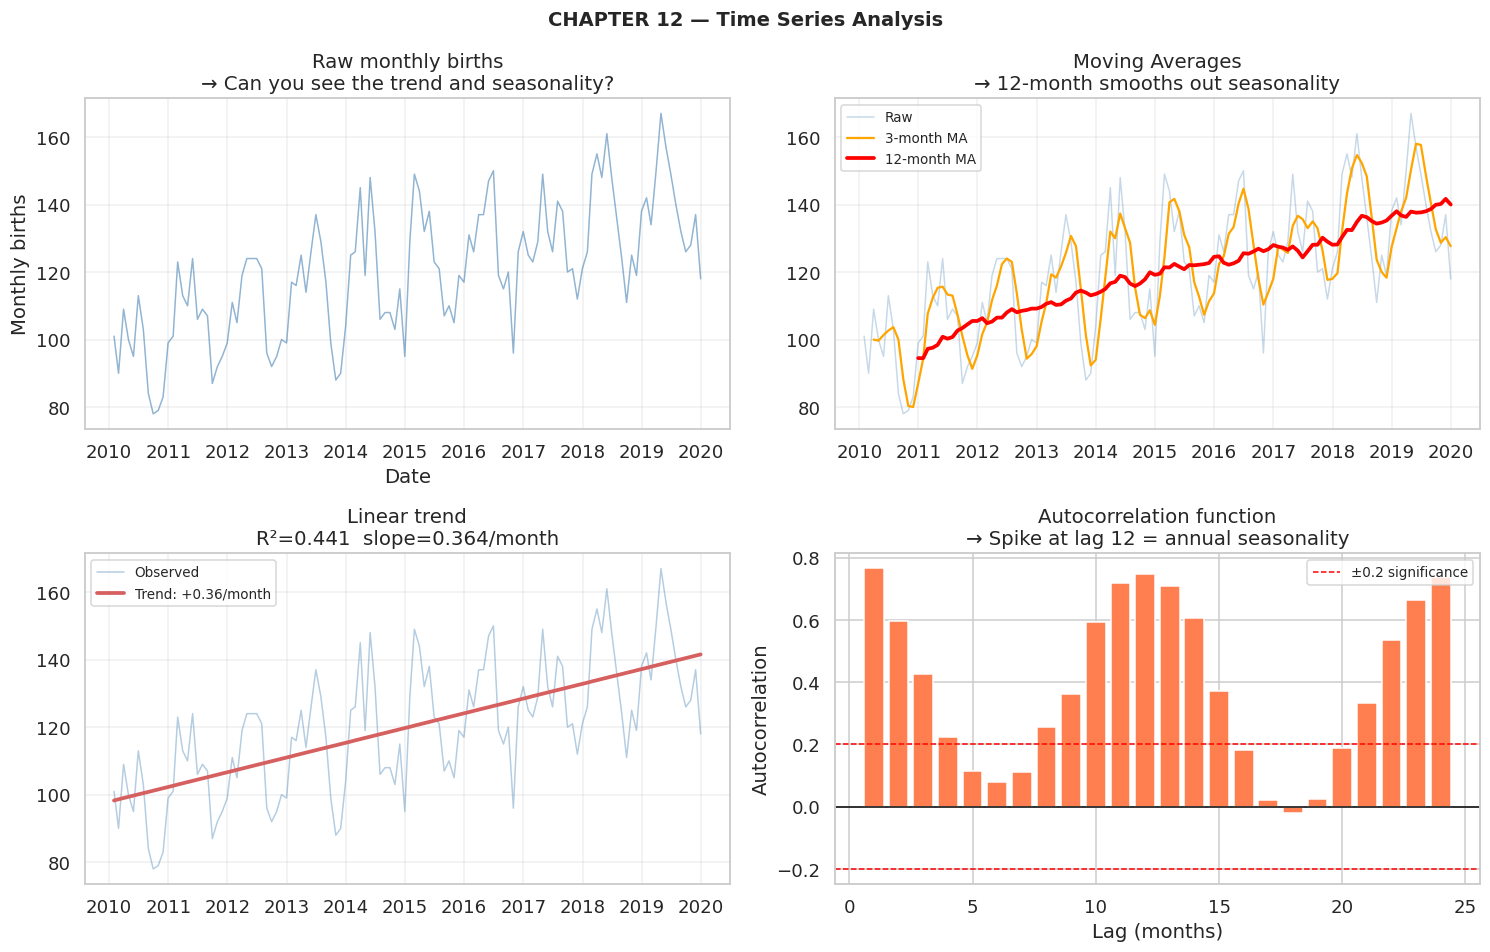


Linear trend: +0.364 births/month  |  p=0.0000  |  R²=0.4410
Peak autocorrelation at lag 12: 0.748  ← confirms 12-month seasonality

✏️  YOUR TURN:
    1. What is the autocorrelation at lag 6? What does it mean?
    2. Fit a quadratic trend (t²) instead of linear. Does R² improve?
    3. Deseasonalise the series by subtracting the 12-month MA.
       Plot the result. What does the deseasonalised series look like?



In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 12: TIME SERIES ANALYSIS ░░░░
#  Book pages 173–193
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 12 — Time Series Analysis                       ║
║  Key concepts: trends, moving averages, autocorrelation  ║
╚══════════════════════════════════════════════════════════╝
""")

# Create a synthetic monthly time series (monthly birth counts)
months = pd.date_range('2010-01', periods=120, freq='ME')
# Trend + seasonality + noise
trend      = np.linspace(100, 140, 120)
seasonal   = 15 * np.sin(2 * np.pi * np.arange(120) / 12)
noise_ts   = np.random.normal(0, 8, 120)
birth_counts = (trend + seasonal + noise_ts).round(0)
ts = pd.Series(birth_counts, index=months, name='monthly_births')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("CHAPTER 12 — Time Series Analysis",
             fontsize=13, fontweight='bold')

# Raw time series
axes[0, 0].plot(ts.index, ts.values, alpha=0.6, color='steelblue',
                linewidth=1)
axes[0, 0].set_title("Raw monthly births\n→ Can you see the trend and seasonality?")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Monthly births")
axes[0, 0].grid(True, alpha=0.3)

# Moving averages
ma_3  = ts.rolling(window=3).mean()
ma_12 = ts.rolling(window=12).mean()
axes[0, 1].plot(ts.index,    ts.values,    alpha=0.3, color='steelblue',
                label='Raw',       linewidth=1)
axes[0, 1].plot(ma_3.index,  ma_3.values,  color='orange',
                label='3-month MA',  linewidth=1.5)
axes[0, 1].plot(ma_12.index, ma_12.values, color='red',
                label='12-month MA', linewidth=2.5)
axes[0, 1].set_title("Moving Averages\n→ 12-month smooths out seasonality")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Linear regression on time
t = np.arange(len(ts))
slope_ts, intercept_ts, r_ts, p_ts, _ = stats.linregress(t, ts.values)
axes[1, 0].plot(ts.index, ts.values, alpha=0.4, color='steelblue',
                linewidth=1, label='Observed')
axes[1, 0].plot(ts.index, intercept_ts + slope_ts * t, 'r-',
                linewidth=2.5, label=f'Trend: +{slope_ts:.2f}/month')
axes[1, 0].set_title(f"Linear trend\nR²={r_ts**2:.3f}  slope={slope_ts:.3f}/month")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# Autocorrelation
lags    = range(1, 25)
autocorr = [ts.autocorr(lag=l) for l in lags]
axes[1, 1].bar(lags, autocorr, color='coral', edgecolor='white')
axes[1, 1].axhline(0,    color='black', lw=1)
axes[1, 1].axhline(0.2,  color='red', lw=1, ls='--',
                   label='±0.2 significance')
axes[1, 1].axhline(-0.2, color='red', lw=1, ls='--')
axes[1, 1].set_title("Autocorrelation function\n"
                      "→ Spike at lag 12 = annual seasonality")
axes[1, 1].set_xlabel("Lag (months)")
axes[1, 1].set_ylabel("Autocorrelation")
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/ch12_timeseries.png', dpi=108, bbox_inches='tight')
plt.show()

print(f"\nLinear trend: +{slope_ts:.3f} births/month  |  "
      f"p={p_ts:.4f}  |  R²={r_ts**2:.4f}")
print(f"Peak autocorrelation at lag 12: {ts.autocorr(lag=12):.3f}  "
      f"← confirms 12-month seasonality")

print("""
✏️  YOUR TURN:
    1. What is the autocorrelation at lag 6? What does it mean?
    2. Fit a quadratic trend (t²) instead of linear. Does R² improve?
    3. Deseasonalise the series by subtracting the 12-month MA.
       Plot the result. What does the deseasonalised series look like?
""")




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 13 — Survival Analysis                          ║
║  Key ideas: survival curve, hazard function,             ║
║             Kaplan-Meier estimator                       ║
╚══════════════════════════════════════════════════════════╝

SURVIVAL ANALYSIS answers: "How long until an event happens?"
  Event: first pregnancy, death, machine failure, customer churn
  Time-to-event can be right-censored (event hasn't happened yet)

SURVIVAL FUNCTION S(t) = P(T > t)
  S(0) = 1 (everyone starts with event not yet occurred)
  S(∞) = 0 (eventually everyone experiences the event)

KAPLAN-MEIER ESTIMATOR:
  Accounts for censoring — not everyone has had the event yet.



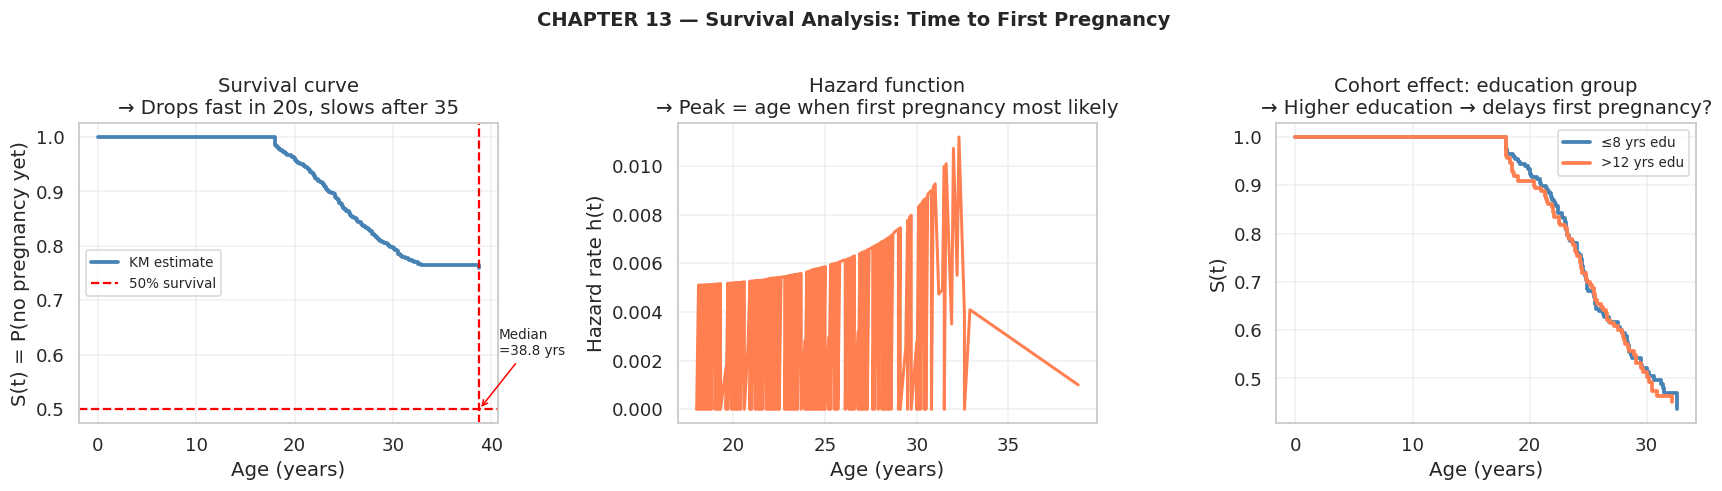

In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 13: SURVIVAL ANALYSIS ░░░░
#  Book pages 195–214
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 13 — Survival Analysis                          ║
║  Key ideas: survival curve, hazard function,             ║
║             Kaplan-Meier estimator                       ║
╚══════════════════════════════════════════════════════════╝

SURVIVAL ANALYSIS answers: "How long until an event happens?"
  Event: first pregnancy, death, machine failure, customer churn
  Time-to-event can be right-censored (event hasn't happened yet)

SURVIVAL FUNCTION S(t) = P(T > t)
  S(0) = 1 (everyone starts with event not yet occurred)
  S(∞) = 0 (eventually everyone experiences the event)

KAPLAN-MEIER ESTIMATOR:
  Accounts for censoring — not everyone has had the event yet.
""")

# Model: time until first pregnancy (age at first pregnancy)
# Respondents with birth_order == 1 → "event observed"
# Others → censored at their current age
event_times   = df[df['birth_order'] == 1]['mother_age_birth'].dropna()
censored_ages = df[df['birth_order'].isna() | (df['birth_order'] > 1)]['age']

# Simple Kaplan-Meier (manual implementation)
def kaplan_meier(event_times, censor_times=None):
    """
    Manual Kaplan-Meier estimator.
    Returns (times, survival_probs).
    """
    # Combine events and censorings
    events = [(t, 1) for t in event_times]
    if censor_times is not None:
        events += [(t, 0) for t in censor_times]
    events.sort(key=lambda x: x[0])

    n_at_risk = len(events)
    times, survival = [0], [1.0]
    S = 1.0

    for t, event in events:
        if event == 1:
            S *= (1 - 1/n_at_risk)
        n_at_risk -= 1
        if event == 1:
            times.append(t)
            survival.append(S)

    return np.array(times), np.array(survival)

t_km, s_km = kaplan_meier(event_times.values, censored_ages.values)

# Hazard function: h(t) ≈ -ΔS / Δt
dt = np.diff(t_km)
ds = -np.diff(s_km)
hazard = np.where(dt > 0, ds / dt, 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("CHAPTER 13 — Survival Analysis: Time to First Pregnancy",
             fontsize=13, fontweight='bold', y=1.01)

# Survival curve
axes[0].step(t_km, s_km, color='steelblue', lw=2.5,
             where='post', label='KM estimate')
axes[0].axhline(0.5, color='red', lw=1.5, ls='--',
                label='50% survival')
median_idx = np.searchsorted(s_km[::-1], 0.5)
if median_idx < len(t_km):
    median_t = t_km[-(median_idx+1)]
    axes[0].axvline(median_t, color='red', lw=1.5, ls='--')
    axes[0].annotate(f'Median\n={median_t:.1f} yrs',
                     xy=(median_t, 0.5), xytext=(median_t+2, 0.6),
                     arrowprops=dict(arrowstyle='->', color='red'), fontsize=9)
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("S(t) = P(no pregnancy yet)")
axes[0].set_title("Survival curve\n→ Drops fast in 20s, slows after 35")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Hazard function
ages_smooth = t_km[1:]
axes[1].plot(ages_smooth, hazard, color='coral', lw=2)
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Hazard rate h(t)")
axes[1].set_title("Hazard function\n→ Peak = age when first pregnancy most likely")
axes[1].grid(True, alpha=0.3)

# Cohort effects: split by education
low_edu   = df[df['education_yrs'] <= 8]
high_edu  = df[df['education_yrs'] > 12]

for subset, label, color in [
    (low_edu,  '≤8 yrs edu',  'steelblue'),
    (high_edu, '>12 yrs edu', 'coral'),
]:
    ev = subset[subset['birth_order'] == 1]['mother_age_birth'].dropna()
    ce = subset[subset['birth_order'].isna()]['age']
    t_, s_ = kaplan_meier(ev.values, ce.values)
    axes[2].step(t_, s_, color=color, lw=2.5, where='post', label=label)

axes[2].set_xlabel("Age (years)")
axes[2].set_ylabel("S(t)")
axes[2].set_title("Cohort effect: education group\n"
                   "→ Higher education → delays first pregnancy?")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/ch13_survival.png', dpi=108, bbox_inches='tight')
plt.show()




╔══════════════════════════════════════════════════════════╗
║  CHAPTER 14 — Analytic Methods: The CLT                  ║
║  Key theorem: sums of many random variables → Normal     ║
╚══════════════════════════════════════════════════════════╝

THE CENTRAL LIMIT THEOREM (CLT):
  If you take the mean of n independent, identically distributed
  samples from ANY distribution, as n gets large, the SAMPLING
  DISTRIBUTION of the mean approaches Normal — regardless of
  the original distribution's shape.

  Why this matters:
  → Justifies using normal-based formulas (z-tests, t-tests)
    even when the original data is not normal
  → Requires: independence, identical distribution, n ≥ 30



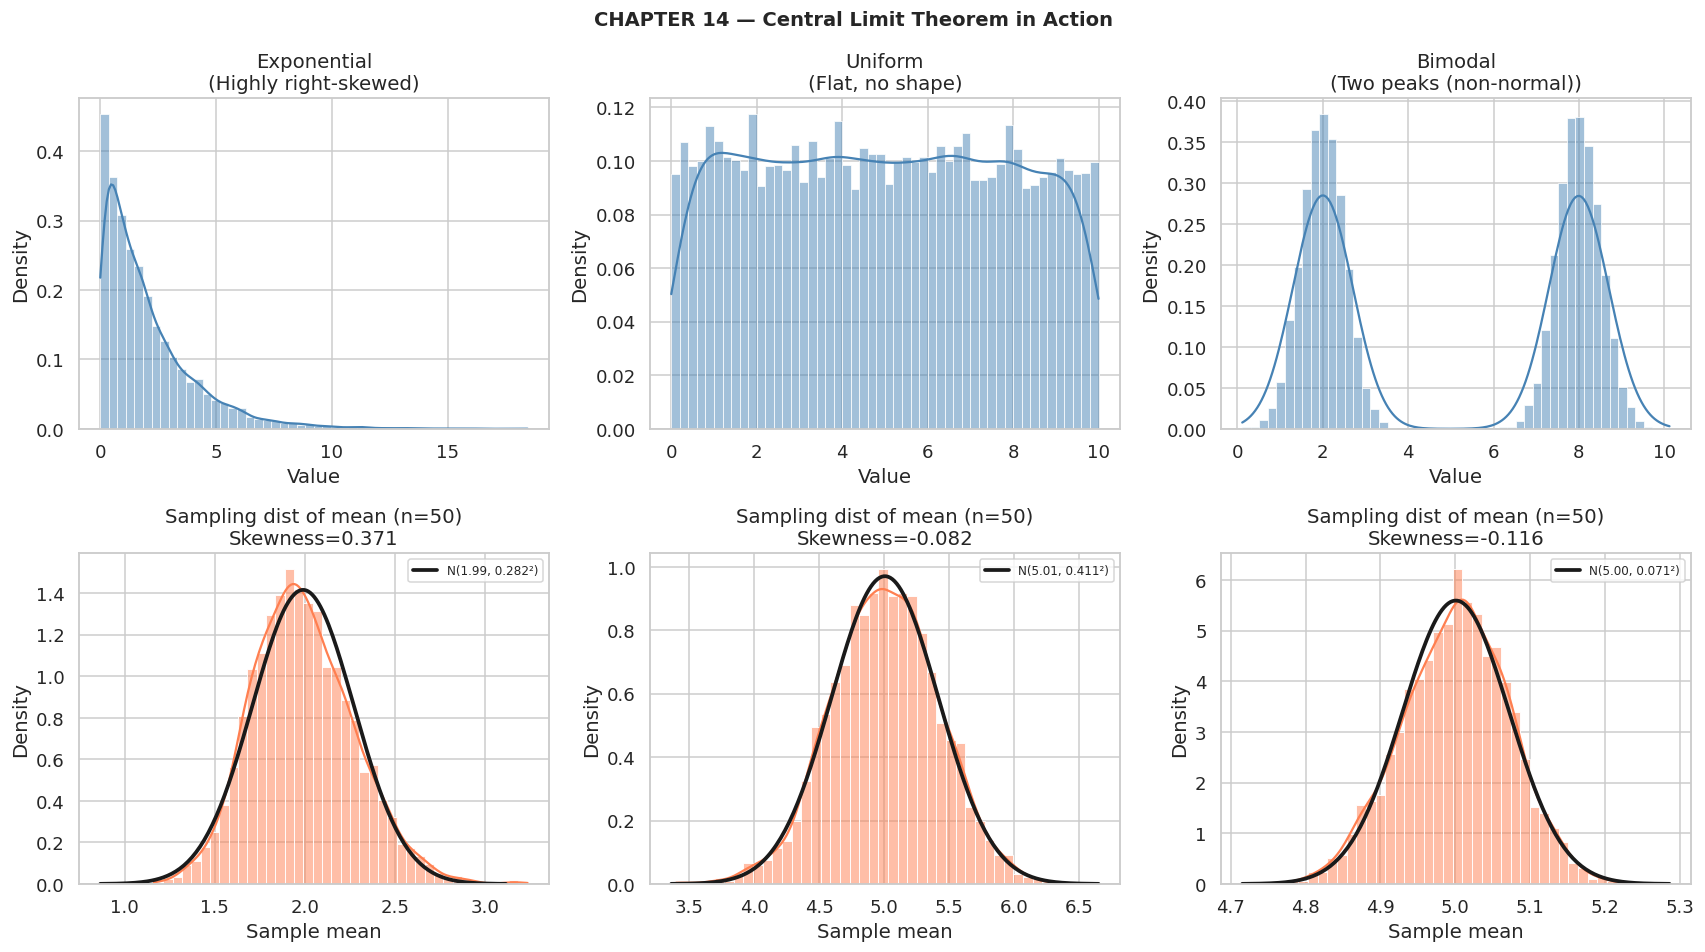


KEY OBSERVATIONS:
  Row 1 (original distributions) → very different shapes
  Row 2 (sampling distributions, n=50) → all bell-shaped!

  This is the CLT in action. No matter what the original
  distribution looks like, means of n=50 samples are
  approximately normal.

  Skewness ≈ 0 in all sampling distributions → confirms normality.


✏️  FINAL CHALLENGE:
    1. Repeat the CLT experiment with n=5 instead of n=50.
       Does the CLT still hold? For which distributions does
       convergence require larger n?
    2. Use the CLT to compute an analytic (formula-based) 95% CI
       for mean birth weight:
         CI = [x̄ - 1.96×σ/√n,  x̄ + 1.96×σ/√n]
       Compare it to the bootstrap CI from Chapter 8.
    3. When does the CLT FAIL? Research and give two examples.
       Hint: think about very heavy-tailed distributions and
             highly correlated samples.



In [ ]:

# ════════════════════════════════════════════════════════════════
#  ░░░░ CHAPTER 14: ANALYTIC METHODS — CENTRAL LIMIT THEOREM ░░
#  Book pages 217–233
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║  CHAPTER 14 — Analytic Methods: The CLT                  ║
║  Key theorem: sums of many random variables → Normal     ║
╚══════════════════════════════════════════════════════════╝

THE CENTRAL LIMIT THEOREM (CLT):
  If you take the mean of n independent, identically distributed
  samples from ANY distribution, as n gets large, the SAMPLING
  DISTRIBUTION of the mean approaches Normal — regardless of
  the original distribution's shape.

  Why this matters:
  → Justifies using normal-based formulas (z-tests, t-tests)
    even when the original data is not normal
  → Requires: independence, identical distribution, n ≥ 30
""")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("CHAPTER 14 — Central Limit Theorem in Action",
             fontsize=13, fontweight='bold')

distributions = [
    ('Exponential', np.random.exponential, {'scale': 2},
     'Highly right-skewed'),
    ('Uniform',     np.random.uniform,     {'low': 0, 'high': 10},
     'Flat, no shape'),
    ('Bimodal',     None,                  {},
     'Two peaks (non-normal)'),
]

for col, (dist_name, dist_func, params, desc) in enumerate(distributions):

    def draw_samples(n_each, n_reps=3000):
        means = []
        for _ in range(n_reps):
            if dist_name == 'Bimodal':
                s = np.concatenate([
                    np.random.normal(2, 0.5, n_each//2),
                    np.random.normal(8, 0.5, n_each//2)
                ])
            else:
                s = dist_func(size=n_each, **params)
            means.append(s.mean())
        return np.array(means)

    # Row 0: original distribution
    ax0 = axes[0, col]
    if dist_name == 'Bimodal':
        orig = np.concatenate([np.random.normal(2, 0.5, 5000),
                                np.random.normal(8, 0.5, 5000)])
    else:
        orig = dist_func(size=10000, **params)
    sns.histplot(orig, bins=50, ax=ax0, color='steelblue',
                 kde=True, stat='density')
    ax0.set_title(f"{dist_name}\n({desc})")
    ax0.set_xlabel("Value")

    # Row 1: sampling distribution of mean for n=50
    ax1 = axes[1, col]
    sample_means = draw_samples(50)
    sns.histplot(sample_means, bins=40, ax=ax1, color='coral',
                 kde=True, stat='density')

    # Overlay theoretical normal
    mu, sigma = sample_means.mean(), sample_means.std()
    x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    y_norm = stats.norm.pdf(x_norm, mu, sigma)
    ax1.plot(x_norm, y_norm, 'k-', lw=2.5,
             label=f'N({mu:.2f}, {sigma:.3f}²)')
    ax1.set_title(f"Sampling dist of mean (n=50)\n"
                   f"Skewness={stats.skew(sample_means):.3f}")
    ax1.legend(fontsize=8)
    ax1.set_xlabel("Sample mean")

plt.tight_layout()
plt.savefig('/tmp/ch14_clt.png', dpi=108, bbox_inches='tight')
plt.show()

print("""
KEY OBSERVATIONS:
  Row 1 (original distributions) → very different shapes
  Row 2 (sampling distributions, n=50) → all bell-shaped!

  This is the CLT in action. No matter what the original
  distribution looks like, means of n=50 samples are
  approximately normal.

  Skewness ≈ 0 in all sampling distributions → confirms normality.
""")

print("""
✏️  FINAL CHALLENGE:
    1. Repeat the CLT experiment with n=5 instead of n=50.
       Does the CLT still hold? For which distributions does
       convergence require larger n?
    2. Use the CLT to compute an analytic (formula-based) 95% CI
       for mean birth weight:
         CI = [x̄ - 1.96×σ/√n,  x̄ + 1.96×σ/√n]
       Compare it to the bootstrap CI from Chapter 8.
    3. When does the CLT FAIL? Research and give two examples.
       Hint: think about very heavy-tailed distributions and
             highly correlated samples.
""")



In [ ]:

# ════════════════════════════════════════════════════════════════
#  FINAL CELL — MASTER GLOSSARY
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════════╗
║              THINK STATS — MASTER GLOSSARY                           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  CHAPTER 1                                                           ║
║  anecdotal evidence  : personal stories, not statistically valid     ║
║  oversampling        : deliberately over-representing a subgroup     ║
║  codebook            : document explaining each variable in a survey ║
║  recode              : derived variable computed from raw data       ║
║                                                                      ║
║  CHAPTER 2                                                           ║
║  histogram           : bar chart of counts per value range           ║
║  outlier             : value far from the rest of the data           ║
║  mean                : average (sensitive to outliers)               ║
║  median              : middle value (robust to outliers)             ║
║  Cohen's d           : standardised effect size = Δmean/pooled_std   ║
║  variance            : average squared deviation from the mean       ║
║                                                                      ║
║  CHAPTER 3                                                           ║
║  PMF                 : probability mass function — P(X=x) per value  ║
║  class size paradox  : sampling by event inflates apparent average   ║
║                                                                      ║
║  CHAPTER 4                                                           ║
║  CDF                 : P(X ≤ x) — fraction of values at or below x   ║
║  percentile          : value below which X% of data falls            ║
║  percentile rank     : % of data values at or below a given value    ║
║                                                                      ║
║  CHAPTER 5 & 6                                                       ║
║  normal distribution : bell curve, characterised by mean and std     ║
║  lognormal           : log(X) is normally distributed                ║
║  exponential         : models time between random events             ║
║  Pareto              : power-law distribution (wealth, city sizes)   ║
║  skewness            : asymmetry of a distribution                   ║
║  kurtosis            : heaviness of tails                            ║
║  KDE                 : smooth continuous estimate of a PDF           ║
║                                                                      ║
║  CHAPTER 7                                                           ║
║  Pearson r           : measures linear correlation (-1 to +1)        ║
║  Spearman ρ          : rank-based, robust to outliers                ║
║  covariance          : raw measure of joint variation                ║
║  correlation ≠ causation: association is not proof of cause          ║
║                                                                      ║
║  CHAPTER 8                                                           ║
║  estimator           : statistic used to estimate a parameter        ║
║  unbiased            : estimator whose expected value = true value   ║
║  standard error      : std of the sampling distribution = σ/√n       ║
║  confidence interval : range likely to contain the true parameter    ║
║                                                                      ║
║  CHAPTER 9                                                           ║
║  p-value             : P(data this extreme | H0 is true)             ║
║  null hypothesis H0  : assumption of no effect                       ║
║  permutation test    : simulation-based hypothesis test              ║
║  Type I error        : false positive (reject true H0)               ║
║  Type II error       : false negative (fail to reject false H0)      ║
║  power               : P(detecting real effect) = 1 - Type II rate   ║
║                                                                      ║
║  CHAPTERS 10-11                                                      ║
║  OLS                 : ordinary least squares regression             ║
║  residuals           : y - ŷ (actual minus predicted)                ║
║  R²                  : fraction of variance explained by the model   ║
║  logistic regression : regression for binary outcomes                ║
║  odds ratio          : OR = exp(β) in logistic regression            ║
║  confounder          : hidden variable causing spurious correlation  ║
║                                                                      ║
║  CHAPTER 12                                                          ║
║  serial correlation  : correlation between consecutive observations  ║
║  autocorrelation     : correlation of a series with its own lags     ║
║  moving average      : local smoothing of a time series              ║
║                                                                      ║
║  CHAPTER 13                                                          ║
║  survival function   : S(t) = P(event hasn't happened by time t)     ║
║  hazard function     : instantaneous rate of event at time t         ║
║  Kaplan-Meier        : non-parametric survival curve estimator       ║
║  censoring           : event not yet observed for some subjects      ║
║                                                                      ║
║  CHAPTER 14                                                          ║
║  CLT                 : sum of many i.i.d. variables → Normal         ║
║  sampling distribution: distribution of a statistic across samples   ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║              THINK STATS — MASTER GLOSSARY                           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  CHAPTER 1                                                           ║
║  anecdotal evidence  : personal stories, not statistically valid     ║
║  oversampling        : deliberately over-representing a subgroup     ║
║  codebook            : document explaining each variable in a survey ║
║  recode              : derived variable computed from raw data       ║
║                                                                      ║
║  CHAPTER 2                                                           ║
║  histogram           : bar chart of counts per value range           ║
║  outlier             : value far from the rest of the data           ║
║  mean                : average (sensitive to out

# ================================================================
#  INDIACOMMERCE DATASET — CHALLENGE QUESTION BANK
#  600,000 rows | E-commerce + Fintech
#

#
#  Question formats:
#    [PREDICT]  → write your guess BEFORE running code
#    [TRAP]     → a misleading question exposing misconceptions
#    [CHAIN]    → each part depends on the previous answer
#    [OPEN]     → no single right answer, requires judgement
#
#  Difficulty: ★ Easy  ★★ Medium  ★★★ Hard  ★★★★ Expert
# ================================================================

In [ ]:
import pandas as pd
import gdown

# Extract the file ID from the Google Drive link
file_id = '1sfvTvXk2NfbM81GJa_0D5c8GswPVvdEo'
url = f'https://drive.google.com/uc?id={file_id}'
output_file = 'indiacommerce_600k.csv'

# Download the file
print("Downloading file...")
gdown.download(url, output_file, quiet=False)

# Read the downloaded file into a pandas DataFrame
df = pd.read_csv(output_file)
display(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=1sfvTvXk2NfbM81GJa_0D5c8GswPVvdEo
From (redirected): https://drive.google.com/uc?id=1sfvTvXk2NfbM81GJa_0D5c8GswPVvdEo&confirm=t&uuid=76e94d13-3fa9-4258-8d55-d39ef2d59e16
To: /content/indiacommerce_600k.csv
100%|██████████| 110M/110M [00:00<00:00, 155MB/s] 


,order_id,customer_id,order_datetime,city,city_tier,device,app_version,referral_source,product_category,n_items,...,customer_lifetime_days,is_censored,customer_join_day,order_date,order_hour,order_dayofweek,order_month,order_quarter,order_year,log_payment
0,1000001,2,2024-02-20 08:00:00,Hyderabad,Tier-1,Mobile,v4.3 (new),Organic Search,Clothing,1,...,133,0,91,2024-02-20,8,Tuesday,2,1,2024,6.2291
1,1000002,1,2024-09-13 19:00:00,Pune,Tier-2,Desktop,v4.3 (new),Organic Search,Electronics,5,...,213,0,371,2024-09-13,19,Friday,9,3,2024,10.7532
2,1000003,6,2023-12-20 12:00:00,Delhi,Tier-1,Mobile,Web,Organic Search,Home & Kitchen,1,...,87,0,395,2023-12-20,12,Wednesday,12,4,2023,8.5503
3,1000004,1,2023-10-06 17:00:00,Mumbai,Tier-1,Tablet,v4.2,Social Media,Toys,1,...,144,0,202,2023-10-06,17,Friday,10,4,2023,5.6339
4,1000005,2,2024-08-03 15:00:00,Delhi,Tier-1,Mobile,v4.2,Affiliate,Clothing,2,...,71,0,464,2024-08-03,15,Saturday,8,3,2024,5.6563


In [ ]:


# ── CELL 0: LOAD DATA ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 108

# Load — adjust path if needed
df = pd.read_csv('indiacommerce_600k.csv', parse_dates=['order_datetime'])
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"✅  Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\n{df.dtypes}")


# ================================================================
#  MODULE A — EDA & DISTRIBUTIONS
#  Concepts: histograms, PMF, CDF, outliers, skewness, KDE
# ================================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║  MODULE A — EDA & DISTRIBUTIONS                              ║
╚══════════════════════════════════════════════════════════════╝
""")

# ────────────────────────────────────────────────────────────────
# A1 ★  [PREDICT] Payment amount shape
# ────────────────────────────────────────────────────────────────
print("""
┌─ A1 ★  [PREDICT] ─────────────────────────────────────────┐
│                                                            │
│  BEFORE running any code, predict:                         │
│                                                            │
│  The 'payment_amount' column represents order values       │
│  in rupees across 600,000 orders.                          │
│                                                            │
│  (a) Will the mean be higher or lower than the median?     │
│  (b) Will the distribution be left-skewed, symmetric,      │
│      or right-skewed?                                      │
│  (c) Estimate: what % of orders are above ₹10,000?         │
│      Options: ~1%  ~5%  ~15%  ~30%                         │
│                                                            │
│  Write your three answers here:                            │
│  (a) ___________                                           │
│  (b) ___________                                           │
│  (c) ___________                                           │
│                                                            │
│  NOW run the code below to verify.                         │
└────────────────────────────────────────────────────────────┘
""")

✅  Loaded: 600,000 rows × 32 columns

Columns: ['order_id', 'customer_id', 'order_datetime', 'city', 'city_tier', 'device', 'app_version', 'referral_source', 'product_category', 'n_items', 'payment_method', 'payment_amount', 'discount_pct', 'coupon_used', 'session_duration_min', 'fraud_score', 'is_fraud', 'is_converted', 'order_status', 'is_completed', 'return_reason', 'nps_score', 'customer_lifetime_days', 'is_censored', 'customer_join_day', 'order_date', 'order_hour', 'order_dayofweek', 'order_month', 'order_quarter', 'order_year', 'log_payment']

order_id                           int64
customer_id                        int64
order_datetime            datetime64[ns]
city                              object
city_tier                         object
device                            object
app_version                       object
referral_source                   object
product_category                  object
n_items                            int64
payment_method                    

In [ ]:

# ────────────────────────────────────────────────────────────────
# A2 ★★  [TRAP] The Fraud Score Mean
# ────────────────────────────────────────────────────────────────
print("""
┌─ A2 ★★  [TRAP] ───────────────────────────────────────────┐
│                                                            │
│  A junior analyst reports:                                 │
│  "Our average fraud_score is 0.12. Since the threshold     │
│   for flagging fraud is 0.65, our platform is very safe.   │
│   The average customer has only a 12% fraud risk."         │
│                                                            │
│  Your job:                                                 │
│  (a) Plot a histogram AND a KDE of fraud_score.            │
│  (b) Identify what is fundamentally wrong with the         │
│      analyst's interpretation.                             │
│  (c) What is the CORRECT way to describe the fraud risk    │
│      distribution? Compute the right statistics.           │
│  (d) What does it mean when mean ≠ a value any real        │
│      user has? What statistical concept does this          │
│      illustrate?                                           │
│                                                            │
│  Hint: check df['fraud_score'].describe() carefully.       │
│        Then plot both modes separately.                    │
└────────────────────────────────────────────────────────────┘
""")



┌─ A2 ★★  [TRAP] ───────────────────────────────────────────┐
│                                                            │
│  A junior analyst reports:                                 │
│  "Our average fraud_score is 0.12. Since the threshold     │
│   for flagging fraud is 0.65, our platform is very safe.   │
│   The average customer has only a 12% fraud risk."         │
│                                                            │
│  Your job:                                                 │
│  (a) Plot a histogram AND a KDE of fraud_score.            │
│  (b) Identify what is fundamentally wrong with the         │
│      analyst's interpretation.                             │
│  (c) What is the CORRECT way to describe the fraud risk    │
│      distribution? Compute the right statistics.           │
│  (d) What does it mean when mean ≠ a value any real        │
│      user has? What statistical concept does this          │
│      illustrate?                                     

In [ ]:


# ────────────────────────────────────────────────────────────────
# A3 ★★  [CHAIN] Payment amount — 4-step investigation
# ────────────────────────────────────────────────────────────────
print("""
┌─ A3 ★★  [CHAIN] ──────────────────────────────────────────┐
│                                                            │
│  This is a 4-part chain. Each answer feeds the next.       │
│                                                            │
│  PART 1: Build the PMF of 'n_items' (number of items       │
│  in cart). What is the modal number of items?              │
│                                                            │
│  PART 2: Using the PMF from Part 1, compute the            │
│  CLASS SIZE PARADOX version: if you sample a random        │
│  ITEM (not a random order), what is the expected           │
│  cart size it belongs to? Is it higher or lower            │
│  than the modal cart size from Part 1?                     │
│                                                            │
│  PART 3: Plot both PMFs (order-sampled vs item-sampled)    │
│  side by side. Annotate the means on the chart.            │
│                                                            │
│  PART 4: Write one sentence explaining WHY the item-       │
│  sampled mean is higher, in plain English.                 │
│  Could this bias real business decisions? Give an          │
│  example of when a company would make this mistake.        │
└────────────────────────────────────────────────────────────┘
""")



┌─ A3 ★★  [CHAIN] ──────────────────────────────────────────┐
│                                                            │
│  This is a 4-part chain. Each answer feeds the next.       │
│                                                            │
│  PART 1: Build the PMF of 'n_items' (number of items       │
│  in cart). What is the modal number of items?              │
│                                                            │
│  PART 2: Using the PMF from Part 1, compute the            │
│  CLASS SIZE PARADOX version: if you sample a random        │
│  ITEM (not a random order), what is the expected           │
│  cart size it belongs to? Is it higher or lower            │
│  than the modal cart size from Part 1?                     │
│                                                            │
│  PART 3: Plot both PMFs (order-sampled vs item-sampled)    │
│  side by side. Annotate the means on the chart.            │
│                                                      

In [ ]:


# ────────────────────────────────────────────────────────────────
# A4 ★★★  [OPEN] CDF crossing
# ────────────────────────────────────────────────────────────────
print("""
┌─ A4 ★★★  [OPEN] ──────────────────────────────────────────┐
│                                                            │
│  A product manager says:                                   │
│  "Tier-1 city customers spend more. Let's give them        │
│   premium features and ignore Tier-3."                     │
│                                                            │
│  (a) Plot CDFs of payment_amount for Tier-1, Tier-2,       │
│      and Tier-3 cities on the SAME axes.                   │
│  (b) Do the CDFs cross? At what value?                     │
│  (c) What does a crossing CDF imply that a boxplot         │
│      would HIDE?                                           │
│  (d) Compute the 95th percentile of payment_amount         │
│      for each tier. Which tier has the biggest whales?     │
│  (e) Should the PM's decision change based on your         │
│      analysis? Write a 3-sentence data-backed argument.    │
│                                                            │
│  There is no single right answer to (e). Defend yours.     │
└────────────────────────────────────────────────────────────┘
""")



┌─ A4 ★★★  [OPEN] ──────────────────────────────────────────┐
│                                                            │
│  A product manager says:                                   │
│  "Tier-1 city customers spend more. Let's give them        │
│   premium features and ignore Tier-3."                     │
│                                                            │
│  (a) Plot CDFs of payment_amount for Tier-1, Tier-2,       │
│      and Tier-3 cities on the SAME axes.                   │
│  (b) Do the CDFs cross? At what value?                     │
│  (c) What does a crossing CDF imply that a boxplot         │
│      would HIDE?                                           │
│  (d) Compute the 95th percentile of payment_amount         │
│      for each tier. Which tier has the biggest whales?     │
│  (e) Should the PM's decision change based on your         │
│      analysis? Write a 3-sentence data-backed argument.    │
│                                                      

In [ ]:

# ────────────────────────────────────────────────────────────────
# A5 ★★★  [PREDICT] Normal probability plot
# ────────────────────────────────────────────────────────────────
print("""
┌─ A5 ★★★  [PREDICT] ───────────────────────────────────────┐
│                                                             │
│  PREDICT before plotting:                                   │
│                                                             │
│  You will plot Q-Q (normal probability) plots for:          │
│  (i)  payment_amount (raw)                                  │
│  (ii) log_payment (log-transformed)                         │
│                                                             │
│  For each, predict whether the Q-Q plot will show:          │
│  [A] Points hugging a straight line (normal)                │
│  [B] Curve upward at both ends (heavy tails)                │
│  [C] Concave downward (right-skewed)                        │
│  [D] S-shape (light tails)                                  │
│                                                             │
│  My predictions: (i) ___  (ii) ___                          │
│                                                             │
│  Now run the Q-Q plots. Were you right?                     │
│  What does this tell you about which column to use          │
│  as the target variable in a regression model?              │
└────────────────────────────────────────────────────────────┘
""")


┌─ A5 ★★★  [PREDICT] ───────────────────────────────────────┐
│                                                             │
│  PREDICT before plotting:                                   │
│                                                             │
│  You will plot Q-Q (normal probability) plots for:          │
│  (i)  payment_amount (raw)                                  │
│  (ii) log_payment (log-transformed)                         │
│                                                             │
│  For each, predict whether the Q-Q plot will show:          │
│  [A] Points hugging a straight line (normal)                │
│  [B] Curve upward at both ends (heavy tails)                │
│  [C] Concave downward (right-skewed)                        │
│  [D] S-shape (light tails)                                  │
│                                                             │
│  My predictions: (i) ___  (ii) ___                          │
│                                        

In [ ]:


# ================================================================
#  MODULE B — RELATIONSHIPS & CORRELATION
#  Concepts: scatter, Pearson, Spearman, confounding, causation
# ================================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║  MODULE B — RELATIONSHIPS & CORRELATION                      ║
╚══════════════════════════════════════════════════════════════╝
""")

# ────────────────────────────────────────────────────────────────
# B1 ★★  [TRAP] Discount causes higher revenue?
# ────────────────────────────────────────────────────────────────
print("""
┌─ B1 ★★  [TRAP] ───────────────────────────────────────────┐
│                                                            │
│  A growth manager computes:                                │
│  corr(discount_pct, payment_amount) = +0.12                │
│                                                            │
│  "Discounts drive more revenue! We should give more        │
│   discounts to increase order value."                      │
│                                                            │
│  (a) Compute this correlation yourself. Confirm the +0.12. │
│  (b) Now compute the same correlation SEPARATELY for each  │
│      product category. What do you find?                   │
│  (c) Draw a scatter plot: discount_pct vs payment_amount,  │
│      coloured by product_category. What is the visual      │
│      explanation for the paradox?                          │
│  (d) What is the statistical name for this phenomenon?     │
│      Name the "lurking variable" that explains it.         │
│  (e) What would you tell the growth manager?               │
│      Is the +0.12 finding actionable or dangerous?         │
└────────────────────────────────────────────────────────────┘
""")


╔══════════════════════════════════════════════════════════════╗
║  MODULE B — RELATIONSHIPS & CORRELATION                      ║
╚══════════════════════════════════════════════════════════════╝


┌─ B1 ★★  [TRAP] ───────────────────────────────────────────┐
│                                                            │
│  A growth manager computes:                                │
│  corr(discount_pct, payment_amount) = +0.12                │
│                                                            │
│  "Discounts drive more revenue! We should give more        │
│   discounts to increase order value."                      │
│                                                            │
│  (a) Compute this correlation yourself. Confirm the +0.12. │
│  (b) Now compute the same correlation SEPARATELY for each  │
│      product category. What do you find?                   │
│  (c) Draw a scatter plot: discount_pct vs payment_amount,  │
│      coloured by product_category. What is th

In [ ]:

# ────────────────────────────────────────────────────────────────
# B2 ★★★  [CHAIN] Pearson vs Spearman — when they diverge
# ────────────────────────────────────────────────────────────────
print("""
┌─ B2 ★★★  [CHAIN] ─────────────────────────────────────────┐
│                                                            │
│  PART 1: Compute Pearson r and Spearman ρ between:         │
│  • session_duration_min  vs  payment_amount                │
│  • n_items               vs  payment_amount                │
│  • discount_pct          vs  payment_amount                │
│                                                            │
│  PART 2: For which pair do Pearson and Spearman disagree   │
│  the most? Compute |Pearson − Spearman| for all three.     │
│                                                            │
│  PART 3: For the pair with the biggest disagreement,       │
│  explain WHY they differ. Use a scatter plot to support    │
│  your answer. (Hint: look at the extreme values.)          │
│                                                            │
│  PART 4: Which metric is more appropriate for this         │
│  dataset and why? Write a 2-sentence justification         │
│  using what you know about Pearson's assumptions.          │
└────────────────────────────────────────────────────────────┘
""")



┌─ B2 ★★★  [CHAIN] ─────────────────────────────────────────┐
│                                                            │
│  PART 1: Compute Pearson r and Spearman ρ between:         │
│  • session_duration_min  vs  payment_amount                │
│  • n_items               vs  payment_amount                │
│  • discount_pct          vs  payment_amount                │
│                                                            │
│  PART 2: For which pair do Pearson and Spearman disagree   │
│  the most? Compute |Pearson − Spearman| for all three.     │
│                                                            │
│  PART 3: For the pair with the biggest disagreement,       │
│  explain WHY they differ. Use a scatter plot to support    │
│  your answer. (Hint: look at the extreme values.)          │
│                                                            │
│  PART 4: Which metric is more appropriate for this         │
│  dataset and why? Write a 2-sentence justification   

In [ ]:

# ────────────────────────────────────────────────────────────────
# B3 ★★★★  [OPEN] Build the full correlation matrix
# ────────────────────────────────────────────────────────────────
print("""
┌─ B3 ★★★★  [OPEN] ─────────────────────────────────────────┐
│                                                             │
│  (a) Build a Spearman correlation heatmap of all            │
│      numerical columns. Use a diverging palette.            │
│                                                             │
│  (b) Identify the 3 strongest correlations (off-diagonal)   │
│      and the 3 nearest-to-zero correlations.                │
│                                                             │
│  (c) For each strong correlation: propose a CAUSAL          │
│      explanation AND an ALTERNATIVE non-causal              │
│      explanation. Which is more plausible?                  │
│                                                             │
│  (d) HARD: Find a pair where Pearson says "no               │
│      relationship" but the scatter plot reveals a           │
│      clear NON-LINEAR relationship. Show the scatter        │
│      plot. Why did Pearson miss it?                         │
└────────────────────────────────────────────────────────────┘
""")


┌─ B3 ★★★★  [OPEN] ─────────────────────────────────────────┐
│                                                             │
│  (a) Build a Spearman correlation heatmap of all            │
│      numerical columns. Use a diverging palette.            │
│                                                             │
│  (b) Identify the 3 strongest correlations (off-diagonal)   │
│      and the 3 nearest-to-zero correlations.                │
│                                                             │
│  (c) For each strong correlation: propose a CAUSAL          │
│      explanation AND an ALTERNATIVE non-causal              │
│      explanation. Which is more plausible?                  │
│                                                             │
│  (d) HARD: Find a pair where Pearson says "no               │
│      relationship" but the scatter plot reveals a           │
│      clear NON-LINEAR relationship. Show the scatter        │
│      plot. Why did Pearson miss it?    

In [ ]:


# ================================================================
#  MODULE C — HYPOTHESIS TESTING & ESTIMATION
#  Concepts: p-value, permutation test, power, CI, effect size
# ================================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║  MODULE C — HYPOTHESIS TESTING & ESTIMATION                  ║
╚══════════════════════════════════════════════════════════════╝
""")

# ────────────────────────────────────────────────────────────────
# C1 ★★  [TRAP] Statistical vs practical significance
# ────────────────────────────────────────────────────────────────
print("""
┌─ C1 ★★  [TRAP] ───────────────────────────────────────────┐
│                                                            │
│  Test: Do coupon users spend more than non-coupon users?   │
│                                                            │
│  (a) Run a permutation test (10,000 iterations).           │
│      Is the p-value < 0.05?                                │
│                                                            │
│  (b) Compute Cohen's d for the same comparison.            │
│      Is the effect large, medium, or small?                │
│                                                            │
│  (c) CRITICAL THINKING: If p < 0.05 but Cohen's d < 0.05,  │
│      should the business increase coupon distribution?     │
│      Write your recommendation in 3 sentences, citing      │
│      both the p-value AND the effect size.                 │
│                                                            │
│  (d) WHY does a dataset of 600,000 rows almost always      │
│      produce p < 0.05 even for tiny real differences?      │
│      What concept explains this? What is the formula       │
│      connecting sample size, effect size, and power?       │
└────────────────────────────────────────────────────────────┘
""")



╔══════════════════════════════════════════════════════════════╗
║  MODULE C — HYPOTHESIS TESTING & ESTIMATION                  ║
╚══════════════════════════════════════════════════════════════╝


┌─ C1 ★★  [TRAP] ───────────────────────────────────────────┐
│                                                            │
│  Test: Do coupon users spend more than non-coupon users?   │
│                                                            │
│  (a) Run a permutation test (10,000 iterations).           │
│      Is the p-value < 0.05?                                │
│                                                            │
│  (b) Compute Cohen's d for the same comparison.            │
│      Is the effect large, medium, or small?                │
│                                                            │
│  (c) CRITICAL THINKING: If p < 0.05 but Cohen's d < 0.05,  │
│      should the business increase coupon distribution?     │
│      Write your recommendation in 3 sentences

In [ ]:

# ────────────────────────────────────────────────────────────────
# C2 ★★★  [CHAIN] The 4-step A/B test
# ────────────────────────────────────────────────────────────────
print("""
┌─ C2 ★★★  [CHAIN] ─────────────────────────────────────────┐
│                                                            │
│  The engineering team says v4.3 (new app) has higher       │
│  conversion than v4.1 (old). Investigate this claim.       │
│                                                            │
│  PART 1: Compute conversion rate for each app_version.     │
│  Present as a table sorted by conversion rate.             │
│                                                            │
│  PART 2: Run a chi-squared test: is app_version            │
│  independent of is_converted? Report chi², dof, p.         │
│                                                            │
│  PART 3: The engineer says "v4.3 is better than v4.1."     │
│  Compute Cohen's h (effect size for proportions):          │
│  h = 2 × arcsin(√p1) − 2 × arcsin(√p2)                     │
│  Interpret the magnitude.                                  │
│                                                            │
│  PART 4: [TRAP INSIDE A CHAIN]                             │
│  Now compute conversion by app_version AND city_tier.      │
│  Does v4.3 beat v4.1 in ALL tiers? Or does the tier        │
│  confound the result? What would you tell the engineer?    │
└────────────────────────────────────────────────────────────┘
""")


┌─ C2 ★★★  [CHAIN] ─────────────────────────────────────────┐
│                                                            │
│  The engineering team says v4.3 (new app) has higher       │
│  conversion than v4.1 (old). Investigate this claim.       │
│                                                            │
│  PART 1: Compute conversion rate for each app_version.     │
│  Present as a table sorted by conversion rate.             │
│                                                            │
│  PART 2: Run a chi-squared test: is app_version            │
│  independent of is_converted? Report chi², dof, p.         │
│                                                            │
│  PART 3: The engineer says "v4.3 is better than v4.1."     │
│  Compute Cohen's h (effect size for proportions):          │
│  h = 2 × arcsin(√p1) − 2 × arcsin(√p2)                     │
│  Interpret the magnitude.                                  │
│                                                      

In [ ]:


# ────────────────────────────────────────────────────────────────
# C3 ★★★  [PREDICT] Confidence interval width
# ────────────────────────────────────────────────────────────────
print("""
┌─ C3 ★★★  [PREDICT] ───────────────────────────────────────┐
│                                                            │
│  PREDICT the following BEFORE computing:                   │
│                                                            │
│  You will compute a 95% bootstrap CI for mean              │
│  payment_amount using samples of n=50, n=500, n=5000.      │
│                                                            │
│  For each sample size, predict the CI width (₹):           │
│  n=50   → approximately ₹______ wide                       │
│  n=500  → approximately ₹______ wide                       │
│  n=5000 → approximately ₹______ wide                       │
│                                                            │
│  Hint: CI width ∝ 1/√n. If n=50 gives width W,             │
│  what does n=5000 give?                                    │
│                                                            │
│  AFTER computing:                                          │
│  (a) Were your predictions right?                          │
│  (b) Plot CI width vs sample size on a log-log scale.      │
│      What is the slope? Does it confirm the 1/√n rule?     │
└────────────────────────────────────────────────────────────┘
""")


┌─ C3 ★★★  [PREDICT] ───────────────────────────────────────┐
│                                                            │
│  PREDICT the following BEFORE computing:                   │
│                                                            │
│  You will compute a 95% bootstrap CI for mean              │
│  payment_amount using samples of n=50, n=500, n=5000.      │
│                                                            │
│  For each sample size, predict the CI width (₹):           │
│  n=50   → approximately ₹______ wide                       │
│  n=500  → approximately ₹______ wide                       │
│  n=5000 → approximately ₹______ wide                       │
│                                                            │
│  Hint: CI width ∝ 1/√n. If n=50 gives width W,             │
│  what does n=5000 give?                                    │
│                                                            │
│  AFTER computing:                                    

In [ ]:

# ────────────────────────────────────────────────────────────────
# C4 ★★★★  [OPEN] Class imbalance and the accuracy trap
# ────────────────────────────────────────────────────────────────
print("""
┌─ C4 ★★★★  [OPEN] ─────────────────────────────────────────┐
│                                                            │
│  The fraud team reports:                                   │
│  "Our rule-based detector achieves 97.8% accuracy!"        │
│                                                            │
│  The rule is: predict is_fraud=0 for every single order.   │
│                                                            │
│  (a) Verify this: predict 0 for all rows. Compute          │
│      accuracy. Confirm ≈ 97.8%.                            │
│                                                            │
│  (b) Now compute Precision, Recall, and F1 for this        │
│      "model." What are they?                               │
│                                                            │
│  (c) Build a better rule: flag as fraud if                 │
│      fraud_score > 0.65. Compute the same 4 metrics.       │
│      Does it beat the 97.8% model?                         │
│                                                            │
│  (d) Plot the Precision-Recall trade-off by varying        │
│      the threshold from 0.1 to 0.9. At what threshold      │
│      is F1 maximised?                                      │
│                                                            │
│  (e) The business says: "Missing a real fraud costs us     │
│      ₹50,000. A false alarm costs ₹500 (manual review).    │
│      Using these costs, what threshold minimises total     │
│      expected cost?" This is not a textbook formula —      │
│      design and compute your own cost function.            │
└────────────────────────────────────────────────────────────┘
""")


┌─ C4 ★★★★  [OPEN] ─────────────────────────────────────────┐
│                                                            │
│  The fraud team reports:                                   │
│  "Our rule-based detector achieves 97.8% accuracy!"        │
│                                                            │
│  The rule is: predict is_fraud=0 for every single order.   │
│                                                            │
│  (a) Verify this: predict 0 for all rows. Compute          │
│      accuracy. Confirm ≈ 97.8%.                            │
│                                                            │
│  (b) Now compute Precision, Recall, and F1 for this        │
│      "model." What are they?                               │
│                                                            │
│  (c) Build a better rule: flag as fraud if                 │
│      fraud_score > 0.65. Compute the same 4 metrics.       │
│      Does it beat the 97.8% model?                   

In [ ]:

# ================================================================
#  MODULE D — SIMPSON'S PARADOX & CAUSAL THINKING
#  Concepts: aggregation bias, confounders, stratification
# ================================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║  MODULE D — SIMPSON'S PARADOX & CAUSAL THINKING            ║
╚══════════════════════════════════════════════════════════════╝
""")

# ────────────────────────────────────────────────────────────────
# D1 ★★★  [TRAP] The Mobile vs Desktop conversion trap
# ────────────────────────────────────────────────────────────────
print("""
┌─ D1 ★★★  [TRAP] ──────────────────────────────────────────┐
│                                                            │
│  The UX team argues:                                       │
│  "Mobile users convert at 60.9%. Desktop users convert     │
│   at 66.0%. We should shift budget to Desktop."            │
│                                                            │
│  PART 1: Verify these numbers. Compute conversion rates    │
│  for Mobile and Desktop across the full dataset.           │
│                                                            │
│  PART 2: Now compute conversion rates for Mobile vs        │
│  Desktop WITHIN EACH CITY separately.                      │
│  Create a heatmap: rows = cities, cols = devices,          │
│  cells = conversion rate.                                  │
│                                                            │
│  PART 3: In how many cities does Desktop beat Mobile?      │
│  In how many cities does Mobile beat Desktop?              │
│                                                            │
│  PART 4: Explain in plain English why overall Mobile       │
│  appears worse, even though Desktop wins in every city.    │
│  Draw a simple diagram or table to illustrate.             │
│                                                            │
│  PART 5: What is the actionable business conclusion?       │
│  Should the budget shift to Desktop? Justify with data.    │
└────────────────────────────────────────────────────────────┘
""")



╔══════════════════════════════════════════════════════════════╗
║  MODULE D — SIMPSON'S PARADOX & CAUSAL THINKING            ║
╚══════════════════════════════════════════════════════════════╝


┌─ D1 ★★★  [TRAP] ──────────────────────────────────────────┐
│                                                            │
│  The UX team argues:                                       │
│  "Mobile users convert at 60.9%. Desktop users convert     │
│   at 66.0%. We should shift budget to Desktop."            │
│                                                            │
│  PART 1: Verify these numbers. Compute conversion rates    │
│  for Mobile and Desktop across the full dataset.           │
│                                                            │
│  PART 2: Now compute conversion rates for Mobile vs        │
│  Desktop WITHIN EACH CITY separately.                      │
│  Create a heatmap: rows = cities, cols = devices,          │
│  cells = conversion rate.                      

In [ ]:


# ────────────────────────────────────────────────────────────────
# D2 ★★★★  [OPEN] Design a valid experiment
# ────────────────────────────────────────────────────────────────
print("""
┌─ D2 ★★★★  [OPEN] ─────────────────────────────────────────┐
│                                                            │
│  Based on the Simpson's Paradox you found in D1:           │
│                                                            │
│  (a) Why can't we simply compare Mobile vs Desktop         │
│      conversion using this observational data?             │
│      Name the specific statistical problem.                │
│                                                            │
│  (b) Design a randomised experiment that WOULD let you     │
│      correctly measure the causal effect of device type    │
│      on conversion. What would you randomise? How?         │
│      What would you control for?                           │
│                                                            │
│  (c) Without a randomised experiment, what statistical     │
│      technique could give a better estimate from this      │
│      observational data? (Think: hold city constant,       │
│      compare within groups.)                               │
│                                                            │
│  (d) Run a logistic regression:                            │
│      is_converted ~ device + city_tier                     │
│      What is the coefficient on 'device'? Does it          │
│      agree with the city-stratified analysis in D1?        │
└────────────────────────────────────────────────────────────┘
""")


┌─ D2 ★★★★  [OPEN] ─────────────────────────────────────────┐
│                                                            │
│  Based on the Simpson's Paradox you found in D1:           │
│                                                            │
│  (a) Why can't we simply compare Mobile vs Desktop         │
│      conversion using this observational data?             │
│      Name the specific statistical problem.                │
│                                                            │
│  (b) Design a randomised experiment that WOULD let you     │
│      correctly measure the causal effect of device type    │
│      on conversion. What would you randomise? How?         │
│      What would you control for?                           │
│                                                            │
│  (c) Without a randomised experiment, what statistical     │
│      technique could give a better estimate from this      │
│      observational data? (Think: hold city constant, 

In [ ]:



# ────────────────────────────────────────────────────────────────
# E2 ★★★★  [OPEN] Survivorship bias in completed orders
# ────────────────────────────────────────────────────────────────
print("""
┌─ E2 ★★★★  [OPEN] ─────────────────────────────────────────┐
│                                                            │
│  An analyst wants to study "what drives high-value        │
│  completed orders." They filter: df[df['is_completed']==1]│
│                                                            │
│  (a) How many rows does this filter retain?               │
│      What % of all converted orders does this represent?  │
│                                                            │
│  (b) Compute mean payment_amount for:                     │
│      - All converted orders (is_converted == 1)           │
│      - Completed orders only (is_completed == 1)          │
│      - Returned orders only (order_status == 'Returned')  │
│      What do you notice?                                  │
│                                                            │
│  (c) The analyst builds a regression model using ONLY     │
│      completed orders. What kind of bias is introduced?   │
│      Will the model over- or under-estimate payment for   │
│      high-value categories?                               │
│                                                            │
│  (d) This is the real-world version of "survivorship      │
│      bias." Name one famous historical example of this    │
│      bias outside of data science (think: WWII, finance). │
│      How is your finding structurally identical?          │
│                                                            │
│  (e) How would you fix the analyst's study design?        │
└────────────────────────────────────────────────────────────┘
""")



┌─ E2 ★★★★  [OPEN] ─────────────────────────────────────────┐
│                                                            │
│  An analyst wants to study "what drives high-value        │
│  completed orders." They filter: df[df['is_completed']==1]│
│                                                            │
│  (a) How many rows does this filter retain?               │
│      What % of all converted orders does this represent?  │
│                                                            │
│  (b) Compute mean payment_amount for:                     │
│      - All converted orders (is_converted == 1)           │
│      - Completed orders only (is_completed == 1)          │
│      - Returned orders only (order_status == 'Returned')  │
│      What do you notice?                                  │
│                                                            │
│  (c) The analyst builds a regression model using ONLY     │
│      completed orders. What kind of bias is introduced?   │
│  

In [ ]:

# ================================================================
#  MODULE F — TIME SERIES & SURVIVAL ANALYSIS
#  Concepts: trend, seasonality, autocorrelation, KM, censoring
# ================================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║  MODULE F — TIME SERIES & SURVIVAL ANALYSIS                  ║
╚══════════════════════════════════════════════════════════════╝
""")

# ────────────────────────────────────────────────────────────────
# F1 ★★★  [PREDICT] Weekly seasonality
# ────────────────────────────────────────────────────────────────
print("""
┌─ F1 ★★★  [PREDICT] ───────────────────────────────────────┐
│                                                            │
│  BEFORE computing, predict:                                │
│                                                            │
│  (a) Which day of the week will have the MOST orders?      │
│      Write your guess: ___________                         │
│                                                            │
│  (b) Which hour of the day will have the MOST orders?      │
│      Write your guess: ___________                         │
│                                                            │
│  (c) Will December have more or fewer orders than June?    │
│      Write your guess: ___________                         │
│                                                            │
│  Now compute and plot:                                     │
│  1. Average daily orders by day of week (bar chart)        │
│  2. Order count by hour (bar chart)                        │
│  3. Monthly order counts as a line chart with trend line   │
│                                                            │
│  Were your predictions correct?                            │
│                                                            │
│  HARD: Compute the autocorrelation function (ACF) of the   │
│  daily order count series. What lag shows the biggest      │
│  spike? What does this mean?                               │
└────────────────────────────────────────────────────────────┘
""")


╔══════════════════════════════════════════════════════════════╗
║  MODULE F — TIME SERIES & SURVIVAL ANALYSIS                  ║
╚══════════════════════════════════════════════════════════════╝


┌─ F1 ★★★  [PREDICT] ───────────────────────────────────────┐
│                                                            │
│  BEFORE computing, predict:                                │
│                                                            │
│  (a) Which day of the week will have the MOST orders?      │
│      Write your guess: ___________                         │
│                                                            │
│  (b) Which hour of the day will have the MOST orders?      │
│      Write your guess: ___________                         │
│                                                            │
│  (c) Will December have more or fewer orders than June?    │
│      Write your guess: ___________                         │
│                                              

In [ ]:

# ────────────────────────────────────────────────────────────────
# F2 ★★★★  [TRAP] Customer lifetime — the censoring trap
# ────────────────────────────────────────────────────────────────
print("""
┌─ F2 ★★★★  [TRAP] ─────────────────────────────────────────┐
│                                                             │
│  A retention analyst computes:                              │
│  df['customer_lifetime_days'].mean()                        │
│  and declares: "Our average customer stays for X days."     │
│                                                             │
│  (a) Compute this naive mean. Note the value.               │
│                                                             │
│  (b) Check: how many customers have is_censored == 1?       │
│      What does is_censored mean for this variable?          │
│                                                             │
│  (c) CRITICAL: Is the naive mean an over-estimate or        │
│      under-estimate of true customer lifetime? Explain      │
│      why in 2 sentences using the word "censored."          │
│                                                             │
│  (d) Implement Kaplan-Meier estimation:                     │
│      Event   = is_censored == 0 (customer has churned)      │
│      Time    = customer_lifetime_days                       │
│      Plot the survival curve S(t).                          │
│      What is the median customer lifetime from KM?          │
│      Compare to the naive mean. Which is larger? Why?       │
│                                                             │
│  (e) Split the KM curve by city_tier. Do customers in       │
│      Tier-1 cities stay longer? What does this imply        │
│      for customer acquisition strategy?                     │
└────────────────────────────────────────────────────────────┘
""")


┌─ F2 ★★★★  [TRAP] ─────────────────────────────────────────┐
│                                                             │
│  A retention analyst computes:                              │
│  df['customer_lifetime_days'].mean()                        │ 
│  and declares: "Our average customer stays for X days."     │
│                                                             │
│  (a) Compute this naive mean. Note the value.               │
│                                                             │
│  (b) Check: how many customers have is_censored == 1?       │
│      What does is_censored mean for this variable?          │
│                                                             │
│  (c) CRITICAL: Is the naive mean an over-estimate or        │
│      under-estimate of true customer lifetime? Explain      │
│      why in 2 sentences using the word "censored."          │
│                                                             │
│  (d) Implement Kaplan-Meier estimation

In [ ]:

# ================================================================
#  MODULE G — THE CENTRAL LIMIT THEOREM IN PRODUCTION
#  Concepts: CLT, sampling distributions, analytic CI
# ================================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║  MODULE G — THE CLT IN PRODUCTION                          ║
╚══════════════════════════════════════════════════════════════╝
""")

# ────────────────────────────────────────────────────────────────
# G1 ★★★  [CHAIN] Prove the CLT on non-normal data
# ────────────────────────────────────────────────────────────────
print("""
┌─ G1 ★★★  [CHAIN] ─────────────────────────────────────────┐
│                                                             │
│  payment_amount is HIGHLY right-skewed and lognormal.       │
│  The CLT says: sample means will be approximately           │
│  normal, regardless of the original distribution.           │
│                                                             │
│  PART 1: Draw 5,000 samples of n=10 from payment_amount.    │
│  Plot the distribution of sample means.                     │
│  Is it normal? Compute its skewness.                        │
│                                                             │
│  PART 2: Repeat with n=30, n=100, n=500.                    │
│  At what n does the skewness drop below 0.3?                │
│                                                             │
│  PART 3: On a single 2×2 panel, show all four               │
│  sampling distributions (n=10, 30, 100, 500).               │
│  Overlay the theoretical normal curve for each.             │
│                                                             │
│  PART 4: payment_amount has extreme outliers.               │
│  Does the CLT converge faster or slower for this            │
│  distribution compared to a uniform distribution?           │
│  TEST this empirically. What does this tell you about       │
│  when to trust the CLT in practice?                         │
└────────────────────────────────────────────────────────────┘
""")


╔══════════════════════════════════════════════════════════════╗
║  MODULE G — THE CLT IN PRODUCTION                          ║
╚══════════════════════════════════════════════════════════════╝


┌─ G1 ★★★  [CHAIN] ─────────────────────────────────────────┐
│                                                             │
│  payment_amount is HIGHLY right-skewed and lognormal.       │
│  The CLT says: sample means will be approximately           │
│  normal, regardless of the original distribution.           │
│                                                             │
│  PART 1: Draw 5,000 samples of n=10 from payment_amount.    │
│  Plot the distribution of sample means.                     │
│  Is it normal? Compute its skewness.                        │
│                                                             │
│  PART 2: Repeat with n=30, n=100, n=500.                    │
│  At what n does the skewness drop below 0.3?                │
│                                     

In [ ]:

# ────────────────────────────────────────────────────────────────
# G2 ★★★★  [OPEN] Design your own experiment
# ────────────────────────────────────────────────────────────────
print("""
┌─ G2 ★★★★  [OPEN] FINAL CHALLENGE ────────────────────────┐
│                                                            │
│  You are a data scientist at IndiaCommerce.                │
│  The CEO asks: "Which single intervention would most       │
│  increase our Gross Merchandise Value (GMV) in the next    │
│  quarter?"                                                 │
│                                                            │
│  You have this dataset of 600,000 orders. Using ALL        │
│  techniques from this course, build your case:             │
│                                                            │
│  (a) Define GMV using this dataset. Compute current GMV    │
│      by month and show the trend.                          │
│                                                            │
│  (b) Identify the top 3 levers in this data that           │
│      correlate with higher per-order payment_amount.       │
│      Show your evidence (correlation, regression,          │
│      stratified comparison).                               │
│                                                            │
│  (c) For your #1 lever: design a statistical test that     │
│      would PROVE causation (not just correlation).         │
│      What would you randomise? What sample size do you     │
│      need? (Hint: use the CLT to compute the minimum n     │
│      for 80% power, effect size d=0.1, α=0.05.)            │
│                                                            │
│  (d) TRAP CHECK: Run your proposal through these checks:   │
│      i.  Does it survive Simpson's Paradox?                │
│          (Does it hold within each city tier?)             │
│      ii. Does it survive the survivorship bias check?      │
│          (Does it hold including returns?)                 │
│      iii.Is the effect large enough to be practical?       │
│          (Compute Cohen's d and the ₹ impact at scale.)    │
│                                                            │
│  (e) Present your full finding in exactly 5 bullet points. │
│      Each bullet must cite at least one statistic.         │
│      No bullet may exceed 30 words.                        │
│                                                            │
│  This is the kind of question you will face on day 1       │
│  of a data science job. There is no single right answer.   │
└────────────────────────────────────────────────────────────┘
""")


┌─ G2 ★★★★  [OPEN] FINAL CHALLENGE ────────────────────────┐
│                                                            │
│  You are a data scientist at IndiaCommerce.                │
│  The CEO asks: "Which single intervention would most       │
│  increase our Gross Merchandise Value (GMV) in the next    │
│  quarter?"                                                 │
│                                                            │
│  You have this dataset of 600,000 orders. Using ALL        │
│  techniques from this course, build your case:             │
│                                                            │
│  (a) Define GMV using this dataset. Compute current GMV    │
│      by month and show the trend.                          │
│                                                            │
│  (b) Identify the top 3 levers in this data that           │
│      correlate with higher per-order payment_amount.       │
│      Show your evidence (correlation, regression,     

In [ ]:



# ── FINAL CELL: QUICK REFERENCE ──────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════╗
║             DATASET QUICK REFERENCE                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Column                 Type        Description                      ║
║  ─────────────────────────────────────────────────────────────────   ║
║  order_id               int         Unique order ID                  ║
║  customer_id            int         Customer (Zipf-distributed)      ║
║  order_datetime         datetime    Full timestamp                   ║
║  city                   str         14 Indian cities                 ║
║  city_tier              str         Tier-1 / Tier-2 / Tier-3         ║
║  device                 str         Mobile / Desktop / Tablet        ║
║  app_version            str         v4.1 / v4.2 / v4.3 / Web         ║
║  referral_source        str         Traffic source                   ║
║  product_category       str         8 categories                     ║
║  n_items                int         Items in cart (1–20)             ║
║  payment_method         str         UPI / Card / COD etc.            ║
║  payment_amount         float       Order value ₹ (LOGNORMAL)        ║
║  discount_pct           float       Discount % applied               ║
║  coupon_used            int         0/1 — coupon applied             ║
║  session_duration_min   float       Session length (lognormal)       ║
║  fraud_score            float       0–1 risk score (BIMODAL)         ║
║  is_fraud               int         0/1 — confirmed fraud            ║
║  is_converted           int         0/1 — placed an order            ║
║  order_status           str         Delivered/Returned/Cancelled...  ║
║  is_completed           int         0/1 — Delivered only             ║
║  return_reason          str         Reason (NaN if not returned)     ║
║  nps_score              float       1–10 rating (38% missing)        ║
║  customer_lifetime_days int         Days active (RIGHT-CENSORED)     ║
║  is_censored            int         1 = still active (censored)      ║
║  log_payment            float       log(payment_amount)              ║
║  order_date             date        Date only                        ║
║  order_hour             int         Hour (0–23)                      ║
║  order_dayofweek        str         Monday–Sunday                    ║
║  order_month            int         1–12                             ║
║  order_quarter          int         1–4                              ║
║  order_year             int         2023 or 2024                     ║
║                                                                      ║
║  HIDDEN TRAPS IN THE DATA (for instructor reference):                ║
║  TRAP 1  — Simpson's Paradox: Mobile appears better overall          ║
║  TRAP 2  — Survivorship bias: is_completed filters out returns       ║
║  TRAP 3  — Confounding: discount appears to drive revenue            ║
║  TRAP 4  — Bimodal mean: fraud_score mean describes no real user     ║
║  TRAP 5  — Autocorrelation: 7-day weekly seasonality in orders       ║
║  TRAP 6  — Class imbalance: 97.4% accuracy by predicting all safe    ║
║  TRAP 7  — Heteroscedasticity: OLS on raw payment_amount fails       ║
║  TRAP 8  — Pareto principle: top 1% customers = 38% of GMV           ║
║  TRAP 9  — Survival censoring: naive mean understates lifetime       ║
║  TRAP 10 — CDF crossing: Tier-3 has heavier right tail than Tier-1   ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║             DATASET QUICK REFERENCE                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Column                 Type        Description                      ║
║  ─────────────────────────────────────────────────────────────────   ║
║  order_id               int         Unique order ID                  ║
║  customer_id            int         Customer (Zipf-distributed)      ║
║  order_datetime         datetime    Full timestamp                   ║
║  city                   str         14 Indian cities                 ║
║  city_tier              str         Tier-1 / Tier-2 / Tier-3         ║
║  device                 str         Mobile / Desktop / Tablet        ║
║  app_version            str         v4.1 / v4.2 / v4.3 / Web         ║
║  referral_source        str         Traffic sour